# Lecture 01 — The Importance of Inventory Management
### A computational companion notebook (Inventory & Production Management)

This notebook **documents and implements every concept** discussed in Lecture 01 (*The Importance of Inventory Management*, Dr. Islam Ali). Each concept is explained, solved with Python on an input data file, visualised, and **exported as a PDF report**.

| Lecture question | Notebook part | Concepts implemented |
|---|---|---|
| **Why is it so important?** | Part 1 | U.S. logistics costs, inventory-to-sales ratios, downstream shift, business cycle, functions of inventory |
| *(stock categories)* | Part 2 | Cycle, safety, process, pipeline, anticipation & decoupling stock; total stock; cycle-frequency effect |
| **Why is it so difficult?** | Part 3 | SKU diversity, bills of material & dependent demand, product variety, the three basic questions |
| **How do we begin?** | Part 4 | ABC classification (lecture example, 200-SKU case, multi-criteria ABC), control by class |
| **How do we evaluate performance?** | Part 5 | $ value of inventory, inventory turns, days of supply |
| **Show me the money!** | Part 6 | Item, carrying (h = r·v), ordering/setup, stockout (backorder vs lost sales), capacity-related costs, cost trade-off preview |
| *(other factors)* | Part 7 | Replenishment lead time, demand pattern / product life cycle, dependent vs independent demand |
| **Export** | Part 8 | One master PDF report with every solution + one PDF per topic |

**Folder layout** (keep the notebook next to these folders):

```
Lecture01_Inventory_Notebook/
├── Lecture01_Importance_of_Inventory_Management.ipynb
├── data/            ← input files (CSV + scenario_parameters.json) — edit these to solve new problems
├── reports/         ← generated PDF reports (+ reports/tables/*.csv)
└── figures/         ← every chart saved as PNG (200 dpi)
```

> **How to reuse it for new problems:** change the numbers in `data/*.csv` or `data/scenario_parameters.json` (or pass your own DataFrame to any `run_…()` function) and re-run the notebook. Every figure, table and PDF report regenerates automatically.

In [7]:
# If any package is missing, uncomment and run once:
# %pip install numpy pandas matplotlib scipy reportlab

## 0. Setup — libraries, paths, chart style and the PDF report engine

In [8]:
import json, io, os, re, math, datetime as dt, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter, MaxNLocator
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.lines import Line2D
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
%matplotlib inline

BASE    = Path.cwd()
DATA    = BASE / "data"
REPORTS = BASE / "reports"
TABLES  = REPORTS / "tables"
FIGS    = BASE / "figures"
for p in (REPORTS, TABLES, FIGS):
    p.mkdir(parents=True, exist_ok=True)

PARAMS = json.load(open(DATA / "scenario_parameters.json"))
SAVE_PNG = True          # also save every figure to figures/
RNG_SEED = 2026
print("Data files:", sorted(p.name for p in DATA.iterdir()))

Data files: ['abc_200_skus.csv', 'abc_lecture_example.csv', 'bom_washing_machine.csv', 'daily_demand_history.csv', 'days_of_supply_items.csv', 'echelon_inventory_sales.csv', 'holding_cost_items.csv', 'holding_cost_rate_components.csv', 'inventory_turns_divisions.csv', 'item_unit_costs.csv', 'lead_time_history.csv', 'mps_washing_machine.csv', 'ordering_cost_elements.csv', 'scenario_parameters.json', 'seasonal_demand_capacity.csv', 'stock_components_products.csv', 'stockout_events.csv', 'us_logistics_costs.csv']


### 0.1 Chart style
A single, consistent visual language is used for every chart: a validated colour-blind-safe categorical palette in a fixed order, thin marks, recessive grids, left-aligned titles with a one-line takeaway subtitle, and no dual y-axes (two measures of different scale always get two panels).

In [9]:
C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100",
         magenta="#e87ba4", green="#008300", violet="#4a3aa7", red="#e34948")
SERIES = list(C.values())
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df", "#ffffff"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ)
DIV_CMAP = mpl.colors.LinearSegmentedColormap.from_list("div", ["#184f95", "#6da7ec", "#f0efec", "#ef8a89", "#b3261e"])
ABC_COLORS = {"A": C["blue"], "B": C["orange"], "C": C["aqua"]}

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#b9b8b3", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2, "font.size": 10,
    "axes.prop_cycle": mpl.cycler(color=SERIES), "text.parse_math": False,
})

def style_title(ax, title, sub=None):
    ax.set_title(title, loc="left", pad=22 if sub else 8, fontsize=12.5, fontweight="bold", color=INK)
    if sub:
        ax.text(0, 1.012, sub, transform=ax.transAxes, fontsize=9.2, color=INK2, va="bottom", ha="left")

def logscale(ax, axis="x"):
    # log axis with plain-number tick labels (no mathtext)
    (ax.set_xscale if axis == "x" else ax.set_yscale)("log")
    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    a.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.10g}"))
    a.set_minor_formatter(mpl.ticker.NullFormatter())

def fmt_num(x, dec=0, pre="", suf=""):
    return f"{pre}{x:,.{dec}f}{suf}"

def axis_fmt(ax, axis="y", pre="", suf="", dec=0, scale=1.0):
    f = FuncFormatter(lambda v, _: f"{pre}{v/scale:,.{dec}f}{suf}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

def label_bars(ax, bars, fmt="{:,.0f}", inside=False, color=INK2, fontsize=8.5, horizontal=False, pad=3):
    for b in bars:
        v = b.get_width() if horizontal else b.get_height()
        if np.isnan(v):
            continue
        if horizontal:
            ax.annotate(fmt.format(v), (b.get_x() + v, b.get_y() + b.get_height() / 2),
                        xytext=(pad, 0), textcoords="offset points", va="center", ha="left",
                        fontsize=fontsize, color=color)
        else:
            ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, b.get_y() + v),
                        xytext=(0, pad), textcoords="offset points", ha="center", va="bottom",
                        fontsize=fontsize, color=color)

def note(fig, text, y=-0.02):
    fig.text(0.01, y, text, fontsize=8, color=MUTED, ha="left", va="top")

### 0.2 The PDF report engine
Every solution is recorded in a `Section` object while it is displayed in the notebook. A section collects **text, key-metric tiles, equations, tables and figures**. `build_report()` turns one or many sections into a formatted A4 PDF (cover page, contents, numbered sections, headers/footers, figure captions, zebra tables). Full tables are also written to `reports/tables/*.csv`.

In [10]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors as rlc
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.utils import ImageReader
from reportlab.platypus import (BaseDocTemplate, PageTemplate, Frame, Paragraph, Spacer, Image as RLImage,
                                Table, TableStyle, PageBreak, KeepTogether, NextPageTemplate, CondPageBreak)

REPORT_AUTHOR = "Inventory & Production Management — Lecture 01"

def _md_to_rl(s):
    # minimal markdown -> reportlab markup (bold, italic, code), escaping stray ampersands / angle brackets
    s = s.replace("\\$", "$")
    s = re.sub(r"&(?!(amp|lt|gt|nbsp|#\d+);)", "&amp;", s)
    s = re.sub(r"<(?!/?(b|i|br|sub|super|font)\b)", "&lt;", s)
    s = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", s)
    s = re.sub(r"(?<![\w*])\*(?!\s)(.+?)(?<!\s)\*(?![\w*])", r"<i>\1</i>", s)
    s = re.sub(r"`(.+?)`", r"<font name='Courier'>\1</font>", s)
    return s

def _fmt(v, spec):
    if "{" in spec:
        return spec.format(v)
    pre = ""
    if spec.startswith("$"):
        pre, spec = "$", spec[1:]
    if spec.endswith("d"):
        v = int(round(float(v)))
    s = format(v, spec)
    return ("-" + pre + s[1:]) if (pre and s.startswith("-")) else pre + s

def format_df(df, formats=None, default_float=",.2f"):
    formats = formats or {}
    out = df.copy()
    for c in out.columns:
        spec = formats.get(c)
        col = out[c]
        if spec is not None:
            out[c] = [_fmt(v, spec) if pd.notna(v) else "" for v in col]
        elif pd.api.types.is_bool_dtype(col):
            out[c] = col.map({True: "Yes", False: "No"})
        elif pd.api.types.is_integer_dtype(col):
            out[c] = [f"{v:,d}" for v in col]
        elif pd.api.types.is_float_dtype(col):
            out[c] = [format(v, default_float) if pd.notna(v) else "" for v in col]
        else:
            out[c] = col.astype(str)
    return out

class Section:
    REGISTRY = {}

    def __init__(self, key, title, part=None, show=True):
        self.key, self.title, self.part, self.show = key, title, part, show
        self.blocks, self._nfig, self._ntab = [], 0, 0
        Section.REGISTRY[key] = self

    # ---- content blocks -------------------------------------------------
    def heading(self, s):
        self.blocks.append(("h", s))
        if self.show: display(Markdown(f"#### {s}"))
        return self

    def text(self, s):
        self.blocks.append(("p", s))
        if self.show: display(Markdown(s))
        return self

    def bullets(self, items):
        self.blocks.append(("ul", list(items)))
        if self.show: display(Markdown("\n".join(f"- {i}" for i in items)))
        return self

    def equation(self, plain, latex=None):
        self.blocks.append(("eq", plain))
        if self.show: display(Markdown(f"$${latex}$$" if latex else f"`{plain}`"))
        return self

    def metrics(self, d):
        d = {k: str(v) for k, v in d.items()}
        self.blocks.append(("kv", d))
        if self.show:
            display(pd.DataFrame({"Key result": list(d.keys()), "Value": list(d.values())}).set_index("Key result"))
        return self

    def table(self, df, caption=None, formats=None, max_rows=40, csv=True):
        self._ntab += 1
        f = format_df(df.reset_index(drop=True), formats)
        if csv:
            df.to_csv(TABLES / f"{self.key}_table{self._ntab:02d}.csv", index=False)
        self.blocks.append(("table", f, caption, max_rows))
        if self.show:
            if caption: display(Markdown(f"*{caption}*"))
            display(f.head(max_rows) if len(f) > max_rows else f)
        return self

    def figure(self, fig, caption=None, width=1.0):
        self._nfig += 1
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=200, bbox_inches="tight")
        if SAVE_PNG:
            fig.savefig(FIGS / f"{self.key}_fig{self._nfig:02d}.png", dpi=200, bbox_inches="tight")
        self.blocks.append(("img", buf.getvalue(), caption, width))
        if self.show:
            plt.show()
        plt.close(fig)
        return self

    def pagebreak(self):
        self.blocks.append(("pb",))
        return self

def _styles():
    ss = getSampleStyleSheet()
    st = {
        "title": ParagraphStyle("t", parent=ss["Title"], fontName="Helvetica-Bold", fontSize=24, leading=29,
                                textColor=rlc.HexColor("#0d366b"), alignment=TA_LEFT, spaceAfter=10),
        "subtitle": ParagraphStyle("st", parent=ss["Normal"], fontSize=12.5, leading=17, textColor=rlc.HexColor(INK2)),
        "h1": ParagraphStyle("h1", parent=ss["Heading1"], fontName="Helvetica-Bold", fontSize=16, leading=20,
                             textColor=rlc.HexColor("#0d366b"), spaceBefore=4, spaceAfter=8),
        "h2": ParagraphStyle("h2", parent=ss["Heading2"], fontName="Helvetica-Bold", fontSize=12, leading=15,
                             textColor=rlc.HexColor("#184f95"), spaceBefore=10, spaceAfter=5),
        "p": ParagraphStyle("p", parent=ss["Normal"], fontSize=9.6, leading=13.6, textColor=rlc.HexColor("#222222"),
                            spaceAfter=6),
        "li": ParagraphStyle("li", parent=ss["Normal"], fontSize=9.6, leading=13.2, leftIndent=12, bulletIndent=2,
                             textColor=rlc.HexColor("#222222"), spaceAfter=2),
        "cap": ParagraphStyle("cap", parent=ss["Normal"], fontSize=8.4, leading=11, textColor=rlc.HexColor(INK2),
                              fontName="Helvetica-Oblique", spaceBefore=3, spaceAfter=10),
        "eq": ParagraphStyle("eq", parent=ss["Normal"], fontName="Courier-Bold", fontSize=10.5, leading=15,
                             alignment=TA_CENTER, textColor=rlc.HexColor("#0d366b"), backColor=rlc.HexColor("#eef4fc"),
                             borderPadding=(6, 6, 6, 6), spaceBefore=6, spaceAfter=10),
        "cell": ParagraphStyle("cell", parent=ss["Normal"], fontSize=7.6, leading=9.4),
        "hcell": ParagraphStyle("hcell", parent=ss["Normal"], fontSize=7.6, leading=9.4, fontName="Helvetica-Bold",
                                textColor=rlc.white),
        "kvv": ParagraphStyle("kvv", parent=ss["Normal"], fontName="Helvetica-Bold", fontSize=12.5, leading=15,
                              textColor=rlc.HexColor("#0d366b")),
        "kvl": ParagraphStyle("kvl", parent=ss["Normal"], fontSize=7.8, leading=9.6, textColor=rlc.HexColor(INK2)),
        "toc": ParagraphStyle("toc", parent=ss["Normal"], fontSize=10.5, leading=16, textColor=rlc.HexColor("#222222")),
    }
    return st

def _rl_table(f, st, width, max_rows):
    extra = len(f) - max_rows
    f = f.head(max_rows)
    heads = [str(c).replace("_", " ") for c in f.columns]
    head = [Paragraph(_md_to_rl(h), st["hcell"]) for h in heads]
    body = [[Paragraph(_md_to_rl(str(v)), st["cell"]) for v in row] for row in f.itertuples(index=False)]
    cw = 0.16 * cm
    val_len = np.array([max([1] + [len(str(v)) for v in f[c]]) for c in f.columns], dtype=float)
    word_len = np.array([max(len(w) for w in h.split()) if h.split() else 1 for h in heads], dtype=float)
    head_len = np.array([len(h) for h in heads], dtype=float)
    need = np.clip(np.maximum(val_len, word_len), 3, 60) * cw + 0.42 * cm          # no-wrap minimum
    want = np.clip(np.maximum(val_len, head_len), 3, 60) * cw + 0.3 * cm          # comfortable width
    if want.sum() <= width:
        colw = want
    elif need.sum() <= width:
        colw = need + (want - need) * (width - need.sum()) / (want - need).sum()
    else:
        colw = need * width / need.sum()
    t = Table([head] + body, colWidths=list(colw), repeatRows=1, hAlign="LEFT")
    ts = [("BACKGROUND", (0, 0), (-1, 0), rlc.HexColor("#184f95")),
          ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
          ("LINEBELOW", (0, 0), (-1, -1), 0.25, rlc.HexColor("#d5dbe4")),
          ("TOPPADDING", (0, 0), (-1, -1), 2.5), ("BOTTOMPADDING", (0, 0), (-1, -1), 2.5),
          ("LEFTPADDING", (0, 0), (-1, -1), 4), ("RIGHTPADDING", (0, 0), (-1, -1), 4)]
    for i in range(1, len(body) + 1):
        if i % 2 == 0:
            ts.append(("BACKGROUND", (0, i), (-1, i), rlc.HexColor("#f3f6fa")))
    t.setStyle(TableStyle(ts))
    out = [t]
    if extra > 0:
        out.append(Paragraph(f"… {extra} more rows not shown — full table exported to reports/tables/.", st["cap"]))
    return out

def _rl_kv(d, st, width, ncol=3):
    cells = [[Paragraph(_md_to_rl(v), st["kvv"]), Paragraph(_md_to_rl(k), st["kvl"])] for k, v in d.items()]
    rows = []
    for i in range(0, len(cells), ncol):
        chunk = cells[i:i + ncol] + [["", ""]] * (ncol - len(cells[i:i + ncol]))
        rows.append([Table([[c[0]], [c[1]]], colWidths=[width / ncol - 22]) if c[0] else "" for c in chunk])
    t = Table(rows, colWidths=[(width - 8) / ncol] * ncol, hAlign="LEFT")
    ts = [("VALIGN", (0, 0), (-1, -1), "TOP"), ("TOPPADDING", (0, 0), (-1, -1), 4),
          ("BOTTOMPADDING", (0, 0), (-1, -1), 4)]
    for r in range(len(rows)):
        for c in range(ncol):
            if rows[r][c] != "":
                ts += [("BACKGROUND", (c, r), (c, r), rlc.HexColor("#eef4fc")),
                       ("LINEBEFORE", (c, r), (c, r), 2.5, rlc.HexColor(C["blue"]))]
    t.setStyle(TableStyle(ts))
    return [t, Spacer(1, 8)]

def build_report(sections, filename, title, subtitle=""):
    if isinstance(sections, Section):
        sections = [sections]
    path = REPORTS / filename
    st = _styles()
    doc = BaseDocTemplate(str(path), pagesize=A4, leftMargin=1.7 * cm, rightMargin=1.7 * cm,
                          topMargin=2.0 * cm, bottomMargin=1.8 * cm, title=title, author=REPORT_AUTHOR)
    W, H = A4
    frame = Frame(doc.leftMargin, doc.bottomMargin, doc.width, doc.height, id="f")
    stamp = dt.datetime.now().strftime("%d %b %Y %H:%M")

    def cover(canv, d):
        canv.saveState()
        canv.setFillColor(rlc.HexColor("#0d366b")); canv.rect(0, H - 5.2 * cm, W, 5.2 * cm, fill=1, stroke=0)
        canv.setFillColor(rlc.HexColor(C["blue"])); canv.rect(0, H - 5.5 * cm, W, 0.3 * cm, fill=1, stroke=0)
        canv.setFillColor(rlc.white); canv.setFont("Helvetica-Bold", 11)
        canv.drawString(1.7 * cm, H - 1.6 * cm, REPORT_AUTHOR)
        canv.setFont("Helvetica", 9); canv.drawString(1.7 * cm, H - 2.2 * cm, f"Generated {stamp}")
        canv.restoreState()

    def body(canv, d):
        canv.saveState()
        canv.setStrokeColor(rlc.HexColor("#c9d3e0")); canv.setLineWidth(0.6)
        canv.line(d.leftMargin, H - 1.35 * cm, W - d.rightMargin, H - 1.35 * cm)
        canv.setFont("Helvetica", 7.8); canv.setFillColor(rlc.HexColor(INK2))
        canv.drawString(d.leftMargin, H - 1.2 * cm, title[:95])
        canv.drawRightString(W - d.rightMargin, H - 1.2 * cm, REPORT_AUTHOR)
        canv.line(d.leftMargin, 1.25 * cm, W - d.rightMargin, 1.25 * cm)
        canv.drawString(d.leftMargin, 0.85 * cm, f"Generated {stamp}")
        canv.drawRightString(W - d.rightMargin, 0.85 * cm, f"Page {d.page}")
        canv.restoreState()

    doc.addPageTemplates([PageTemplate(id="cover", frames=[frame], onPage=cover),
                          PageTemplate(id="body", frames=[frame], onPage=body)])
    story = [Spacer(1, 4.4 * cm), Paragraph(_md_to_rl(title), st["title"])]
    if subtitle:
        story.append(Paragraph(_md_to_rl(subtitle), st["subtitle"]))
    story += [Spacer(1, 0.8 * cm), Paragraph("<b>Contents</b>", st["h2"])]
    for i, s in enumerate(sections, 1):
        part = f"<font color='{INK2}'>{s.part} — </font>" if s.part else ""
        story.append(Paragraph(f"{i}.&nbsp;&nbsp;{part}{_md_to_rl(s.title)}", st["toc"]))
    story += [NextPageTemplate("body"), PageBreak()]

    for i, s in enumerate(sections, 1):
        story.append(Paragraph(f"{i}. {_md_to_rl(s.title)}", st["h1"]))
        nfig = 0
        for b in s.blocks:
            kind = b[0]
            if kind == "h":
                story += [CondPageBreak(4 * cm), Paragraph(_md_to_rl(b[1]), st["h2"])]
            elif kind == "p":
                story.append(Paragraph(_md_to_rl(b[1]), st["p"]))
            elif kind == "ul":
                story += [Paragraph(_md_to_rl(x), st["li"], bulletText="•") for x in b[1]] + [Spacer(1, 5)]
            elif kind == "eq":
                story.append(Paragraph(re.sub(r" {2,}", lambda m: "&nbsp;" * len(m.group()), _md_to_rl(b[1])), st["eq"]))
            elif kind == "kv":
                story += _rl_kv(b[1], st, doc.width)
            elif kind == "table":
                _, f, cap, mr = b
                story += [CondPageBreak(min(4.5, 1.2 + 0.45 * min(len(f), mr)) * cm), Spacer(1, 3)]
                story += ([Paragraph(_md_to_rl(cap), st["cap"])] if cap else []) + _rl_table(f, st, doc.width, mr)
                story += [Spacer(1, 8)]
            elif kind == "img":
                _, png, cap, w = b
                iw, ih = ImageReader(io.BytesIO(png)).getSize()
                wd = doc.width * w
                ht = wd * ih / iw
                if ht > doc.height * 0.72:
                    ht = doc.height * 0.72; wd = ht * iw / ih
                nfig += 1
                flow = [RLImage(io.BytesIO(png), width=wd, height=ht)]
                if cap:
                    flow.append(Paragraph(_md_to_rl(f"Figure {i}.{nfig} — {cap}"), st["cap"]))
                story.append(KeepTogether(flow))
            elif kind == "pb":
                story.append(PageBreak())
        if i < len(sections):
            story.append(PageBreak())
    doc.build(story)
    return path

def export_section(sec, subtitle=None):
    p = build_report([sec], f"{sec.key}.pdf", sec.title,
                     subtitle or f"{sec.part or ''} — solution report with data, method, results and charts")
    display(Markdown(f"📄 **PDF report exported:** `{p.relative_to(BASE)}`"))
    return p

print("Report engine ready.")

Report engine ready.


---
# Part 1 — Why is inventory management so important?

Inventory is one of the largest assets on a firm's balance sheet and a major driver of logistics cost. Companies such as Amazon have built their competitive advantage on getting the right stock to the right place at the right time. In this part we quantify that importance with the lecture data.

## 1.1 U.S. logistics costs (lecture slide 5–6)

The lecture table decomposes total U.S. logistics cost into three parts:

$$\text{Inventory carrying cost } (c) = \text{Value of business inventory } (a) \times \text{carrying rate } (b)$$
$$\text{Total logistics cost } (f) = c + d_{\text{transportation}} + e_{\text{administrative}}, \qquad \text{Logistics share of GDP} = f / \text{GDP}$$

**Input file:** `data/us_logistics_costs.csv` (values in \$ billion, transcribed from the lecture). The function below verifies the identities, derives extra indicators and produces the charts.

The U.S. economy held between **\$1.4 and \$2.5 trillion** of business inventory each year in 2000–2014. Holding it cost **19–25 % of its value per year** (the *inventory carrying rate*), making inventory carrying cost roughly one-third of all U.S. logistics spending.

$$c = a\times b,\qquad f=c+d+e,\qquad \%\text{GDP}=f/\text{GDP}$$

,Value
Key result,
Inventory held in 2014,"$2,496 bn"
Carrying cost in 2014,$477 bn
Inventory share of logistics cost (avg),34.0 %
Total logistics cost 2000 → 2014,"$1,019 → $1,433 bn"
Lowest logistics share of GDP,7.8 % (2009)
Inventory value CAGR 2000–2014,3.58 % / yr
Max check error c = a×b,0.49 bn (rounding)
Max check error f = c+d+e,0.00 bn


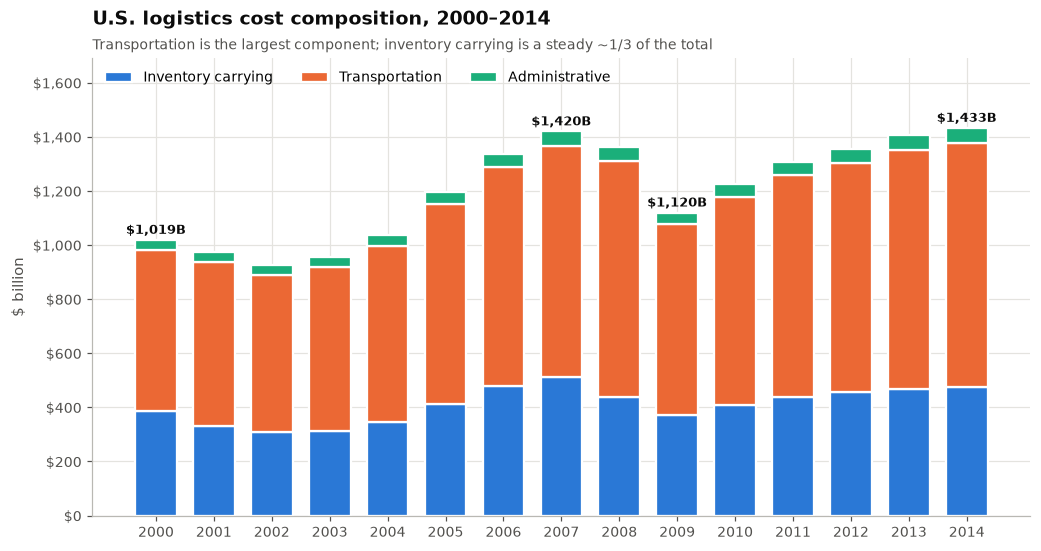

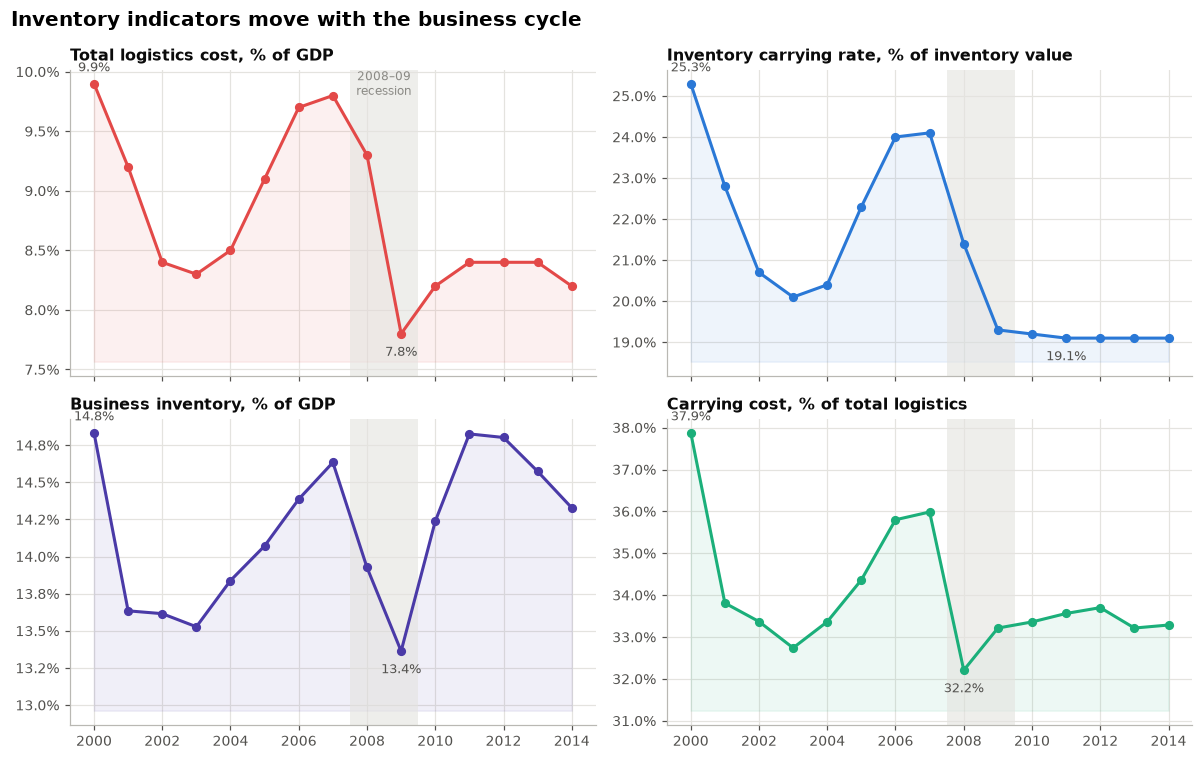

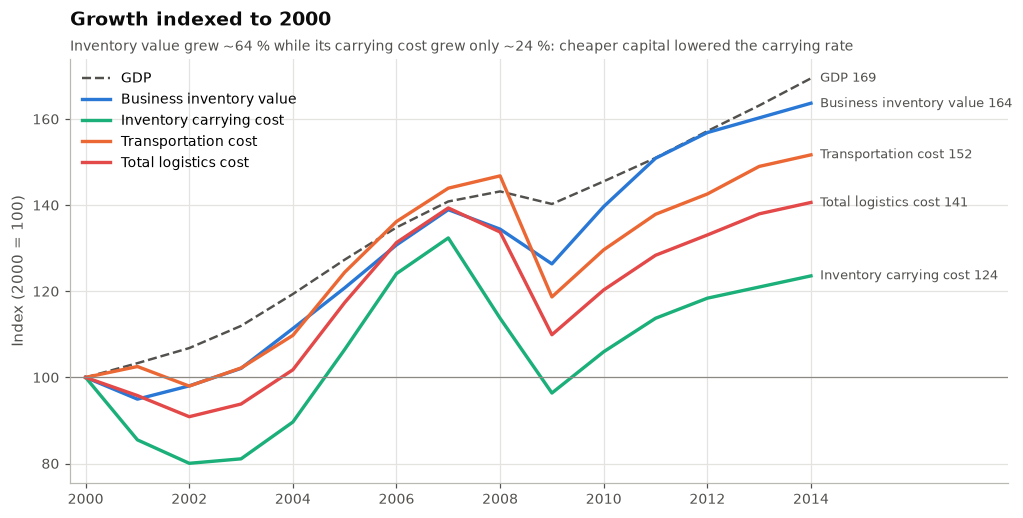

*Lecture data with verification columns (check_carrying_bn = a × b) and derived shares.*

,year,gdp_bn,business_inventory_bn,inventory_carrying_rate_pct,inventory_carrying_cost_bn,check_carrying_bn,transportation_cost_bn,administrative_cost_bn,total_logistics_cost_bn,logistics_pct_gdp,inv_share_of_logistics_pct
0,2000,"10,280","1,525",25.3,386,385.8,594,39,"1,019",9.9,37.9
1,2001,"10,620","1,448",22.8,330,330.1,609,37,976,9.2,33.8
2,2002,"10,980","1,495",20.7,309,309.5,582,35,926,8.4,33.4
3,2003,"11,510","1,557",20.1,313,313.0,607,36,956,8.3,32.7
4,2004,"12,270","1,698",20.4,346,346.4,652,39,"1,037",8.5,33.4
5,2005,"13,090","1,842",22.3,411,410.8,739,46,"1,196",9.1,34.4
6,2006,"13,860","1,994",24.0,479,478.6,809,50,"1,338",9.7,35.8
7,2007,"14,480","2,119",24.1,511,510.7,855,54,"1,420",9.8,36.0
8,2008,"14,720","2,050",21.4,439,438.7,872,52,"1,363",9.3,32.2
9,2009,"14,420","1,927",19.3,372,371.9,705,43,"1,120",7.8,33.2


**Takeaway.** Inventory is not just a warehouse issue — at a national scale it represents hundreds of billions of dollars of cost each year. Even a one-point reduction in the carrying rate on \$2.5 trillion of inventory saves about **\$25 billion per year**.

📄 **PDF report exported:** `reports\P1_1_us_logistics_costs.pdf`

In [11]:
def run_logistics(df=None):
    df = pd.read_csv(DATA / "us_logistics_costs.csv") if df is None else df.copy()
    sec = Section("P1_1_us_logistics_costs", "U.S. logistics costs and the weight of inventory (2000–2014)",
                  part="Part 1 · Why is it important?")
    df["check_carrying_bn"] = df.business_inventory_bn * df.inventory_carrying_rate_pct / 100
    df["check_total_bn"] = df.inventory_carrying_cost_bn + df.transportation_cost_bn + df.administrative_cost_bn
    df["inv_share_of_logistics_pct"] = 100 * df.inventory_carrying_cost_bn / df.total_logistics_cost_bn
    df["inventory_pct_gdp"] = 100 * df.business_inventory_bn / df.gdp_bn
    err_c = (df.check_carrying_bn - df.inventory_carrying_cost_bn).abs().max()
    err_f = (df.check_total_bn - df.total_logistics_cost_bn).abs().max()
    y0, y1 = df.iloc[0], df.iloc[-1]
    low = df.loc[df.logistics_pct_gdp.idxmin()]
    cagr = lambda a, b: 100 * ((b / a) ** (1 / (len(df) - 1)) - 1)

    sec.text("The U.S. economy held between **\\$1.4 and \\$2.5 trillion** of business inventory each year in 2000–2014. "
             "Holding it cost **19–25 % of its value per year** (the *inventory carrying rate*), making inventory carrying "
             "cost roughly one-third of all U.S. logistics spending.")
    sec.equation("c = a × b      f = c + d + e      share of GDP = f / GDP",
                 r"c = a\times b,\qquad f=c+d+e,\qquad \%\text{GDP}=f/\text{GDP}")
    sec.metrics({
        "Inventory held in 2014": f"${y1.business_inventory_bn:,.0f} bn",
        "Carrying cost in 2014": f"${y1.inventory_carrying_cost_bn:,.0f} bn",
        "Inventory share of logistics cost (avg)": f"{df.inv_share_of_logistics_pct.mean():.1f} %",
        "Total logistics cost 2000 → 2014": f"${y0.total_logistics_cost_bn:,.0f} → ${y1.total_logistics_cost_bn:,.0f} bn",
        "Lowest logistics share of GDP": f"{low.logistics_pct_gdp:.1f} % ({int(low.year)})",
        "Inventory value CAGR 2000–2014": f"{cagr(y0.business_inventory_bn, y1.business_inventory_bn):.2f} % / yr",
        "Max check error c = a×b": f"{err_c:.2f} bn (rounding)",
        "Max check error f = c+d+e": f"{err_f:.2f} bn",
    })

    # Figure 1: stacked composition
    fig, ax = plt.subplots(figsize=(11, 5.4))
    parts = [("inventory_carrying_cost_bn", "Inventory carrying", C["blue"]),
             ("transportation_cost_bn", "Transportation", C["orange"]),
             ("administrative_cost_bn", "Administrative", C["aqua"])]
    bottom = np.zeros(len(df))
    for col, lab, colr in parts:
        ax.bar(df.year, df[col], bottom=bottom, color=colr, width=0.72, edgecolor=SURF, linewidth=1.5, label=lab)
        bottom += df[col].values
    for yr in [2000, 2007, 2009, 2014]:
        r = df[df.year == yr].iloc[0]
        ax.annotate(f"${r.total_logistics_cost_bn:,.0f}B", (yr, r.total_logistics_cost_bn), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=8.5, fontweight="bold", color=INK)
    ax.set_xticks(df.year); ax.set_ylabel("$ billion"); axis_fmt(ax, pre="$")
    ax.set_ylim(0, df.total_logistics_cost_bn.max() * 1.18)
    ax.legend(ncol=3, loc="upper left")
    style_title(ax, "U.S. logistics cost composition, 2000–2014",
                "Transportation is the largest component; inventory carrying is a steady ~1/3 of the total")
    sec.figure(fig, "Composition of U.S. logistics costs ($ billion). Source: lecture slide 5.")

    # Figure 2: four indicators as small multiples (no dual axis)
    fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    spec = [("logistics_pct_gdp", "Total logistics cost, % of GDP", C["red"]),
            ("inventory_carrying_rate_pct", "Inventory carrying rate, % of inventory value", C["blue"]),
            ("inventory_pct_gdp", "Business inventory, % of GDP", C["violet"]),
            ("inv_share_of_logistics_pct", "Carrying cost, % of total logistics", C["aqua"])]
    for ax, (col, ttl, colr) in zip(axs.flat, spec):
        ax.plot(df.year, df[col], color=colr, marker="o", ms=5)
        ax.fill_between(df.year, df[col], df[col].min() * 0.97, color=colr, alpha=0.08)
        i_max, i_min = df[col].idxmax(), df[col].idxmin()
        for i, va in [(i_max, "bottom"), (i_min, "top")]:
            ax.annotate(f"{df[col][i]:.1f}%", (df.year[i], df[col][i]), xytext=(0, 6 if va == "bottom" else -8),
                        textcoords="offset points", ha="center", va=va, fontsize=8.5, color=INK2)
        ax.axvspan(2007.5, 2009.5, color=GRID, alpha=0.6, lw=0)
        ax.set_title(ttl, fontsize=10.5)
        axis_fmt(ax, suf="%", dec=1)
    axs[0, 0].text(2008.5, axs[0, 0].get_ylim()[1], "2008–09\nrecession", ha="center", va="top", fontsize=8, color=MUTED)
    fig.suptitle("Inventory indicators move with the business cycle", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Key ratios derived from the lecture data. The 2008–09 recession (shaded) cut both inventory and "
                    "logistics intensity.")

    # Figure 3: indexed growth
    fig, ax = plt.subplots(figsize=(11, 5))
    for col, lab, colr in [("gdp_bn", "GDP", INK2), ("business_inventory_bn", "Business inventory value", C["blue"]),
                           ("inventory_carrying_cost_bn", "Inventory carrying cost", C["aqua"]),
                           ("transportation_cost_bn", "Transportation cost", C["orange"]),
                           ("total_logistics_cost_bn", "Total logistics cost", C["red"])]:
        idx = 100 * df[col] / df[col].iloc[0]
        ax.plot(df.year, idx, color=colr, lw=2.2 if col != "gdp_bn" else 1.6, ls="-" if col != "gdp_bn" else "--",
                label=lab)
        ax.annotate(f"{lab} {idx.iloc[-1]:.0f}", (df.year.iloc[-1], idx.iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8.5, color=INK2)
    ax.axhline(100, color=MUTED, lw=0.8)
    ax.set_xlim(df.year.min() - 0.3, df.year.max() + 3.8); ax.set_ylabel("Index (2000 = 100)")
    ax.set_xticks(df.year[::2]); ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.legend(loc="upper left")
    style_title(ax, "Growth indexed to 2000", "Inventory value grew ~64 % while its carrying cost grew only ~24 %: "
                "cheaper capital lowered the carrying rate")
    sec.figure(fig, "All series indexed to 2000 = 100 so that different magnitudes share one axis.")

    sec.table(df[["year", "gdp_bn", "business_inventory_bn", "inventory_carrying_rate_pct", "inventory_carrying_cost_bn",
                  "check_carrying_bn", "transportation_cost_bn", "administrative_cost_bn", "total_logistics_cost_bn",
                  "logistics_pct_gdp", "inv_share_of_logistics_pct"]],
              "Lecture data with verification columns (check_carrying_bn = a × b) and derived shares.",
              formats={"year": "d", "gdp_bn": ",.0f", "business_inventory_bn": ",.0f", "inventory_carrying_cost_bn": ",.0f",
                       "check_carrying_bn": ",.1f", "transportation_cost_bn": ",.0f", "administrative_cost_bn": ",.0f",
                       "total_logistics_cost_bn": ",.0f", "inventory_carrying_rate_pct": ".1f",
                       "logistics_pct_gdp": ".1f", "inv_share_of_logistics_pct": ".1f"})
    sec.text("**Takeaway.** Inventory is not just a warehouse issue — at a national scale it represents hundreds of "
             "billions of dollars of cost each year. Even a one-point reduction in the carrying rate on \\$2.5 trillion "
             f"of inventory saves about **\\${0.01 * y1.business_inventory_bn:,.0f} billion per year**.")
    return sec, df

sec_logistics, logistics_df = run_logistics()
export_section(sec_logistics);

## 1.2 Inventory-to-sales ratios and the downstream shift (slides 7–8)

The **inventory-to-sales (I/S) ratio** is the value of inventory on hand divided by monthly sales. It tells how many months of sales are sitting in stock:

$$\text{I/S ratio}_t = \frac{\text{Inventory}_t}{\text{Sales}_t}$$

The lecture shows that U.S. I/S ratios fell from the 1990s to the mid-2000s, spiked in 2008–09, and that inventories have **shifted downstream** (to wholesalers and retailers) because of **global sourcing** (longer lead times) and **growing product variety**.

**Input file:** `data/echelon_inventory_sales.csv` — monthly inventory and sales (\$ million) for the manufacturing, wholesale and retail arms of a *hypothetical* consumer-goods group (2016–2025, includes a 2020 demand shock). Replace it with Census/FRED data or your own company data to reproduce the analysis.

The I/S ratio converts inventory into *months of sales*. A falling ratio means the same sales are supported with less stock (leaner operations); a spike signals that sales dropped faster than production could be cut.

$$\text{I/S}=\frac{\text{Inventory}}{\text{Sales}}$$

,Value
Key result,
Manufacturing I/S 2016 → 2025,1.55 → 1.09
Wholesale I/S 2016 → 2025,1.32 → 1.35
Retail I/S 2016 → 2025,1.62 → 1.76
Downstream share of inventory,65.9 % → 74.7 %
Peak I/S (any echelon),1.84 (Aug 2020)
Months analysed,120


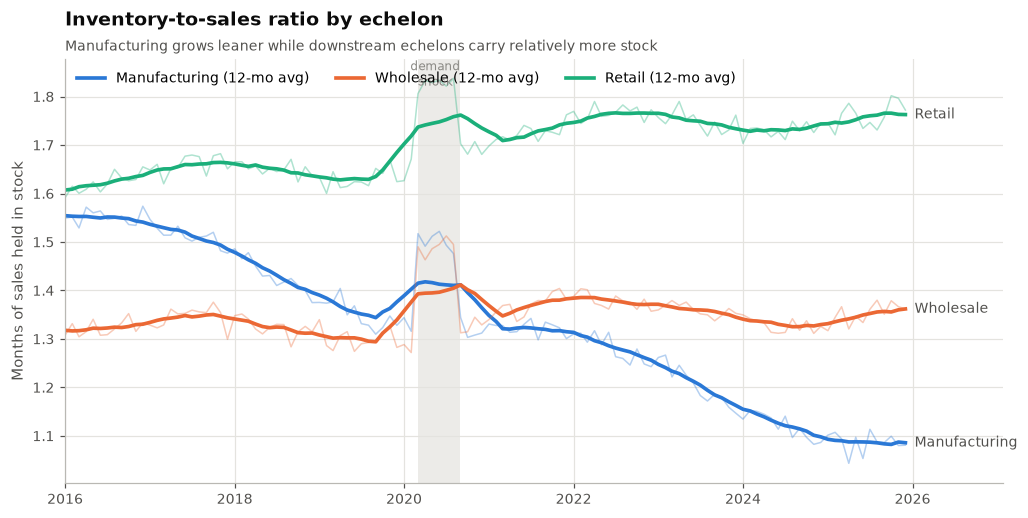

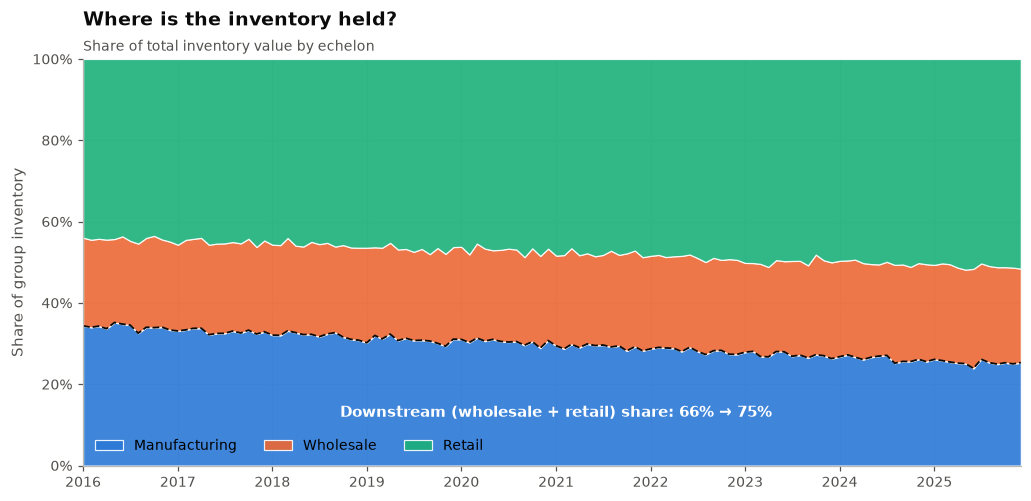

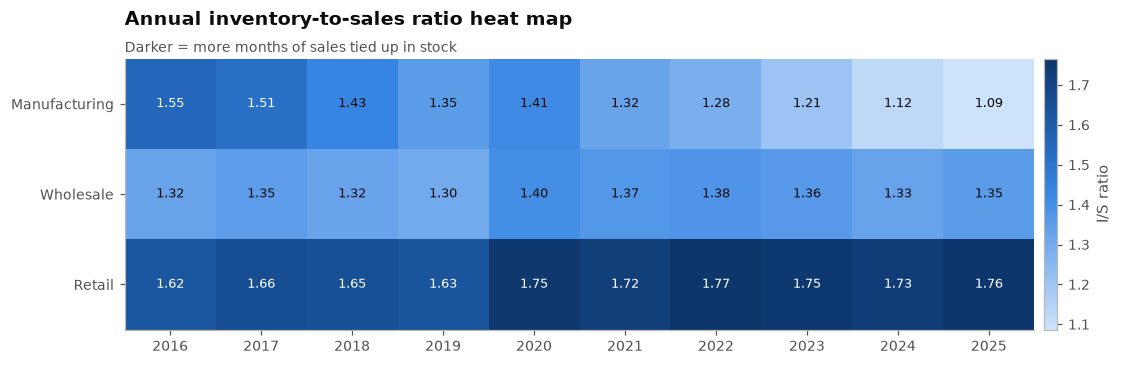

*Annual I/S ratios and downstream share of inventory.*

echelon,Year,Manufacturing,Wholesale,Retail,Downstream share %
0,2016,1.552,1.322,1.621,65.9
1,2017,1.512,1.345,1.659,67.0
2,2018,1.432,1.325,1.651,67.9
3,2019,1.352,1.299,1.629,69.1
4,2020,1.414,1.402,1.755,69.5
5,2021,1.323,1.369,1.723,70.8
6,2022,1.282,1.378,1.766,71.7
7,2023,1.205,1.360,1.750,72.8
8,2024,1.122,1.328,1.730,73.7
9,2025,1.087,1.352,1.760,74.7


- **Global sourcing** lengthens replenishment lead times, so wholesalers and retailers must hold more pipeline and safety stock.
- **Product variety** multiplies SKUs at the point of sale; each SKU needs its own safety stock (see Part 3.2).
- Manufacturers adopting lean / make-to-order practices push finished-goods stock downstream.

📄 **PDF report exported:** `reports\P1_2_inventory_to_sales.pdf`

In [12]:
def run_echelons(df=None):
    df = pd.read_csv(DATA / "echelon_inventory_sales.csv", parse_dates=["month"]) if df is None else df.copy()
    sec = Section("P1_2_inventory_to_sales", "Inventory-to-sales ratios and the downstream shift of inventory",
                  part="Part 1 · Why is it important?")
    df["is_ratio"] = df.inventory_mn / df.sales_mn
    R = df.pivot(index="month", columns="echelon", values="is_ratio")
    I = df.pivot(index="month", columns="echelon", values="inventory_mn")
    share = I.div(I.sum(axis=1), axis=0)
    down = share["Wholesale"] + share["Retail"]
    order = ["Manufacturing", "Wholesale", "Retail"]
    col = dict(zip(order, [C["blue"], C["orange"], C["aqua"]]))

    sec.text("The I/S ratio converts inventory into *months of sales*. A falling ratio means the same sales are "
             "supported with less stock (leaner operations); a spike signals that sales dropped faster than "
             "production could be cut.")
    sec.equation("I/S ratio = Inventory ($) / Monthly sales ($)", r"\text{I/S}=\frac{\text{Inventory}}{\text{Sales}}")
    first, last = R.index.min(), R.index.max()
    sec.metrics({**{f"{e} I/S {first.year} → {last.year}": f"{R[e].iloc[:12].mean():.2f} → {R[e].iloc[-12:].mean():.2f}"
                    for e in order},
                 "Downstream share of inventory": f"{100*down.iloc[:12].mean():.1f} % → {100*down.iloc[-12:].mean():.1f} %",
                 "Peak I/S (any echelon)": f"{R.max().max():.2f} ({R.max(axis=1).idxmax():%b %Y})",
                 "Months analysed": f"{len(R)}"})

    fig, ax = plt.subplots(figsize=(11, 5))
    for e in order:
        ax.plot(R.index, R[e], color=col[e], lw=1, alpha=0.35)
        rr = R[e].rolling(12, center=True, min_periods=6).mean()
        ax.plot(R.index, rr, color=col[e], lw=2.4, label=f"{e} (12-mo avg)")
        ax.annotate(e, (R.index[-1], rr.dropna().iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK2)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-08-31"), color=GRID, alpha=0.7, lw=0)
    ax.text(pd.Timestamp("2020-05-15"), ax.get_ylim()[1], "demand\nshock", ha="center", va="top", fontsize=8, color=MUTED)
    ax.set_ylabel("Months of sales held in stock"); ax.legend(loc="upper left", ncol=3)
    ax.set_xlim(R.index.min(), R.index.max() + pd.Timedelta(days=420))
    style_title(ax, "Inventory-to-sales ratio by echelon",
                "Manufacturing grows leaner while downstream echelons carry relatively more stock")
    sec.figure(fig, "Monthly I/S ratio (thin) and 12-month centred moving average (bold).")

    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.stackplot(share.index, *[100 * share[e] for e in order], colors=[col[e] for e in order],
                 labels=order, alpha=0.9, edgecolor=SURF, linewidth=0.8)
    ax.plot(down.index, 100 * (1 - down), color=INK, lw=1.2, ls="--")
    ax.text(down.index[len(down)//2], 12, f"Downstream (wholesale + retail) share: {100*down.iloc[0]:.0f}% → "
            f"{100*down.iloc[-1]:.0f}%", fontsize=9.5, color="white", fontweight="bold", ha="center")
    ax.set_ylim(0, 100); axis_fmt(ax, suf="%"); ax.set_ylabel("Share of group inventory")
    ax.legend(loc="lower left", ncol=3); ax.margins(x=0)
    style_title(ax, "Where is the inventory held?", "Share of total inventory value by echelon")
    sec.figure(fig, "Fraction of total inventory held at each echelon; dashed line = boundary between manufacturing and "
                    "downstream stock.")

    df["year"] = df.month.dt.year
    ann = df.groupby(["echelon", "year"]).apply(lambda g: g.inventory_mn.sum() / g.sales_mn.sum()).unstack()
    ann = ann.loc[order]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(ann.values, cmap=SEQ_CMAP, aspect="auto")
    ax.set_xticks(range(ann.shape[1])); ax.set_xticklabels(ann.columns)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order); ax.grid(False)
    for i in range(ann.shape[0]):
        for j in range(ann.shape[1]):
            v = ann.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                    color="white" if v > np.nanpercentile(ann.values, 60) else INK)
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="I/S ratio")
    style_title(ax, "Annual inventory-to-sales ratio heat map", "Darker = more months of sales tied up in stock")
    sec.figure(fig, "Annual I/S ratio = Σ inventory / Σ sales within the year.")

    tab = ann.T.round(3).reset_index().rename(columns={"year": "Year"})
    tab["Downstream share %"] = (100 * down.groupby(down.index.year).mean()).values
    sec.table(tab, "Annual I/S ratios and downstream share of inventory.",
              formats={"Year": "d", **{e: ".3f" for e in order}, "Downstream share %": ".1f"})
    sec.bullets(["**Global sourcing** lengthens replenishment lead times, so wholesalers and retailers must hold more "
                 "pipeline and safety stock.",
                 "**Product variety** multiplies SKUs at the point of sale; each SKU needs its own safety stock "
                 "(see Part 3.2).",
                 "Manufacturers adopting lean / make-to-order practices push finished-goods stock downstream."])
    return sec, df

sec_echelons, echelon_df = run_echelons()
export_section(sec_echelons);

## 1.3 Why aggregate inventory fluctuates — the business cycle (slide 9)

Firms set production from *expected* sales. When the economy approaches a **peak**, production still runs ahead of sales → **inventory build-up**. After the peak, sales fall faster than firms can cut production, then production is cut hard → **disinvestment in inventory** until the **trough**. Corporate profits follow the same wave.

The simulation below uses a simple model (you can change every argument):

$$S_t = \bar S\,[1 + a\sin(2\pi t/T)], \qquad P_t = \bar S\,[1 + a\sin(2\pi (t+\ell)/T)], \qquad I_t = I_0 + \sum_{k\le t}(P_k - S_k)$$

where $\ell$ is how many months production *leads* sales, and profit $\pi_t = m\,S_t - h\,I_t$.

Parameters: cycle length **24 months**, amplitude **±15 %**, production leads sales by **3 months**, starting inventory **150** units, contribution margin **25 %**, holding cost **2 % per month**.

$$I_t = I_0 + \sum_{k\le t}\left(P_k - S_k\right)$$

,Value
Key result,
Max inventory,183
Min inventory,95
Swing (max − min),88 units = 88% of a month's sales
Largest monthly build-up,11.4
Largest monthly disinvestment,-11.4
Inventory peaks ≈ months after sales peak,22


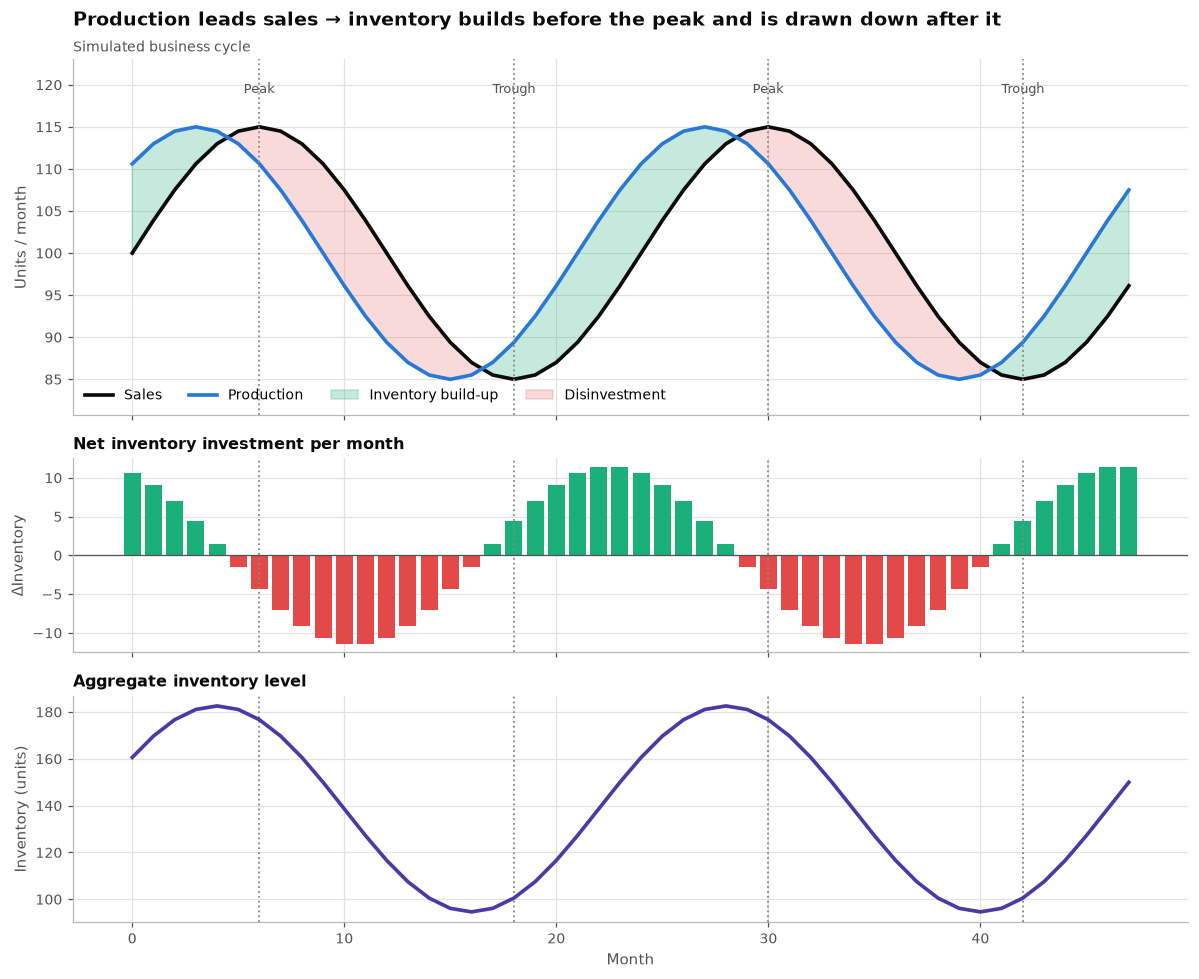

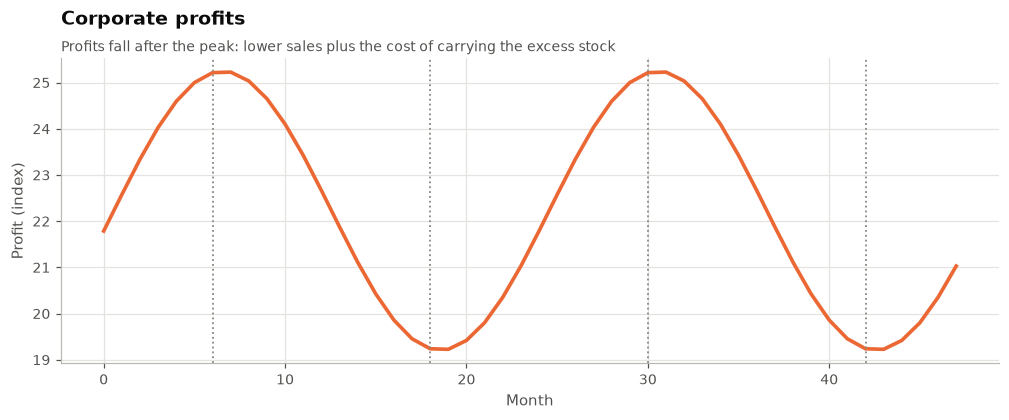

*Simulation output (every 3rd month).*

,month,sales,production,inventory_change,inventory,profit
0,1,100.0,110.6,+10.6,160.6,21.79
1,4,110.6,115.0,+4.4,181.1,24.03
2,7,115.0,110.6,-4.4,176.7,25.22
3,10,110.6,100.0,-10.6,150.0,24.65
4,13,100.0,89.4,-10.6,116.6,22.67
5,16,89.4,85.0,-4.4,96.1,20.43
6,19,85.0,89.4,+4.4,100.5,19.24
7,22,89.4,100.0,+10.6,127.2,19.80
8,25,100.0,110.6,+10.6,160.6,21.79
9,28,110.6,115.0,+4.4,181.1,24.03


📄 **PDF report exported:** `reports\P1_3_business_cycle.pdf`

In [13]:
def run_business_cycle(months=48, period=24, amplitude=0.15, lead=3, base_sales=100.0, I0=150.0,
                       margin=0.25, hold_rate_month=0.02):
    sec = Section("P1_3_business_cycle", "The business cycle and aggregate inventory investment",
                  part="Part 1 · Why is it important?")
    t = np.arange(months)
    S = base_sales * (1 + amplitude * np.sin(2 * np.pi * t / period))
    P = base_sales * (1 + amplitude * np.sin(2 * np.pi * (t + lead) / period))
    dI = P - S
    I = I0 + np.cumsum(dI)
    profit = margin * S - hold_rate_month * I
    df = pd.DataFrame({"month": t + 1, "sales": S, "production": P, "inventory_change": dI,
                       "inventory": I, "profit": profit})
    inner = (t > 0) & (t < months - 1)
    peaks = t[inner & (S > np.roll(S, 1)) & (S >= np.roll(S, -1))]
    troughs = t[inner & (S < np.roll(S, 1)) & (S <= np.roll(S, -1))]

    sec.text(f"Parameters: cycle length **{period} months**, amplitude **±{100*amplitude:.0f} %**, production leads sales "
             f"by **{lead} months**, starting inventory **{I0:.0f}** units, contribution margin **{100*margin:.0f} %**, "
             f"holding cost **{100*hold_rate_month:.0f} % per month**.")
    sec.equation("I(t) = I0 + Σ [P(k) − S(k)]",
                 r"I_t = I_0 + \sum_{k\le t}\left(P_k - S_k\right)")
    sec.metrics({"Max inventory": f"{I.max():.0f}", "Min inventory": f"{I.min():.0f}",
                 "Swing (max − min)": f"{I.max() - I.min():.0f} units = {100*(I.max()-I.min())/base_sales:.0f}% of a month's sales",
                 "Largest monthly build-up": f"{dI.max():.1f}", "Largest monthly disinvestment": f"{dI.min():.1f}",
                 "Inventory peaks ≈ months after sales peak": f"{(np.argmax(I[:period]) - np.argmax(S[:period])) % period}"})

    fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.2, 1.4]})
    ax = axs[0]
    ax.plot(t, S, color=INK, lw=2.4, label="Sales")
    ax.plot(t, P, color=C["blue"], lw=2.4, label="Production")
    ax.fill_between(t, S, P, where=P >= S, color=C["aqua"], alpha=0.25, interpolate=True, label="Inventory build-up")
    ax.fill_between(t, S, P, where=P < S, color=C["red"], alpha=0.2, interpolate=True, label="Disinvestment")
    for pk in peaks:
        for a in axs: a.axvline(pk, color=MUTED, ls=":", lw=1.2)
        ax.text(pk, S.max() * 1.035, "Peak", ha="center", fontsize=8.5, color=INK2)
    for tr in troughs:
        for a in axs: a.axvline(tr, color=MUTED, ls=":", lw=1.2)
        ax.text(tr, S.max() * 1.035, "Trough", ha="center", fontsize=8.5, color=INK2)
    ax.set_ylim(S.min() * 0.95, S.max() * 1.07); ax.set_ylabel("Units / month"); ax.legend(ncol=4, loc="lower left")
    style_title(ax, "Production leads sales → inventory builds before the peak and is drawn down after it",
                "Simulated business cycle")
    axs[1].bar(t, dI, color=np.where(dI >= 0, C["aqua"], C["red"]), width=0.8)
    axs[1].axhline(0, color=INK2, lw=0.8); axs[1].set_ylabel("ΔInventory")
    axs[1].set_title("Net inventory investment per month", fontsize=10.5)
    axs[2].plot(t, I, color=C["violet"], lw=2.4, label="Inventory level")
    axs[2].set_ylabel("Inventory (units)"); axs[2].set_xlabel("Month")
    axs[2].set_title("Aggregate inventory level", fontsize=10.5)
    fig.tight_layout()
    sec.figure(fig, "Business-cycle simulation: sales vs production, monthly inventory investment and inventory level.")

    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(t, profit, color=C["orange"], lw=2.4)
    for pk in peaks: ax.axvline(pk, color=MUTED, ls=":", lw=1.2)
    for tr in troughs: ax.axvline(tr, color=MUTED, ls=":", lw=1.2)
    ax.set_xlabel("Month"); ax.set_ylabel("Profit (index)")
    style_title(ax, "Corporate profits", "Profits fall after the peak: lower sales plus the cost of carrying the excess stock")
    sec.figure(fig, "Profit = margin × sales − holding cost × inventory.")

    sec.table(df.iloc[::3], "Simulation output (every 3rd month).",
              formats={"month": "d", "sales": ".1f", "production": ".1f", "inventory_change": "+.1f",
                       "inventory": ".1f", "profit": ".2f"})
    return sec, df

sec_cycle, cycle_df = run_business_cycle()
export_section(sec_cycle);

## 1.4 Functions of inventory (slide 10)

| Function | What it does | Typical stock category |
|---|---|---|
| Meet anticipated demand | Have product available when customers want it | Cycle, anticipation |
| Smooth production requirements | Build ahead of seasonal peaks with level capacity | Anticipation |
| Decouple operations | Buffers between stages so a breakdown does not stop the line | Decoupling / WIP |
| Protect against stock-outs | Absorb forecast error and supply delays | Safety |
| Hedge against price increases | Buy ahead of announced price rises | Anticipation (speculative) |
| Permit operations | Goods physically in process or in transit | Process, pipeline |
| Take advantage of quantity discounts | Buy in larger lots to get a lower unit price | Cycle |

Each of these functions is quantified in the parts that follow.

---
# Part 2 — Functional categories of stock (slides 11–19)

| Category | Why it exists | How it is sized |
|---|---|---|
| **Cycle stock** | Items are made/ordered in batches, not continuously | Average = Q/2 (half the lot) |
| **Safety stock** | Demand forecast error and supply (timing/amount) variability | z · σ over the lead time; 0 if everything is certain |
| **Process stock** | Process specifications delay release (hardening, curing, QA hold) | demand rate × process-hold time |
| **Pipeline stock** | Administrative and physical lags between order and delivery | demand rate × transit/lag time (Little's law) |
| **Anticipation stock** | Seasonal peaks, promotions, shutdowns, price hedges with limited capacity | built ahead from spare capacity |
| **Decoupling stock** | Buffers between stages so they can run independently | set by stage variability and rate mismatch |

## 2.1 Cycle stock (slides 12–13, 19)

With a lot (batch) of size $Q$ and a constant demand rate $d$, inventory follows a *saw-tooth*: it jumps to $Q$ at each make/order event and falls linearly to 0.

$$\text{Max cycle stock}=Q,\quad \text{Min}=0,\quad \overline{I}_{cycle}=\frac{Q}{2},\quad \text{cycle time}=\frac{Q}{d},\quad \text{cycles per year } n=\frac{D}{Q}$$

Average cycle stock is **half the lot size** (in units) or **half the interval between production events** (in days of demand). Because $\overline I = D/(2n)$, **doubling the number of cycles halves the average cycle stock**.

**Input:** `scenario_parameters.json → cycle_stock_demo` (annual demand, working days, lot sizes to compare).

Annual demand **D = 12,000** units over **240** working days → demand rate **d = 50.0 units/day**.

$$\bar I_{cycle}=\frac{Q}{2}=\frac{D}{2n}$$

,Value
Key result,
Largest lot (Q),"4,000 units → avg 2,000"
Doubling cycles/year,3 → 6 cycles
Avg cycle stock falls by,50 %
Demand rate,50.0 units/day


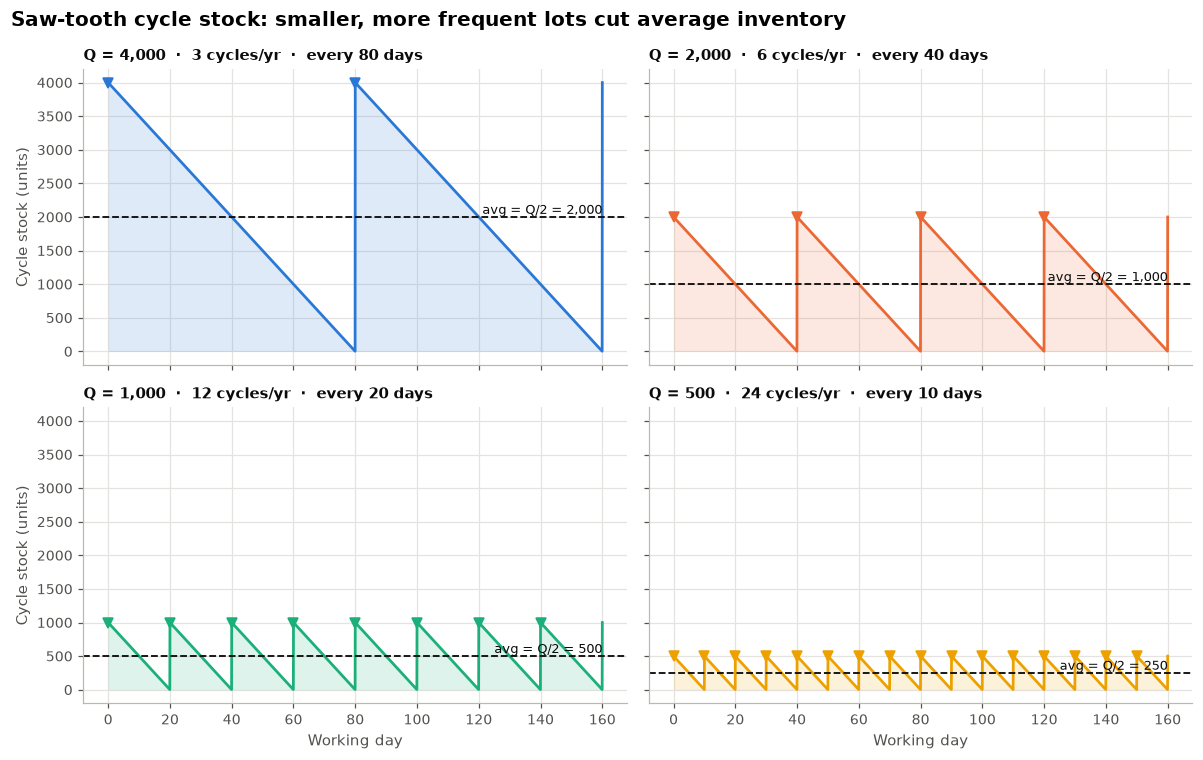

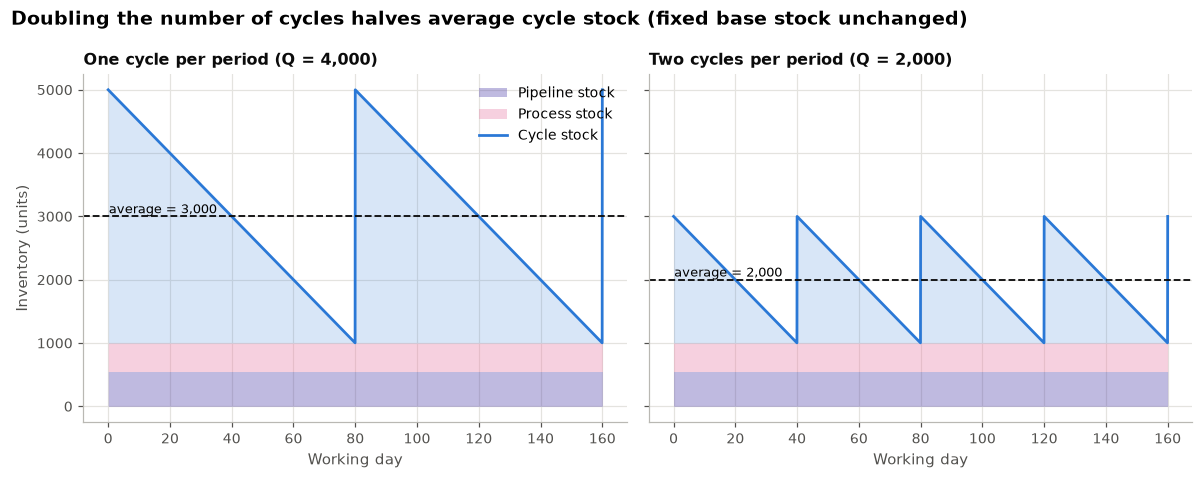

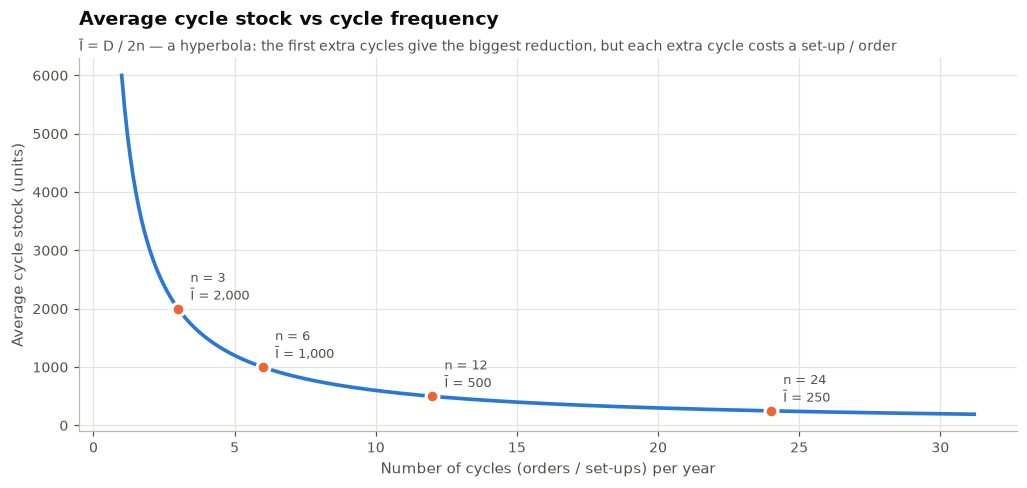

*Cycle stock for alternative lot sizes.*

,lot_size_Q,cycles_per_year,cycle_time_days,max_cycle_stock,min_cycle_stock,avg_cycle_stock_units,avg_coverage_days
0,"4,000",3.0,80.0,"4,000",0,"2,000",40.0
1,"2,000",6.0,40.0,"2,000",0,"1,000",20.0
2,"1,000",12.0,20.0,"1,000",0,500,10.0
3,500,24.0,10.0,500,0,250,5.0


📄 **PDF report exported:** `reports\P2_1_cycle_stock.pdf`

In [14]:
def sawtooth(Q, d, horizon, start=0.0, step=0.05):
    t = np.arange(0, horizon + step, step)
    T = Q / d
    return t, start + Q - d * ((t) % T)

def run_cycle_stock(p=None, base_stock=None):
    p = p or PARAMS["cycle_stock_demo"]
    D, days = p["annual_demand"], p["working_days"]
    d = D / days
    sec = Section("P2_1_cycle_stock", "Cycle stock: batch size, cycle frequency and average inventory",
                  part="Part 2 · Categories of stock")
    rows = []
    for Q in p["lot_sizes"]:
        rows.append({"lot_size_Q": Q, "cycles_per_year": D / Q, "cycle_time_days": Q / d, "max_cycle_stock": Q,
                     "min_cycle_stock": 0, "avg_cycle_stock_units": Q / 2, "avg_coverage_days": Q / d / 2})
    tab = pd.DataFrame(rows)
    sec.text(f"Annual demand **D = {D:,}** units over **{days}** working days → demand rate **d = {d:,.1f} units/day**.")
    sec.equation("Average cycle stock = Q / 2 = D / (2n)", r"\bar I_{cycle}=\frac{Q}{2}=\frac{D}{2n}")
    q0, q1 = tab.iloc[0], tab.iloc[1]
    sec.metrics({"Largest lot (Q)": f"{q0.lot_size_Q:,.0f} units → avg {q0.avg_cycle_stock_units:,.0f}",
                 "Doubling cycles/year": f"{q0.cycles_per_year:.0f} → {q1.cycles_per_year:.0f} cycles",
                 "Avg cycle stock falls by": f"{100*(1 - q1.avg_cycle_stock_units/q0.avg_cycle_stock_units):.0f} %",
                 "Demand rate": f"{d:,.1f} units/day"})

    horizon = max(tab.cycle_time_days) * 2
    fig, axs = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
    for ax, (_, r), colr in zip(axs.flat, tab.iterrows(), SERIES):
        t, inv = sawtooth(r.lot_size_Q, d, horizon)
        ax.fill_between(t, inv, color=colr, alpha=0.15, lw=0)
        ax.plot(t, inv, color=colr, lw=1.8)
        ax.axhline(r.avg_cycle_stock_units, color=INK, ls="--", lw=1.2)
        ax.text(horizon, r.avg_cycle_stock_units, f" avg = Q/2 = {r.avg_cycle_stock_units:,.0f}", va="bottom",
                ha="right", fontsize=8.5, color=INK)
        events = np.arange(0, horizon, r.cycle_time_days)
        ax.plot(events, np.full_like(events, r.lot_size_Q), "v", color=colr, ms=7)
        ax.set_title(f"Q = {r.lot_size_Q:,.0f}  ·  {r.cycles_per_year:.0f} cycles/yr  ·  every {r.cycle_time_days:.0f} days",
                     fontsize=10)
    for ax in axs[1]: ax.set_xlabel("Working day")
    for ax in axs[:, 0]: ax.set_ylabel("Cycle stock (units)")
    fig.suptitle("Saw-tooth cycle stock: smaller, more frequent lots cut average inventory", x=0.01, ha="left",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Cycle-stock profiles for the four lot sizes. ▼ marks a make/order event; dashed line = average (Q/2).")

    # Slide 19 replica: one vs two cycles per period on top of pipeline + process stock
    base = base_stock if base_stock is not None else 0.25 * p["lot_sizes"][0]
    Q1 = p["lot_sizes"][0]
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
    for ax, (n, Q) in zip(axs, [(1, Q1), (2, Q1 / 2)]):
        T = Q1 / d
        t, inv = sawtooth(Q, d, T * 2)
        ax.fill_between(t, 0, base * 0.55, color=C["violet"], alpha=0.35, lw=0, label="Pipeline stock")
        ax.fill_between(t, base * 0.55, base, color=C["magenta"], alpha=0.35, lw=0, label="Process stock")
        ax.fill_between(t, base, base + inv, color=C["blue"], alpha=0.18, lw=0)
        ax.plot(t, base + inv, color=C["blue"], lw=1.8, label="Cycle stock")
        ax.axhline(base + Q / 2, color=INK, ls="--", lw=1.2)
        ax.text(0.2, base + Q / 2, f"average = {base + Q/2:,.0f}", va="bottom", fontsize=8.5)
        ax.set_title(f"{'One' if n == 1 else 'Two'} cycle{'s' if n > 1 else ''} per period (Q = {Q:,.0f})", fontsize=10.5)
        ax.set_xlabel("Working day")
    axs[0].set_ylabel("Inventory (units)"); axs[0].legend(loc="upper right")
    fig.suptitle("Doubling the number of cycles halves average cycle stock (fixed base stock unchanged)", x=0.01,
                 ha="left", fontsize=12.5, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Replica of lecture slide 19 with pipeline and process stock as a fixed base.")

    fig, ax = plt.subplots(figsize=(11, 4.4))
    n = np.linspace(1, max(tab.cycles_per_year) * 1.3, 300)
    ax.plot(n, D / (2 * n), color=C["blue"], lw=2.4)
    ax.scatter(tab.cycles_per_year, tab.avg_cycle_stock_units, s=70, color=C["orange"], zorder=3,
               edgecolor=SURF, linewidth=2)
    for _, r in tab.iterrows():
        ax.annotate(f"n = {r.cycles_per_year:.0f}\nĪ = {r.avg_cycle_stock_units:,.0f}", (r.cycles_per_year, r.avg_cycle_stock_units),
                    xytext=(8, 6), textcoords="offset points", fontsize=8.5, color=INK2)
    ax.set_xlabel("Number of cycles (orders / set-ups) per year"); ax.set_ylabel("Average cycle stock (units)")
    style_title(ax, "Average cycle stock vs cycle frequency", "Ī = D / 2n — a hyperbola: the first extra cycles give "
                "the biggest reduction, but each extra cycle costs a set-up / order")
    sec.figure(fig, "Trade-off preview: fewer units in stock requires more frequent set-ups (see Part 6.4).")
    sec.table(tab, "Cycle stock for alternative lot sizes.",
              formats={"lot_size_Q": ",.0f", "cycles_per_year": ".1f", "cycle_time_days": ".1f", "max_cycle_stock": ",.0f",
                       "min_cycle_stock": "d", "avg_cycle_stock_units": ",.0f", "avg_coverage_days": ".1f"})
    return sec, tab

sec_cycle_stock, cycle_tab = run_cycle_stock()
export_section(sec_cycle_stock);

## 2.2 Safety stock (slides 14–16)

Safety stock protects against **demand forecast error** (actual − planned demand) and **supply forecast error** (actual − planned lead time or quantity). With daily forecast error $\sigma_d$, mean daily demand $\bar d$, mean lead time $\bar L$ and lead-time standard deviation $\sigma_L$, the standard deviation of demand over the lead time is

$$\sigma_{DLT}=\sqrt{\bar L\,\sigma_d^{2}+\bar d^{2}\,\sigma_L^{2}}$$

and the safety stock for a target **cycle service level** (probability of no stock-out in a replenishment cycle) is

$$SS = z_{\alpha}\,\sigma_{DLT},\qquad \text{Reorder point } ROP = \bar d\,\bar L + SS$$

- **SS = 0** when future demand **and** lead times are known with certainty ($\sigma_d=\sigma_L=0$).
- SS rises steeply with the desired service level. **Fill rate** (share of demand met from stock) is reported alongside.

*(Detailed safety-stock models are the subject of later lectures; here we measure the uncertainty from data and show the service-level relationship.)*

**Input files:** `data/daily_demand_history.csv` (forecast vs actual, 365 days), `data/lead_time_history.csv` (quoted vs actual lead times, 60 orders), `scenario_parameters.json → safety_stock_demo`.

Mean daily demand **198.9**, forecast-error σ<sub>d</sub> **45.9** units/day; mean lead time **7.75 days** (quoted 8 days), σ<sub>L</sub> **1.77 days**.

$$\sigma_{DLT}=\sqrt{\bar L\sigma_d^2+\bar d^2\sigma_L^2},\quad SS=z\,\sigma_{DLT},\quad ROP=\bar d\bar L+SS$$

,Value
Key result,
σ of lead-time demand (demand error only),128 units
σ of lead-time demand (demand + supply),375 units
SS for 95 % CSL,617 units
Reorder point for 95 % CSL,"2,158 units"
Simulated CSL at that ROP,93.3 %
SS with certain demand and lead time,0 units
Supply variability adds,193 % to SS


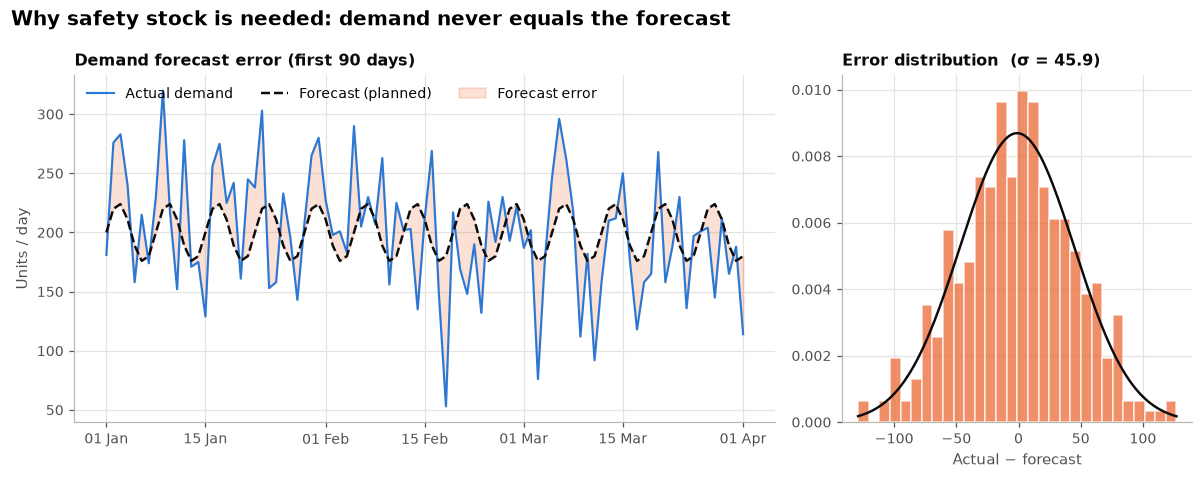

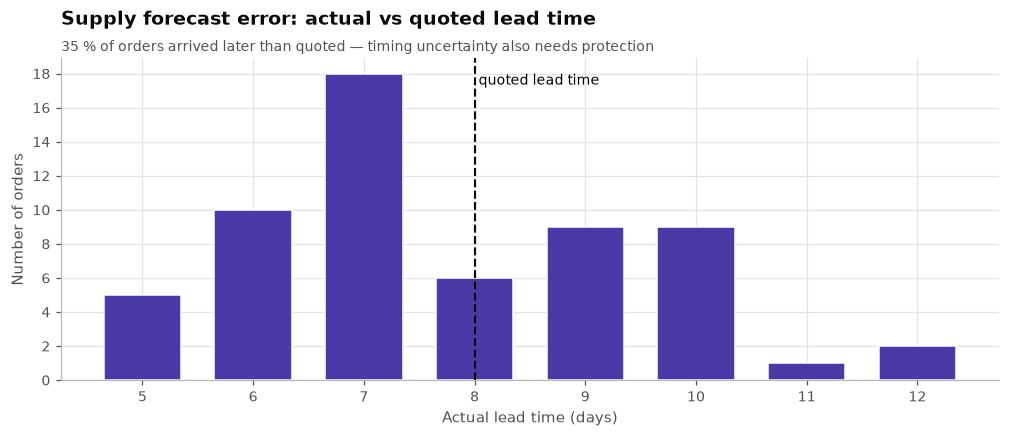

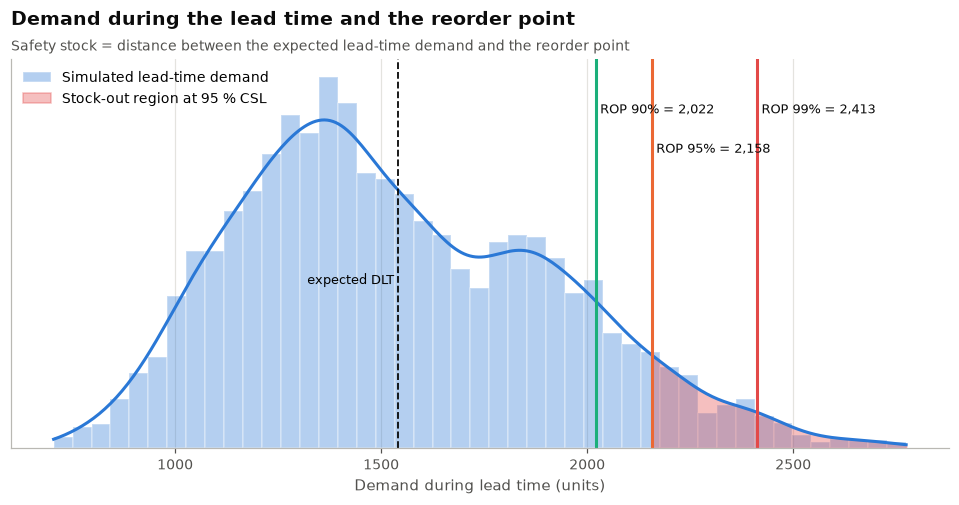

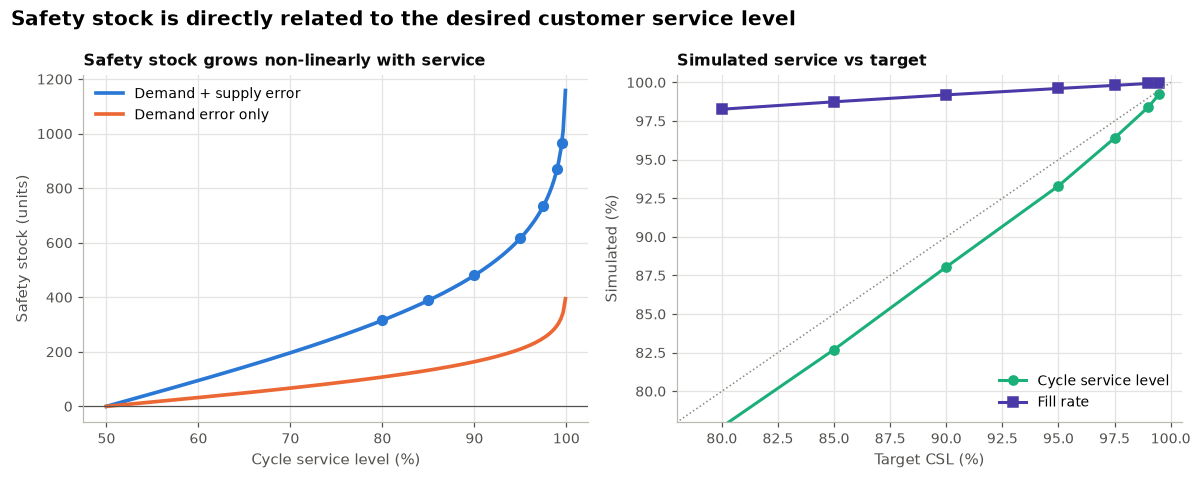

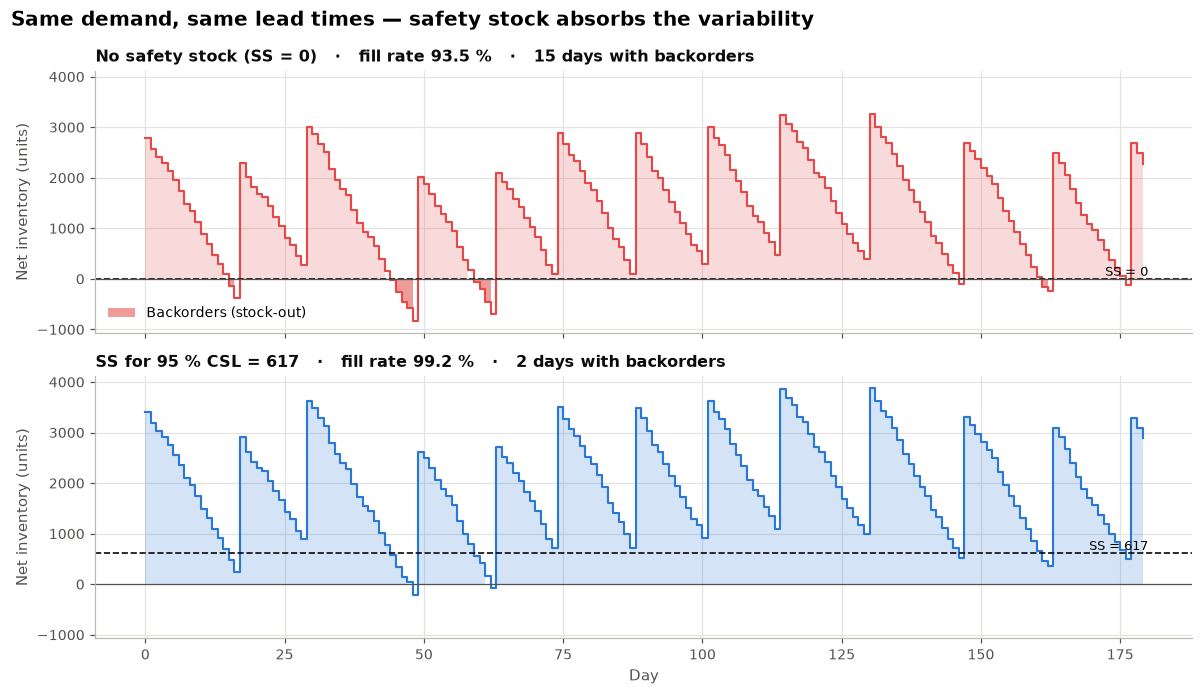

**Reading the simulation.** The analytic SS assumes lead-time demand is normal. The simulated (bootstrap) lead-time demand is skewed by the discrete, right-tailed lead times, so the achieved CSL is a little below target at mid service levels — a reminder to validate formula-based safety stocks against real data. The fill rate is always higher than the CSL because a stock-out cycle usually misses only part of the demand.

*Safety stock, reorder point and simulated service by target cycle service level.*

,cycle_service_level,z,SS_demand_error_only,SS_demand_and_supply_error,ROP,annual_SS_holding_cost,simulated_CSL,simulated_fill_rate
0,80.0%,0.842,108,315,"1,857","6,420",77.7%,98.26%
1,85.0%,1.036,132,388,"1,930","7,906",82.7%,98.75%
2,90.0%,1.282,164,480,"2,022","9,775",88.0%,99.20%
3,95.0%,1.645,210,617,"2,158","12,547",93.3%,99.61%
4,97.5%,1.960,250,735,"2,276","14,950",96.4%,99.81%
5,99.0%,2.326,297,872,"2,413","17,745",98.4%,99.93%
6,99.5%,2.576,329,966,"2,507","19,648",99.2%,99.97%


*Simulation comparison.*

,policy,reorder_point,fill_rate_pct,days_with_backorders,avg_on_hand
0,No safety stock (SS = 0),"1,541",93.5,15,"1,387"
1,SS for 95 % CSL = 617,"2,158",99.2,2,"1,979"


📄 **PDF report exported:** `reports\P2_2_safety_stock.pdf`

In [15]:
def simulate_sQ(demand, lt_samples, s, Q, init, rng):
    on_hand, backlog, pipeline, hist, served_now = init, 0.0, [], [], 0.0
    for t, dmd in enumerate(demand):
        arr = sum(q for a, q in pipeline if a == t)
        pipeline = [(a, q) for a, q in pipeline if a != t]
        on_hand += arr
        bl = min(backlog, on_hand); backlog -= bl; on_hand -= bl
        sv = min(dmd, on_hand); on_hand -= sv; served_now += sv; backlog += dmd - sv
        ip = on_hand - backlog + sum(q for _, q in pipeline)
        placed = 0
        while ip <= s:
            pipeline.append((t + int(rng.choice(lt_samples)), Q)); ip += Q; placed += Q
        hist.append((t, on_hand, backlog, ip, placed))
    h = pd.DataFrame(hist, columns=["day", "on_hand", "backlog", "inv_position", "order_placed"])
    return h, served_now / max(demand.sum(), 1)

def run_safety_stock(dh=None, lt=None, p=None):
    dh = pd.read_csv(DATA / "daily_demand_history.csv", parse_dates=["date"]) if dh is None else dh.copy()
    lt = pd.read_csv(DATA / "lead_time_history.csv") if lt is None else lt.copy()
    p = p or PARAMS["safety_stock_demo"]
    rng = np.random.default_rng(RNG_SEED)
    sec = Section("P2_2_safety_stock", "Safety stock: forecast error, supply error and service level",
                  part="Part 2 · Categories of stock")
    dh["error"] = dh.actual_demand_units - dh.forecast_units
    d_bar, sd = dh.actual_demand_units.mean(), dh.error.std(ddof=1)
    L_bar, sL = lt.actual_lead_time_days.mean(), lt.actual_lead_time_days.std(ddof=1)
    sig_dlt = math.sqrt(L_bar * sd**2 + d_bar**2 * sL**2)
    sig_dem_only = math.sqrt(L_bar) * sd
    v, r = p["unit_value"], p["holding_rate"]
    rows = []
    for sl in p["service_levels"]:
        z = stats.norm.ppf(sl)
        rows.append({"cycle_service_level": sl, "z": z, "SS_demand_error_only": z * sig_dem_only,
                     "SS_demand_and_supply_error": z * sig_dlt, "ROP": d_bar * L_bar + z * sig_dlt,
                     "annual_SS_holding_cost": z * sig_dlt * v * r})
    tab = pd.DataFrame(rows)

    # Monte-Carlo lead-time demand: bootstrap lead times and daily demands
    N = p["sim_replications"]
    Ls = rng.choice(lt.actual_lead_time_days.values, N)
    dlt = np.array([rng.choice(dh.actual_demand_units.values, L).sum() for L in Ls])
    tab["simulated_CSL"] = [(dlt <= rop).mean() for rop in tab.ROP]
    Q = round(d_bar * 15)
    tab["simulated_fill_rate"] = [1 - np.maximum(dlt - rop, 0).mean() / Q for rop in tab.ROP]

    sec.text(f"Mean daily demand **{d_bar:.1f}**, forecast-error σ<sub>d</sub> **{sd:.1f}** units/day; mean lead time "
             f"**{L_bar:.2f} days** (quoted {lt.quoted_lead_time_days.iloc[0]} days), σ<sub>L</sub> **{sL:.2f} days**.")
    sec.equation("σ_DLT = sqrt(L·σd² + d²·σL²)     SS = z·σ_DLT     ROP = d·L + SS",
                 r"\sigma_{DLT}=\sqrt{\bar L\sigma_d^2+\bar d^2\sigma_L^2},\quad SS=z\,\sigma_{DLT},\quad ROP=\bar d\bar L+SS")
    r95 = tab.iloc[(tab.cycle_service_level - 0.95).abs().argmin()]
    sec.metrics({"σ of lead-time demand (demand error only)": f"{sig_dem_only:,.0f} units",
                 "σ of lead-time demand (demand + supply)": f"{sig_dlt:,.0f} units",
                 "SS for 95 % CSL": f"{r95.SS_demand_and_supply_error:,.0f} units",
                 "Reorder point for 95 % CSL": f"{r95.ROP:,.0f} units",
                 "Simulated CSL at that ROP": f"{100*r95.simulated_CSL:.1f} %",
                 "SS with certain demand and lead time": "0 units",
                 "Supply variability adds": f"{100*(sig_dlt/sig_dem_only-1):.0f} % to SS"})

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"width_ratios": [2, 1]})
    w = dh.iloc[:91]
    axs[0].plot(w.date, w.actual_demand_units, color=C["blue"], lw=1.4, label="Actual demand")
    axs[0].plot(w.date, w.forecast_units, color=INK, lw=1.6, ls="--", label="Forecast (planned)")
    axs[0].fill_between(w.date, w.forecast_units, w.actual_demand_units, color=C["orange"], alpha=0.2,
                        label="Forecast error")
    axs[0].legend(loc="upper left", ncol=3); axs[0].set_ylabel("Units / day")
    axs[0].xaxis.set_major_formatter(mpl.dates.DateFormatter("%d %b"))
    axs[0].set_title("Demand forecast error (first 90 days)", fontsize=10.5)
    axs[1].hist(dh.error, bins=30, color=C["orange"], alpha=0.75, density=True, edgecolor=SURF)
    xx = np.linspace(dh.error.min(), dh.error.max(), 200)
    axs[1].plot(xx, stats.norm.pdf(xx, dh.error.mean(), sd), color=INK, lw=1.6)
    axs[1].set_title(f"Error distribution  (σ = {sd:.1f})", fontsize=10.5); axs[1].set_xlabel("Actual − forecast")
    fig.suptitle("Why safety stock is needed: demand never equals the forecast", x=0.01, ha="left", fontsize=13,
                 fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Daily forecast vs actual demand and the histogram of forecast errors with a fitted normal curve.")

    fig, ax = plt.subplots(figsize=(11, 3.8))
    vc = lt.actual_lead_time_days.value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=C["violet"], width=0.7, edgecolor=SURF)
    ax.axvline(lt.quoted_lead_time_days.iloc[0], color=INK, ls="--", lw=1.4)
    ax.text(lt.quoted_lead_time_days.iloc[0], vc.max(), " quoted lead time", fontsize=9, va="top")
    late = (lt.actual_lead_time_days > lt.quoted_lead_time_days).mean()
    ax.set_xlabel("Actual lead time (days)"); ax.set_ylabel("Number of orders")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    style_title(ax, "Supply forecast error: actual vs quoted lead time",
                f"{100*late:.0f} % of orders arrived later than quoted — timing uncertainty also needs protection")
    sec.figure(fig, "Distribution of 60 observed replenishment lead times.")

    fig, ax = plt.subplots(figsize=(11, 4.6))
    ax.hist(dlt, bins=45, color=C["blue"], alpha=0.35, density=True, edgecolor=SURF, label="Simulated lead-time demand")
    kde = stats.gaussian_kde(dlt); xx = np.linspace(dlt.min(), dlt.max(), 300)
    ax.plot(xx, kde(xx), color=C["blue"], lw=2)
    for sl, colr in [(0.90, C["aqua"]), (0.95, C["orange"]), (0.99, C["red"])]:
        rop = tab.loc[(tab.cycle_service_level - sl).abs().idxmin(), "ROP"]
        ax.axvline(rop, color=colr, lw=2)
        ax.text(rop, kde(xx).max() * (1.02 if sl != 0.95 else 0.9), f" ROP {int(sl*100)}% = {rop:,.0f}",
                color=INK, fontsize=8.5)
    ax.axvline(d_bar * L_bar, color=INK, ls="--", lw=1.2); ax.text(d_bar * L_bar, kde(xx).max() * 0.5, "expected DLT ",
                                                                  ha="right", fontsize=8.5)
    xs = xx[xx >= tab.loc[(tab.cycle_service_level - 0.95).abs().idxmin(), "ROP"]]
    ax.fill_between(xs, kde(xs), color=C["red"], alpha=0.35, label="Stock-out region at 95 % CSL")
    ax.set_xlabel("Demand during lead time (units)"); ax.set_yticks([]); ax.legend(loc="upper left")
    style_title(ax, "Demand during the lead time and the reorder point",
                "Safety stock = distance between the expected lead-time demand and the reorder point")
    sec.figure(fig, f"Monte-Carlo distribution of lead-time demand ({N:,} bootstrap replications).")

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
    sl_grid = np.linspace(0.5, 0.999, 200); zg = stats.norm.ppf(sl_grid)
    axs[0].plot(100 * sl_grid, zg * sig_dlt, color=C["blue"], lw=2.4, label="Demand + supply error")
    axs[0].plot(100 * sl_grid, zg * sig_dem_only, color=C["orange"], lw=2.4, label="Demand error only")
    axs[0].axhline(0, color=INK2, lw=0.8)
    axs[0].scatter(100 * tab.cycle_service_level, tab.SS_demand_and_supply_error, color=C["blue"], s=40, zorder=3)
    axs[0].set_xlabel("Cycle service level (%)"); axs[0].set_ylabel("Safety stock (units)")
    axs[0].legend(loc="upper left"); axs[0].set_title("Safety stock grows non-linearly with service", fontsize=10.5)
    axs[1].plot(100 * tab.cycle_service_level, 100 * tab.simulated_CSL, "o-", color=C["aqua"], label="Cycle service level")
    axs[1].plot(100 * tab.cycle_service_level, 100 * tab.simulated_fill_rate, "s-", color=C["violet"], label="Fill rate")
    axs[1].plot([50, 100], [50, 100], color=MUTED, ls=":", lw=1)
    axs[1].set_xlim(78, 100.5); axs[1].set_ylim(78, 100.5)
    axs[1].set_xlabel("Target CSL (%)"); axs[1].set_ylabel("Simulated (%)"); axs[1].legend(loc="lower right")
    axs[1].set_title("Simulated service vs target", fontsize=10.5)
    fig.suptitle("Safety stock is directly related to the desired customer service level", x=0.01, ha="left",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, f"Left: SS = z·σ. Right: simulated cycle service level and fill rate (order quantity Q = {Q:,} units).")

    # inventory trajectory: SS = 0 vs SS(95%)
    days = 180
    dem = rng.choice(dh.actual_demand_units.values, days)
    fig, axs = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, sharey=True)
    res = []
    for ax, (lab, ss, colr) in zip(axs, [("No safety stock (SS = 0)", 0.0, C["red"]),
                                        (f"SS for 95 % CSL = {r95.SS_demand_and_supply_error:,.0f}",
                                         r95.SS_demand_and_supply_error, C["blue"])]):
        s = d_bar * L_bar + ss
        h, fr = simulate_sQ(dem, lt.actual_lead_time_days.values, s, Q, init=s + Q / 2, rng=np.random.default_rng(7))
        net = h.on_hand - h.backlog
        ax.fill_between(h.day, 0, net, where=net >= 0, color=colr, alpha=0.2, step="post", lw=0)
        ax.fill_between(h.day, 0, net, where=net < 0, color=C["red"], alpha=0.55, step="post", lw=0,
                        label="Backorders (stock-out)")
        ax.step(h.day, net, where="post", color=colr, lw=1.4)
        ax.axhline(ss, color=INK, ls="--", lw=1.1); ax.text(days, ss, f" SS = {ss:,.0f}", va="bottom", ha="right", fontsize=8.5)
        ax.axhline(0, color=INK2, lw=0.8)
        so_days = int((h.backlog > 0).sum())
        ax.set_title(f"{lab}   ·   fill rate {100*fr:.1f} %   ·   {so_days} days with backorders", fontsize=10.5)
        ax.set_ylabel("Net inventory (units)")
        res.append({"policy": lab, "reorder_point": s, "fill_rate_pct": 100 * fr, "days_with_backorders": so_days,
                    "avg_on_hand": h.on_hand.mean()})
    axs[0].legend(loc="lower left"); axs[1].set_xlabel("Day")
    fig.suptitle("Same demand, same lead times — safety stock absorbs the variability", x=0.01, ha="left", fontsize=13,
                 fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "180-day simulation of a continuous-review (s, Q) policy with bootstrapped demand and lead times.")

    sec.text("**Reading the simulation.** The analytic SS assumes lead-time demand is normal. The simulated (bootstrap) "
             "lead-time demand is skewed by the discrete, right-tailed lead times, so the achieved CSL is a little below "
             "target at mid service levels — a reminder to validate formula-based safety stocks against real data. "
             "The fill rate is always higher than the CSL because a stock-out cycle usually misses only part of the demand.")
    sec.table(tab, "Safety stock, reorder point and simulated service by target cycle service level.",
              formats={"cycle_service_level": ".1%", "z": ".3f", "SS_demand_error_only": ",.0f",
                       "SS_demand_and_supply_error": ",.0f", "ROP": ",.0f", "annual_SS_holding_cost": ",.0f",
                       "simulated_CSL": ".1%", "simulated_fill_rate": ".2%"})
    sec.table(pd.DataFrame(res), "Simulation comparison.",
              formats={"reorder_point": ",.0f", "fill_rate_pct": ".1f", "avg_on_hand": ",.0f"})
    return sec, tab

sec_ss, ss_tab = run_safety_stock()
export_section(sec_ss);

## 2.3 Process, pipeline, anticipation stock and **total stock** (slides 17–18)

Total stock is the sum of all categories. Expressed in **days of demand**:

$$\text{Total days} = \underbrace{\tfrac{1}{2}\,\text{cycle days}}_{\text{cycle}} + \text{safety days} + \text{process-hold days} + \underbrace{\text{transit days}}_{\text{pipeline}} + \frac{\text{anticipation units}}{d}$$

Pipeline (and process) stock follow **Little's law**: $\text{stock} = \text{throughput rate}\times\text{time in the pipeline}$. They are *fixed* for a given lead time — they can only be reduced by shortening the lag, not by ordering differently.

**Input file:** `data/stock_components_products.csv` (four products, daily demand, cycle, safety, process, pipeline days, anticipation units, unit cost).

$$I_{pipeline}=d\times T_{transit},\qquad I_{cycle}=\tfrac12\,T_{cycle}\,d$$

,Value
Key result,
Total inventory value,"$331,095"
Pipeline share of value,18.5 %
Process share of value,10.5 %
Safety share of value,23.1 %
Cycle share of value,33.4 %
Anticipation share of value,14.5 %
Highest days of cover,P4 Softener (36.0 days)


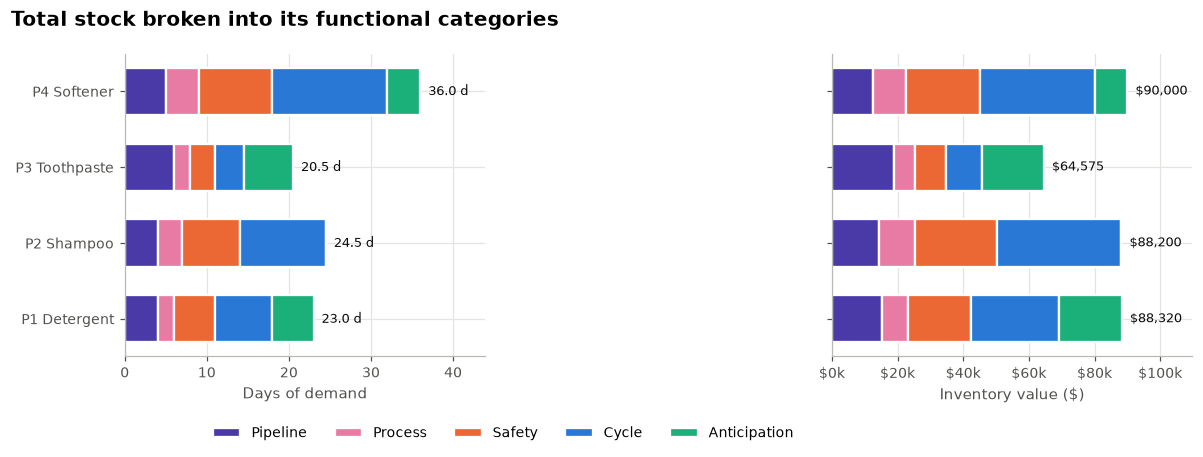

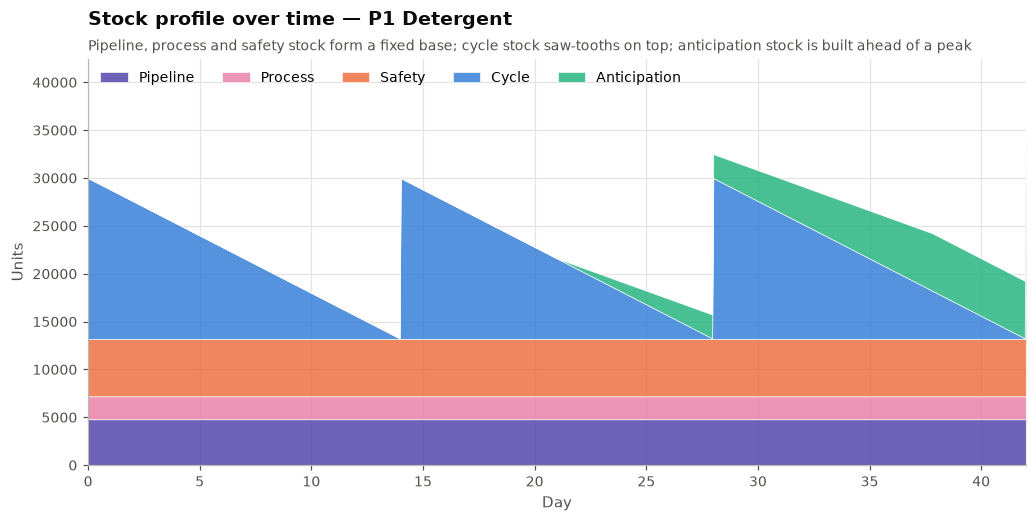

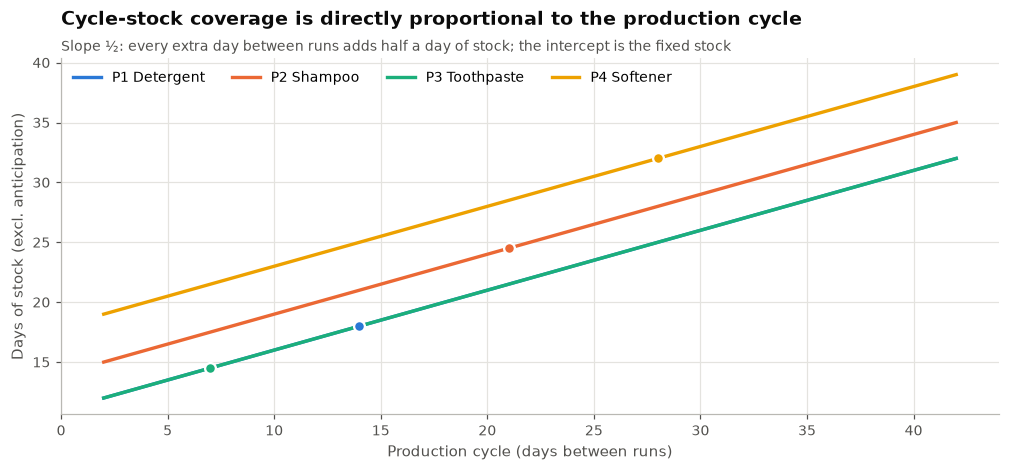

*Stock components in days of demand.*

,product,Pipeline,Process,Safety,Cycle,Anticipation,Total
0,P1 Detergent,4.0,2.0,5.0,7.0,5.0,23.0
1,P2 Shampoo,4.0,3.0,7.0,10.5,0.0,24.5
2,P3 Toothpaste,6.0,2.0,3.0,3.5,6.0,20.5
3,P4 Softener,5.0,4.0,9.0,14.0,4.0,36.0


*Stock components in units.*

,product,Pipeline,Process,Safety,Cycle,Anticipation,Total
0,P1 Detergent,"4,800","2,400","6,000","8,400","6,000","27,600"
1,P2 Shampoo,"3,200","2,400","5,600","8,400",0,"19,600"
2,P3 Toothpaste,"9,000","3,000","4,500","5,250","9,000","30,750"
3,P4 Softener,"2,500","2,000","4,500","7,000","2,000","18,000"


*Stock components in value ($).*

,product,Pipeline,Process,Safety,Cycle,Anticipation,Total
0,P1 Detergent,"15,360","7,680","19,200","26,880","19,200","88,320"
1,P2 Shampoo,"14,400","10,800","25,200","37,800",0,"88,200"
2,P3 Toothpaste,"18,900","6,300","9,450","11,025","18,900","64,575"
3,P4 Softener,"12,500","10,000","22,500","35,000","10,000","90,000"


📄 **PDF report exported:** `reports\P2_3_total_stock.pdf`

In [16]:
STOCK_ORDER = ["Pipeline", "Process", "Safety", "Cycle", "Anticipation"]
STOCK_COL = {"Pipeline": C["violet"], "Process": C["magenta"], "Safety": C["orange"], "Cycle": C["blue"],
             "Anticipation": C["aqua"]}

def run_total_stock(df=None):
    df = pd.read_csv(DATA / "stock_components_products.csv") if df is None else df.copy()
    sec = Section("P2_3_total_stock", "Total stock: cycle, safety, process, pipeline and anticipation stock",
                  part="Part 2 · Categories of stock")
    days = pd.DataFrame({"product": df["product"],
                         "Pipeline": df.pipeline_stock_days, "Process": df.process_stock_days,
                         "Safety": df.safety_stock_days, "Cycle": df.production_cycle_days / 2,
                         "Anticipation": df.anticipation_stock_units / df.daily_demand_units})
    units = days.copy(); units[STOCK_ORDER] = days[STOCK_ORDER].mul(df.daily_demand_units, axis=0)
    value = units.copy(); value[STOCK_ORDER] = units[STOCK_ORDER].mul(df.unit_cost, axis=0)
    days["Total"] = days[STOCK_ORDER].sum(1); units["Total"] = units[STOCK_ORDER].sum(1); value["Total"] = value[STOCK_ORDER].sum(1)

    sec.equation("Pipeline stock = daily demand × transit days  (Little's law);  Cycle = ½ × cycle days",
                 r"I_{pipeline}=d\times T_{transit},\qquad I_{cycle}=\tfrac12\,T_{cycle}\,d")
    tot_val = value.Total.sum()
    share = value[STOCK_ORDER].sum() / tot_val
    sec.metrics({"Total inventory value": f"${tot_val:,.0f}",
                 **{f"{k} share of value": f"{100*v:.1f} %" for k, v in share.items()},
                 "Highest days of cover": f"{days.loc[days.Total.idxmax(), 'product']} ({days.Total.max():.1f} days)"})

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
    for ax, (dfp, lab, pre) in zip(axs, [(days, "Days of demand", ""), (value, "Inventory value ($)", "$")]):
        left = np.zeros(len(dfp))
        for k in STOCK_ORDER:
            ax.barh(dfp["product"], dfp[k], left=left, color=STOCK_COL[k], edgecolor=SURF, linewidth=1.5, height=0.62,
                    label=k)
            left += dfp[k].values
        for yi, tv in enumerate(dfp.Total):
            ax.text(tv, yi, f"  {pre}{tv:,.0f}" if pre else f"  {tv:.1f} d", va="center", fontsize=8.5, color=INK)
        ax.set_xlabel(lab); ax.invert_yaxis(); ax.set_xlim(0, dfp.Total.max() * 1.22)
        if pre: axis_fmt(ax, "x", pre="$", scale=1e3, suf="k")
    axs[0].legend(loc="lower center", ncol=5, bbox_to_anchor=(1.05, -0.32))
    fig.suptitle("Total stock broken into its functional categories", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Stacked stock components per product, in days of demand (left) and in value (right).")

    # time profile for the first product
    r = df.iloc[0]; d = r.daily_demand_units; T = r.production_cycle_days; H = T * 3
    t, cyc = sawtooth(T * d, d, H)
    pipe = r.pipeline_stock_days * d; proc = r.process_stock_days * d; ss = r.safety_stock_days * d
    ant = np.where(t > T * 1.5, r.anticipation_stock_units * np.clip((t - T * 1.5) / (T * 1.2), 0, 1), 0)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    layers = [("Pipeline", np.full_like(t, pipe)), ("Process", np.full_like(t, proc)), ("Safety", np.full_like(t, ss)),
              ("Cycle", cyc), ("Anticipation", ant)]
    ax.stackplot(t, *[l for _, l in layers], colors=[STOCK_COL[k] for k, _ in layers], labels=[k for k, _ in layers],
                 alpha=0.8, edgecolor=SURF, linewidth=0.5)
    ax.set_xlabel("Day"); ax.set_ylabel("Units"); ax.legend(loc="upper left", ncol=5); ax.margins(x=0)
    ax.set_ylim(0, (pipe + proc + ss + T * d + r.anticipation_stock_units) * 1.18)
    style_title(ax, f"Stock profile over time — {r['product']}",
                "Pipeline, process and safety stock form a fixed base; cycle stock saw-tooths on top; "
                "anticipation stock is built ahead of a peak")
    sec.figure(fig, "Layered inventory profile (illustrative anticipation build in the last third of the horizon).")

    fig, ax = plt.subplots(figsize=(11, 4.2))
    cyc_grid = np.arange(2, 43)
    for (_, r), colr in zip(df.iterrows(), SERIES):
        tot = r.pipeline_stock_days + r.process_stock_days + r.safety_stock_days + cyc_grid / 2
        ax.plot(cyc_grid, tot, color=colr, lw=2.2, label=r["product"])
        ax.scatter([r.production_cycle_days], [r.pipeline_stock_days + r.process_stock_days + r.safety_stock_days
                                              + r.production_cycle_days / 2], color=colr, s=50, zorder=3,
                   edgecolor=SURF, linewidth=1.5)
    ax.set_xlabel("Production cycle (days between runs)"); ax.set_ylabel("Days of stock (excl. anticipation)")
    ax.legend(ncol=4, loc="upper left")
    style_title(ax, "Cycle-stock coverage is directly proportional to the production cycle",
                "Slope ½: every extra day between runs adds half a day of stock; the intercept is the fixed stock")
    sec.figure(fig, "Sensitivity of total days of stock to the production cycle length. Dots = current cycles.")
    sec.table(days, "Stock components in days of demand.", formats={k: ".1f" for k in STOCK_ORDER + ["Total"]})
    sec.table(units, "Stock components in units.", formats={k: ",.0f" for k in STOCK_ORDER + ["Total"]})
    sec.table(value, "Stock components in value ($).", formats={k: ",.0f" for k in STOCK_ORDER + ["Total"]})
    return sec, (days, units, value)

sec_total, total_tabs = run_total_stock()
export_section(sec_total);

## 2.4 Anticipation stock under limited capacity (slide 17)

When seasonal or promotional demand exceeds capacity in some months, the shortfall must be **pre-produced** in earlier months and carried as **anticipation stock**. Planned **shutdowns** also cut capacity.

With capacity $K_t$ and demand $D_t$, the *minimum* inventory that must be on hand at the end of month $t$ is found by a backward pass:

$$E_{12}=0,\qquad E_{t-1}=\max\left(0,\; D_t - K_t + E_t\right)$$

If $E_0 > 0$ the plan is **infeasible** without opening stock — capacity is insufficient and more capacity (overtime, subcontracting, hiring — see Part 6.6) is needed.

**Input file:** `data/seasonal_demand_capacity.csv` (monthly demand forecast incl. a Nov–Dec promotion, regular and overtime capacity, August shutdown flag) and `scenario_parameters.json → capacity_costs.shutdown_capacity_fraction`.

Annual demand **16,000** units; regular capacity **1,250**/month (+200 overtime); August shutdown runs at **50 %** capacity.

$$E_{t-1}=\max\left(0,\;D_t-K_t+E_t\right),\quad E_{12}=0$$

,Value
Key result,
Regular capacity only,"INFEASIBLE — short 1,625 units"
Regular + overtime,Feasible
Peak anticipation stock,"1,775 units (May)"
Average anticipation stock,721 units
Overtime units needed,"2,050"
Months demand > capacity,5


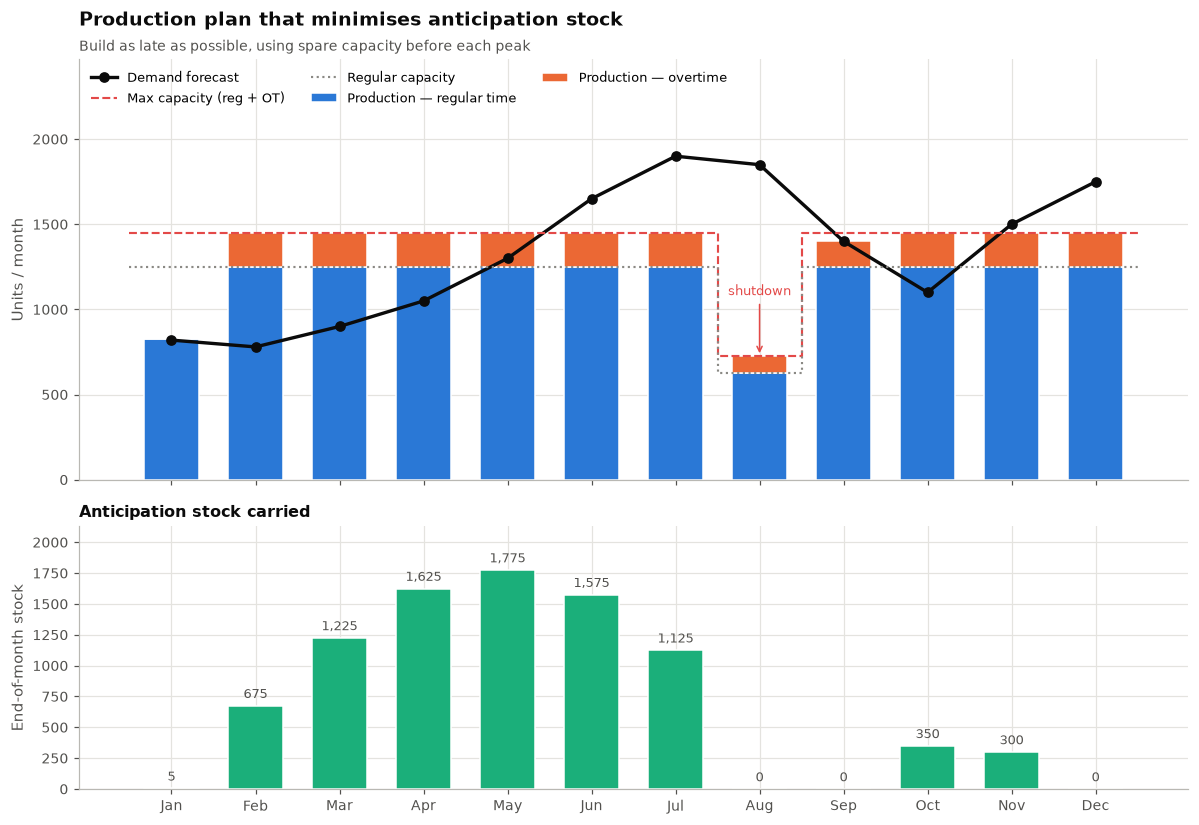

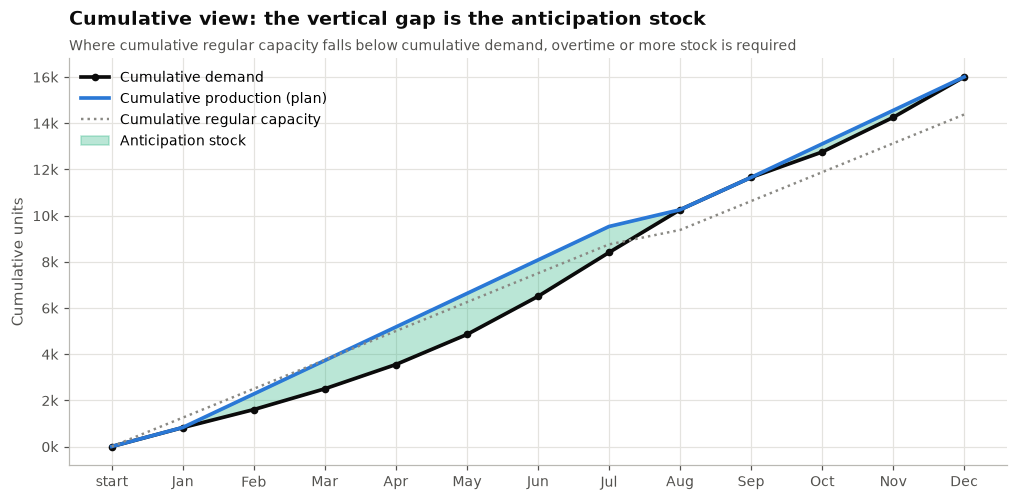

*Monthly anticipation-stock plan (effective capacities include the shutdown).*

,month,demand_forecast,reg_cap_eff,total_cap_eff,regular_used,overtime_used,production_plan,anticipation_stock_end
0,Jan,820,"1,250","1,450",825,0,825,5
1,Feb,780,"1,250","1,450","1,250",200,"1,450",675
2,Mar,900,"1,250","1,450","1,250",200,"1,450","1,225"
3,Apr,"1,050","1,250","1,450","1,250",200,"1,450","1,625"
4,May,"1,300","1,250","1,450","1,250",200,"1,450","1,775"
5,Jun,"1,650","1,250","1,450","1,250",200,"1,450","1,575"
6,Jul,"1,900","1,250","1,450","1,250",200,"1,450","1,125"
7,Aug,"1,850",625,725,625,100,725,0
8,Sep,"1,400","1,250","1,450","1,250",150,"1,400",0
9,Oct,"1,100","1,250","1,450","1,250",200,"1,450",350


📄 **PDF report exported:** `reports\P2_4_anticipation_stock.pdf`

In [17]:
def min_anticipation_plan(demand, cap):
    demand, cap = np.asarray(demand, float), np.asarray(cap, float)
    n = len(demand); E = np.zeros(n + 1)            # E[t] = end inventory after month t (E[0] = opening)
    for t in range(n, 0, -1):
        E[t - 1] = max(0.0, demand[t - 1] - cap[t - 1] + E[t])
    shortage_opening = E[0]
    E[0] = 0.0
    prod = np.array([demand[t] + E[t + 1] - E[t] for t in range(n)])
    prod = np.minimum(prod, cap)
    end_inv = np.cumsum(prod - demand)
    return prod, end_inv, shortage_opening

def run_anticipation(df=None, p=None):
    df = pd.read_csv(DATA / "seasonal_demand_capacity.csv") if df is None else df.copy()
    p = p or PARAMS["capacity_costs"]
    sec = Section("P2_4_anticipation_stock", "Anticipation stock: pre-building for seasonal peaks, promotions and shutdowns",
                  part="Part 2 · Categories of stock")
    f = np.where(df.planned_shutdown == 1, p["shutdown_capacity_fraction"], 1.0)
    df["reg_cap_eff"] = df.regular_capacity * f
    df["total_cap_eff"] = (df.regular_capacity + df.overtime_capacity) * f
    res = {}
    for name, capcol in [("Regular only", "reg_cap_eff"), ("Regular + overtime", "total_cap_eff")]:
        prod, inv, short = min_anticipation_plan(df.demand_forecast, df[capcol])
        res[name] = dict(prod=prod, inv=inv, short=short)
    feas = res["Regular + overtime"]
    df["production_plan"] = feas["prod"]
    df["regular_used"] = np.minimum(feas["prod"], df.reg_cap_eff)
    df["overtime_used"] = feas["prod"] - df.regular_used
    df["anticipation_stock_end"] = feas["inv"]
    D = df.demand_forecast

    sec.text(f"Annual demand **{D.sum():,}** units; regular capacity **{df.regular_capacity.iloc[0]:,}**/month "
             f"(+{df.overtime_capacity.iloc[0]} overtime); August shutdown runs at "
             f"**{100*p['shutdown_capacity_fraction']:.0f} %** capacity.")
    sec.equation("E(t−1) = max(0, D(t) − K(t) + E(t)),  E(12) = 0",
                 r"E_{t-1}=\max\left(0,\;D_t-K_t+E_t\right),\quad E_{12}=0")
    sec.metrics({"Regular capacity only": ("INFEASIBLE — short " + f"{res['Regular only']['short']:,.0f} units")
                 if res["Regular only"]["short"] > 0 else "Feasible",
                 "Regular + overtime": "Feasible" if feas["short"] == 0 else f"short {feas['short']:,.0f}",
                 "Peak anticipation stock": f"{feas['inv'].max():,.0f} units ({df.month[int(np.argmax(feas['inv']))]})",
                 "Average anticipation stock": f"{feas['inv'].mean():,.0f} units",
                 "Overtime units needed": f"{df.overtime_used.sum():,.0f}",
                 "Months demand > capacity": f"{int((D > df.total_cap_eff).sum())}"})

    x = np.arange(len(df))
    fig, axs = plt.subplots(2, 1, figsize=(11, 7.6), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})
    ax = axs[0]
    ax.bar(x, df.regular_used, color=C["blue"], width=0.65, edgecolor=SURF, label="Production — regular time")
    ax.bar(x, df.overtime_used, bottom=df.regular_used, color=C["orange"], width=0.65, edgecolor=SURF,
           label="Production — overtime")
    ax.plot(x, D, color=INK, marker="o", lw=2.2, label="Demand forecast")
    ax.step(np.r_[x - 0.5, x[-1] + 0.5], np.r_[df.total_cap_eff, df.total_cap_eff.iloc[-1]], where="post",
            color=C["red"], ls="--", lw=1.4, label="Max capacity (reg + OT)")
    ax.step(np.r_[x - 0.5, x[-1] + 0.5], np.r_[df.reg_cap_eff, df.reg_cap_eff.iloc[-1]], where="post",
            color=MUTED, ls=":", lw=1.4, label="Regular capacity")
    sd = np.where(df.planned_shutdown == 1)[0]
    for s in sd:
        ax.annotate("shutdown", (s, df.total_cap_eff[s]), xytext=(0, 40), textcoords="offset points", ha="center",
                    fontsize=8.5, color=C["red"], arrowprops=dict(arrowstyle="->", color=C["red"]))
    ax.set_ylabel("Units / month"); ax.legend(ncol=3, loc="upper left", fontsize=8.5)
    ax.set_ylim(0, max(D.max(), df.total_cap_eff.max()) * 1.3)
    style_title(ax, "Production plan that minimises anticipation stock",
                "Build as late as possible, using spare capacity before each peak")
    axs[1].bar(x, feas["inv"], color=C["aqua"], width=0.65, edgecolor=SURF)
    label_bars(axs[1], axs[1].patches, "{:,.0f}")
    axs[1].set_ylabel("End-of-month stock"); axs[1].set_title("Anticipation stock carried", fontsize=10.5)
    axs[1].set_xticks(x); axs[1].set_xticklabels(df.month)
    axs[1].set_ylim(0, feas["inv"].max() * 1.2 + 1)
    fig.tight_layout()
    sec.figure(fig, "Monthly demand vs capacity, the resulting production plan, and anticipation stock.")

    fig, ax = plt.subplots(figsize=(11, 4.8))
    cumD = np.r_[0, D.cumsum()]; cumP = np.r_[0, np.cumsum(feas["prod"])]
    cumK = np.r_[0, df.reg_cap_eff.cumsum()]
    xm = np.arange(len(df) + 1)
    ax.plot(xm, cumD, color=INK, lw=2.4, marker="o", ms=4, label="Cumulative demand")
    ax.plot(xm, cumP, color=C["blue"], lw=2.4, label="Cumulative production (plan)")
    ax.plot(xm, cumK, color=MUTED, lw=1.6, ls=":", label="Cumulative regular capacity")
    ax.fill_between(xm, cumD, cumP, where=cumP >= cumD, color=C["aqua"], alpha=0.3, label="Anticipation stock")
    ax.set_xticks(xm); ax.set_xticklabels(["start"] + list(df.month)); axis_fmt(ax, scale=1e3, suf="k")
    ax.set_ylabel("Cumulative units"); ax.legend(loc="upper left")
    style_title(ax, "Cumulative view: the vertical gap is the anticipation stock",
                "Where cumulative regular capacity falls below cumulative demand, overtime or more stock is required")
    sec.figure(fig, "Cumulative demand, production and regular capacity.")
    sec.table(df[["month", "demand_forecast", "reg_cap_eff", "total_cap_eff", "regular_used", "overtime_used",
                  "production_plan", "anticipation_stock_end"]],
              "Monthly anticipation-stock plan (effective capacities include the shutdown).",
              formats={c: ",.0f" for c in ["demand_forecast", "reg_cap_eff", "total_cap_eff", "regular_used",
                                            "overtime_used", "production_plan", "anticipation_stock_end"]})
    return sec, df

sec_antic, antic_df = run_anticipation()
export_section(sec_antic);

### Decoupling stock
Decoupling stock sits *between* stages so that each can run at its own pace. The quick simulation below shows a two-stage line where stage 1 and stage 2 have random daily outputs: with no buffer the line only produces what the *slower* stage makes each day; a decoupling buffer lets stage 2 keep working when stage 1 has a bad day.

Two stages, each with mean capacity **100**/day and CV **25%**. Throughput is limited by the slower stage every day unless a buffer decouples them.

,Value
Key result,
"Throughput, no buffer",85.9 /day
"Throughput, buffer 400",99.7 /day
Gain,16.2 %


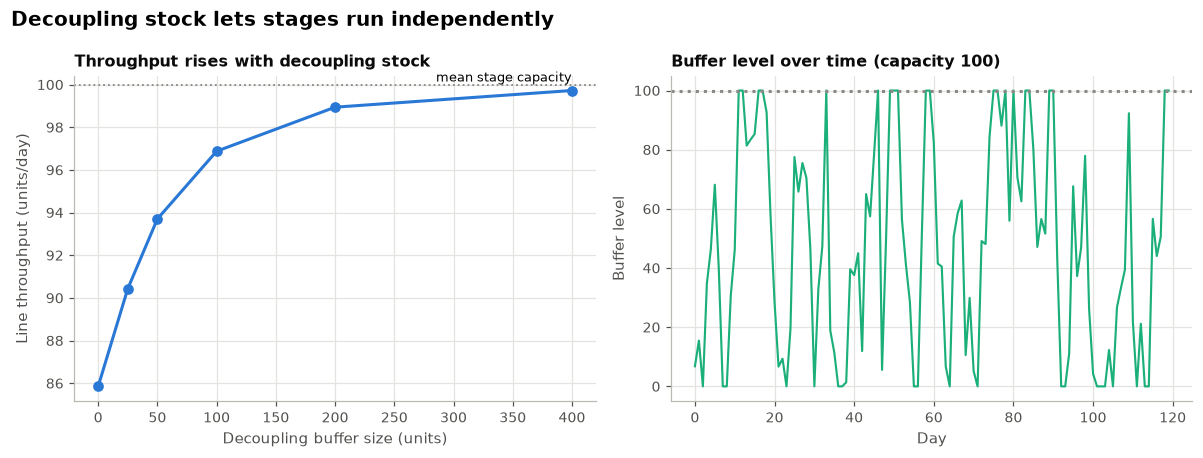

*Throughput vs buffer size.*

,buffer_capacity,throughput_per_day,utilisation_stage2_pct,avg_buffer_stock
0,0,85.9,86.1,0.0
1,25,90.4,90.7,13.0
2,50,93.7,94.0,26.5
3,100,96.9,97.1,54.3
4,200,98.9,99.2,125.1
5,400,99.7,100.0,266.9


📄 **PDF report exported:** `reports\P2_5_decoupling_stock.pdf`

In [18]:
def run_decoupling(days=250, mean_rate=100, cv=0.25, buffers=(0, 25, 50, 100, 200, 400), seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    sec = Section("P2_5_decoupling_stock", "Decoupling stock between two production stages",
                  part="Part 2 · Categories of stock")
    cap1 = np.maximum(0, rng.normal(mean_rate, cv * mean_rate, days))
    cap2 = np.maximum(0, rng.normal(mean_rate, cv * mean_rate, days))
    rows, traces = [], {}
    for B in buffers:
        buf, out, lvl = B / 2, 0.0, []
        for t in range(days):
            made = min(cap1[t], B - buf + cap2[t]) if B > 0 else min(cap1[t], cap2[t])
            if B > 0:
                buf += made
                take = min(cap2[t], buf); buf -= take; out += take
            else:
                out += made
            lvl.append(buf)
        traces[B] = np.array(lvl)
        rows.append({"buffer_capacity": B, "throughput_per_day": out / days,
                     "utilisation_stage2_pct": 100 * out / cap2.sum(), "avg_buffer_stock": np.mean(lvl)})
    tab = pd.DataFrame(rows)
    sec.text(f"Two stages, each with mean capacity **{mean_rate}**/day and CV **{cv:.0%}**. "
             "Throughput is limited by the slower stage every day unless a buffer decouples them.")
    sec.metrics({"Throughput, no buffer": f"{tab.throughput_per_day.iloc[0]:.1f} /day",
                 f"Throughput, buffer {buffers[-1]}": f"{tab.throughput_per_day.iloc[-1]:.1f} /day",
                 "Gain": f"{100*(tab.throughput_per_day.iloc[-1]/tab.throughput_per_day.iloc[0]-1):.1f} %"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
    axs[0].plot(tab.buffer_capacity, tab.throughput_per_day, "o-", color=C["blue"])
    axs[0].axhline(mean_rate, color=MUTED, ls=":", lw=1.2); axs[0].text(tab.buffer_capacity.max(), mean_rate, "mean stage capacity",
                                                                       ha="right", va="bottom", fontsize=8.5)
    axs[0].set_xlabel("Decoupling buffer size (units)"); axs[0].set_ylabel("Line throughput (units/day)")
    axs[0].set_title("Throughput rises with decoupling stock", fontsize=10.5)
    Bm = buffers[len(buffers) // 2]
    axs[1].plot(traces[Bm][:120], color=C["aqua"], lw=1.4)
    axs[1].axhline(Bm, color=MUTED, ls=":"); axs[1].set_xlabel("Day"); axs[1].set_ylabel("Buffer level")
    axs[1].set_title(f"Buffer level over time (capacity {Bm})", fontsize=10.5)
    fig.suptitle("Decoupling stock lets stages run independently", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Two-stage line simulation.")
    sec.table(tab, "Throughput vs buffer size.", formats={"buffer_capacity": "d", "throughput_per_day": ".1f",
                                                           "utilisation_stage2_pct": ".1f", "avg_buffer_stock": ".1f"})
    return sec, tab

sec_decouple, decouple_tab = run_decoupling()
export_section(sec_decouple);

---
# Part 3 — Why is inventory management so difficult? (slides 20–26)

1. **Sheer number of items.** A washing machine has ~60 parts, a modern car > 30,000; large manufacturers and military organisations stock > 500,000 SKUs, department stores ~100,000, a medium-sized manufacturer ~10,000.
2. **Items differ in many ways** — value, volume, lead time, shelf life, criticality, demand pattern.
3. **Products are structured** — demand for components is *dependent* on end-item demand through the bill of materials (BOM).
4. **Variety keeps growing** — splitting demand across more variants raises the total stock needed for the same service.
5. For *each* item we must answer the **three basic questions**:
   - How often should the inventory status be determined? *(review period)*
   - When should a replenishment order be placed? *(reorder point / timing)*
   - How large should the replenishment order be? *(order quantity)*

## 3.1 SKU diversity and the bill of materials

**Input files:** `data/bom_washing_machine.csv` (parent → component, quantity per parent) and `data/mps_washing_machine.csv` (12-week end-item demand).

Every end item explodes into many components whose demand is **dependent** — it is *calculated* from the end-item plan, not forecast. Independent demand (end items, spare parts) must be forecast.

,Value
Key result,
Distinct purchased components in WM-100 (model BOM),18
Total component units per machine,61
BOM levels,2
12-week machine demand,"5,990"
12-week component units required,"365,390"


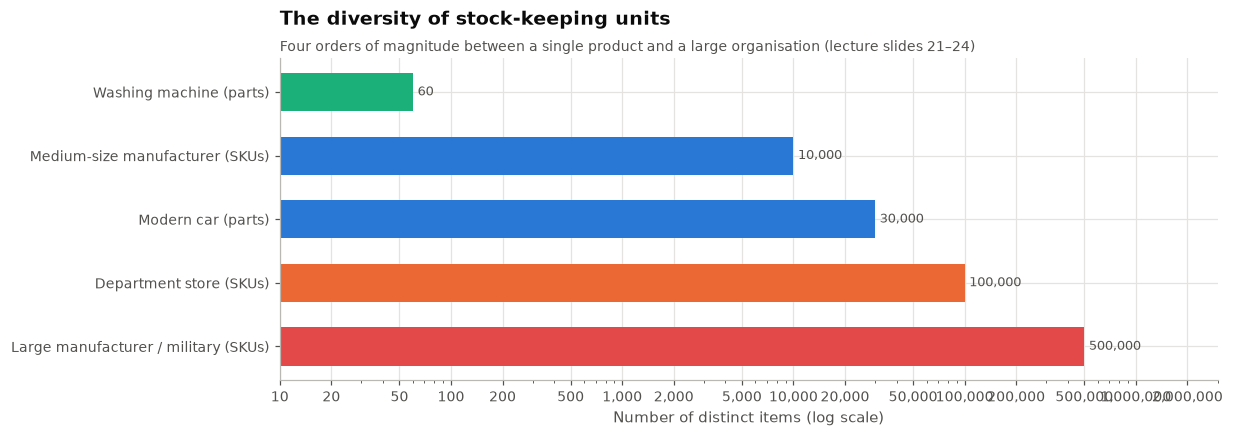

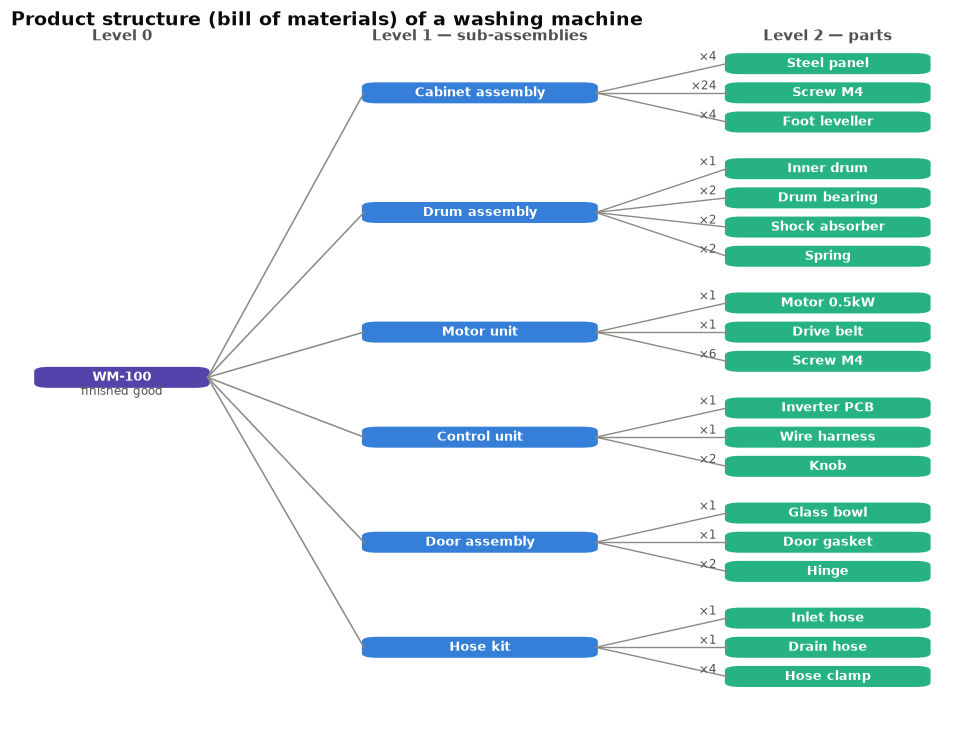

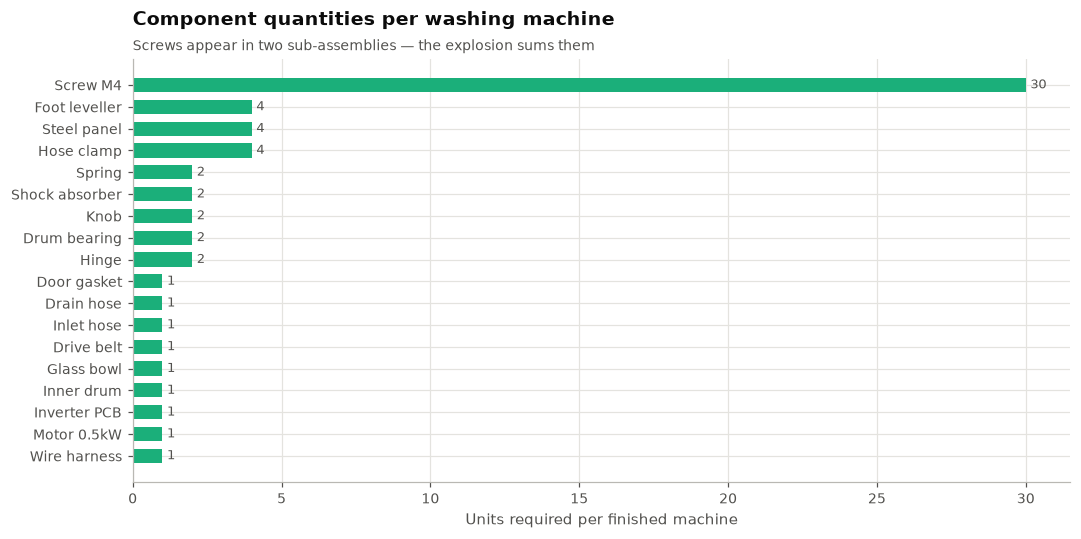

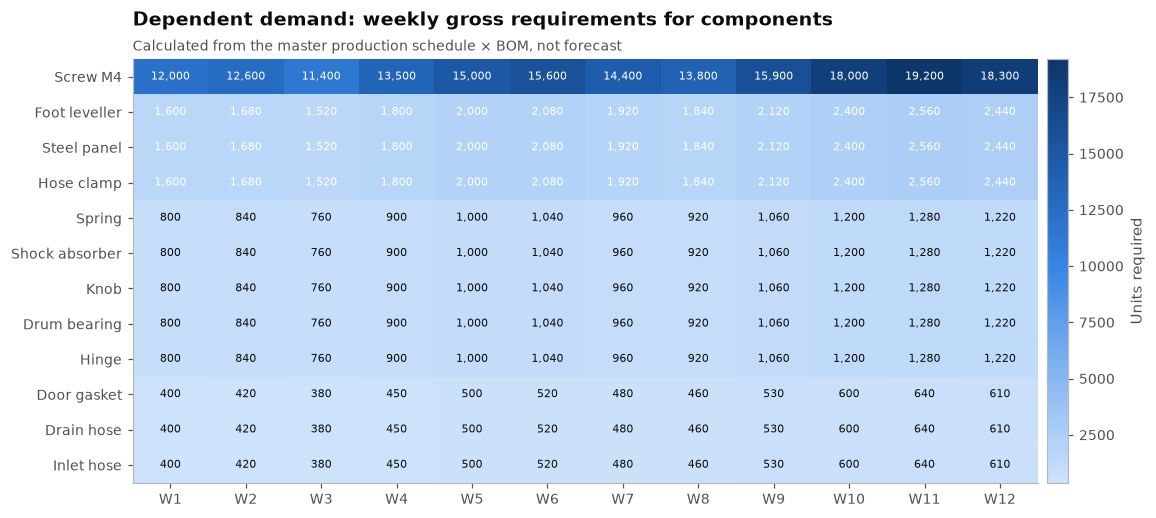

*Indented BOM explosion.*

,level,parent,component,qty_per_parent,qty_per_end_item
0,1,WM-100,Cabinet assembly,1,1
1,2,Cabinet assembly,Steel panel,4,4
2,2,Cabinet assembly,Screw M4,24,24
3,2,Cabinet assembly,Foot leveller,4,4
4,1,WM-100,Drum assembly,1,1
5,2,Drum assembly,Inner drum,1,1
6,2,Drum assembly,Drum bearing,2,2
7,2,Drum assembly,Shock absorber,2,2
8,2,Drum assembly,Spring,2,2
9,1,WM-100,Motor unit,1,1


*Gross requirements by component and week.*

,component,W1,W2,W3,W4,W5,W6,W7,W8,W9,W10,W11,W12
0,Screw M4,"12,000","12,600","11,400","13,500","15,000","15,600","14,400","13,800","15,900","18,000","19,200","18,300"
1,Foot leveller,"1,600","1,680","1,520","1,800","2,000","2,080","1,920","1,840","2,120","2,400","2,560","2,440"
2,Steel panel,"1,600","1,680","1,520","1,800","2,000","2,080","1,920","1,840","2,120","2,400","2,560","2,440"
3,Hose clamp,"1,600","1,680","1,520","1,800","2,000","2,080","1,920","1,840","2,120","2,400","2,560","2,440"
4,Spring,800,840,760,900,"1,000","1,040",960,920,"1,060","1,200","1,280","1,220"
5,Shock absorber,800,840,760,900,"1,000","1,040",960,920,"1,060","1,200","1,280","1,220"
6,Knob,800,840,760,900,"1,000","1,040",960,920,"1,060","1,200","1,280","1,220"
7,Drum bearing,800,840,760,900,"1,000","1,040",960,920,"1,060","1,200","1,280","1,220"
8,Hinge,800,840,760,900,"1,000","1,040",960,920,"1,060","1,200","1,280","1,220"
9,Door gasket,400,420,380,450,500,520,480,460,530,600,640,610


📄 **PDF report exported:** `reports\P3_1_sku_diversity_bom.pdf`

In [19]:
def explode_bom(bom, item, qty=1.0, level=0, out=None, path=None):
    out = [] if out is None else out
    for _, r in bom[bom.parent == item].iterrows():
        q = qty * r.qty_per_parent
        out.append({"level": level + 1, "parent": item, "component": r.component, "qty_per_parent": r.qty_per_parent,
                    "qty_per_end_item": q})
        explode_bom(bom, r.component, q, level + 1, out)
    return out

def run_bom(bom=None, mps=None, top="WM-100"):
    bom = pd.read_csv(DATA / "bom_washing_machine.csv") if bom is None else bom.copy()
    mps = pd.read_csv(DATA / "mps_washing_machine.csv") if mps is None else mps.copy()
    sec = Section("P3_1_sku_diversity_bom", "Why it is difficult: SKU diversity, BOMs and dependent demand",
                  part="Part 3 · Why is it difficult?")
    ex = pd.DataFrame(explode_bom(bom, top))
    leaves = ex[~ex.component.isin(bom.parent)]
    per_unit = leaves.groupby("component").qty_per_end_item.sum().sort_values(ascending=False)
    req = pd.DataFrame(np.outer(mps.wm100_demand, per_unit.values), columns=per_unit.index, index=mps.week)

    sku_facts = pd.DataFrame({"context": ["Washing machine (parts)", "Medium-size manufacturer (SKUs)",
                                          "Modern car (parts)", "Department store (SKUs)",
                                          "Large manufacturer / military (SKUs)"],
                              "count": [60, 10_000, 30_000, 100_000, 500_000]})
    sec.text("Every end item explodes into many components whose demand is **dependent** — it is *calculated* from the "
             "end-item plan, not forecast. Independent demand (end items, spare parts) must be forecast.")
    sec.metrics({"Distinct purchased components in WM-100 (model BOM)": f"{len(per_unit)}",
                 "Total component units per machine": f"{per_unit.sum():,.0f}",
                 "BOM levels": f"{ex.level.max()}",
                 "12-week machine demand": f"{mps.wm100_demand.sum():,}",
                 "12-week component units required": f"{req.values.sum():,.0f}"})

    fig, ax = plt.subplots(figsize=(11, 3.8))
    b = ax.barh(sku_facts.context, sku_facts["count"], color=[C["aqua"], C["blue"], C["blue"], C["orange"], C["red"]],
                height=0.6)
    logscale(ax, "x"); ax.invert_yaxis(); label_bars(ax, b, "{:,.0f}", horizontal=True)
    ax.set_xlim(10, 3e6); ax.set_xlabel("Number of distinct items (log scale)")
    style_title(ax, "The diversity of stock-keeping units", "Four orders of magnitude between a single product and a "
                "large organisation (lecture slides 21–24)")
    sec.figure(fig, "Item counts quoted in the lecture.")

    # BOM tree diagram
    lvl1 = bom[bom.parent == top].component.tolist()
    fig, ax = plt.subplots(figsize=(11, 8.2)); ax.axis("off")
    ys, y = {}, 0
    leaf_rows = []
    for p1 in lvl1:
        kids = bom[bom.parent == p1]
        ky = []
        for _, k in kids.iterrows():
            leaf_rows.append((p1, k.component, k.qty_per_parent, y)); ky.append(y); y -= 1
        ys[p1] = np.mean(ky); y -= 0.6
    ytop = np.mean(list(ys.values()))
    def box(x, yy, txt, colr, w=2.3):
        ax.add_patch(FancyBboxPatch((x - w / 2, yy - 0.34), w, 0.68, boxstyle="round,pad=0.02,rounding_size=0.15",
                                    fc=colr, ec="none", alpha=0.95))
        ax.text(x, yy, txt, ha="center", va="center", fontsize=8.3, color="white" if colr != GRID else INK,
                fontweight="bold")
    for p1 in lvl1:
        ax.plot([0.85, 2.4], [ytop, ys[p1]], color=MUTED, lw=1)
    for p1, comp, q, yy in leaf_rows:
        ax.plot([4.7, 6.0], [ys[p1], yy], color=MUTED, lw=0.9)
        ax.text(5.9, yy + 0.12, f"×{q:g}", ha="right", fontsize=7.8, color=INK2)
    box(0, ytop, top, C["violet"], w=1.7)
    ax.text(0, ytop - 0.6, "finished good", ha="center", fontsize=8, color=INK2)
    for p1 in lvl1:
        box(3.55, ys[p1], p1, C["blue"])
    for _, comp, _, yy in leaf_rows:
        box(7.0, yy, comp, C["aqua"], w=2.0)
    ax.set_xlim(-1.1, 8.2); ax.set_ylim(y - 0.2, 1)
    for xx, t in [(0, "Level 0"), (3.55, "Level 1 — sub-assemblies"), (7.0, "Level 2 — parts")]:
        ax.text(xx, 0.8, t, ha="center", fontsize=9.5, color=INK2, fontweight="bold")
    ax.set_title("Product structure (bill of materials) of a washing machine", loc="left", fontsize=12.5,
                 fontweight="bold")
    sec.figure(fig, "Simplified 3-level BOM. Numbers on the links = quantity per parent.")

    fig, ax = plt.subplots(figsize=(11, 5))
    b = ax.barh(per_unit.index, per_unit.values, color=C["aqua"], height=0.65)
    ax.invert_yaxis(); label_bars(ax, b, "{:,.0f}", horizontal=True)
    ax.set_xlabel("Units required per finished machine")
    style_title(ax, "Component quantities per washing machine", "Screws appear in two sub-assemblies — the explosion sums them")
    sec.figure(fig, "Result of the multi-level BOM explosion.")

    top_c = per_unit.index[:12]
    fig, ax = plt.subplots(figsize=(11, 5))
    M = req[top_c].T.values
    im = ax.imshow(M, cmap=SEQ_CMAP, aspect="auto")
    ax.set_yticks(range(len(top_c))); ax.set_yticklabels(top_c); ax.grid(False)
    ax.set_xticks(range(len(req))); ax.set_xticklabels([f"W{w}" for w in req.index])
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i, j]:,.0f}", ha="center", va="center", fontsize=7.2,
                    color="white" if M[i, j] > np.percentile(M, 65) else INK)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="Units required")
    style_title(ax, "Dependent demand: weekly gross requirements for components",
                "Calculated from the master production schedule × BOM, not forecast")
    sec.figure(fig, "Gross component requirements for the 12 most-used components (lead-time offsetting ignored).")
    sec.table(ex, "Indented BOM explosion.", formats={"level": "d", "qty_per_parent": "g", "qty_per_end_item": "g"})
    rq = req.T.reset_index().rename(columns={"index": "component"})
    rq.columns = ["component"] + [f"W{w}" for w in req.index]
    sec.table(rq, "Gross requirements by component and week.", formats={f"W{w}": ",.0f" for w in req.index})
    return sec, req

sec_bom, bom_req = run_bom()
export_section(sec_bom);

## 3.2 Product variety and the marketing relationship (slides 8, 54)

Marketing favours **wide variety** and **high inventories** (demand met without delay) and may run **promotions** that shock the supply chain. Operations pays the price: if total demand $D$ with standard deviation $\sigma$ is split evenly across $n$ independent variants, each variant has $\sigma_i = \sigma/\sqrt n$ and the total safety stock becomes

$$SS_{total}(n)=n\,z\,\frac{\sigma}{\sqrt n}\sqrt{L}=\sqrt n\;SS_{total}(1)$$

— the **square-root law**: 4× the variants → 2× the safety stock for the same service. The analytic result is checked with a Monte-Carlo simulation.

**Input:** `scenario_parameters.json → product_variety_demo`.

$$SS_{total}(n)=\sqrt{n}\;SS_{total}(1)$$

,Value
Key result,
SS with 1 variant,"1,234 units"
SS with 64 variants,"9,870 units (×8.0)"
Target / simulated CSL,95.0% / 95.0%
Extra holding cost at max variety,"$63,908/yr"


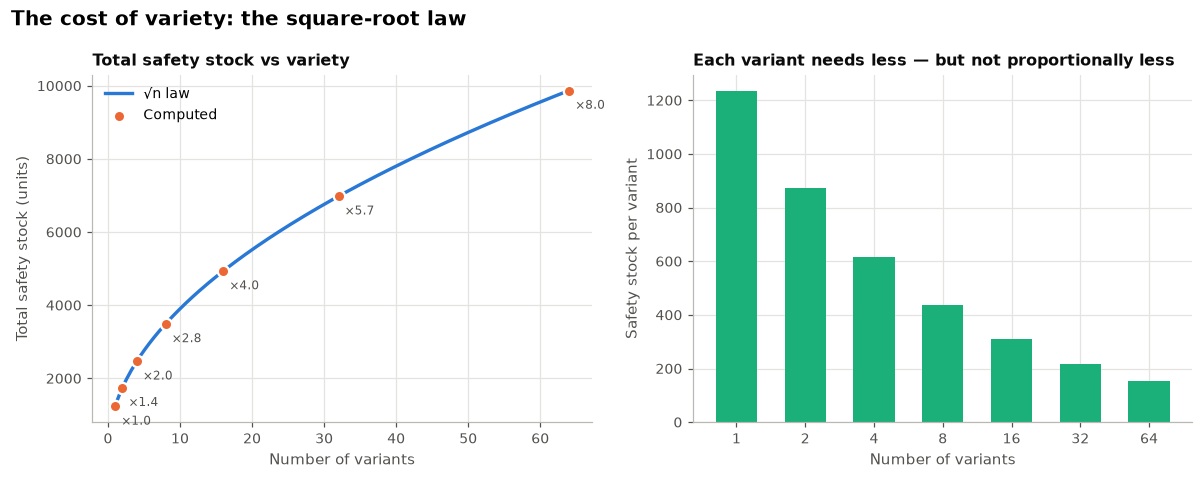

*Safety stock as variety grows.*

,n_variants,mean_daily_demand_per_variant,sigma_per_variant,SS_per_variant,SS_total,SS_total_index,simulated_CSL,annual_holding_cost_SS
0,1,"1,000.0",250.0,"1,233.8","1,234",1.00,95.5%,"9,130"
1,2,500.0,176.8,872.4,"1,745",1.41,94.6%,"12,911"
2,4,250.0,125.0,616.9,"2,468",2.00,95.1%,"18,260"
3,8,125.0,88.4,436.2,"3,490",2.83,95.0%,"25,823"
4,16,62.5,62.5,308.4,"4,935",4.00,95.0%,"36,519"
5,32,31.2,44.2,218.1,"6,979",5.66,95.0%,"51,646"
6,64,15.6,31.2,154.2,"9,870",8.00,94.9%,"73,038"


- Promotions create short demand spikes → anticipation stock or capacity costs (Parts 2.4, 6.6).
- Variety should be priced with its inventory consequence; *postponement* (customising late) pools demand.

📄 **PDF report exported:** `reports\P3_2_product_variety.pdf`

In [20]:
def run_variety(p=None, value_per_unit=20.0, holding_rate=None, reps=3000, seed=RNG_SEED):
    p = p or PARAMS["product_variety_demo"]
    holding_rate = holding_rate or PARAMS["holding_cost_rate"]
    rng = np.random.default_rng(seed)
    sec = Section("P3_2_product_variety", "Product variety multiplies the stock needed for the same service",
                  part="Part 3 · Why is it difficult?")
    D, cv, L, z = p["total_mean_daily_demand"], p["cv_per_sku_at_1"], p["lead_time_days"], p["z"]
    sigma = cv * D
    rows = []
    for n in p["sku_counts"]:
        si = sigma / math.sqrt(n)
        ss_sku = z * si * math.sqrt(L)
        # simulation: achieved CSL per SKU with that SS
        dlt = rng.normal(D / n * L, si * math.sqrt(L), (reps, n))
        csl = (dlt <= D / n * L + ss_sku).mean()
        rows.append({"n_variants": n, "mean_daily_demand_per_variant": D / n, "sigma_per_variant": si,
                     "SS_per_variant": ss_sku, "SS_total": n * ss_sku, "SS_total_index": n * ss_sku,
                     "simulated_CSL": csl, "annual_holding_cost_SS": n * ss_sku * value_per_unit * holding_rate})
    tab = pd.DataFrame(rows)
    tab["SS_total_index"] = tab.SS_total / tab.SS_total.iloc[0]
    sec.equation("SS_total(n) = √n × SS_total(1)", r"SS_{total}(n)=\sqrt{n}\;SS_{total}(1)")
    sec.metrics({"SS with 1 variant": f"{tab.SS_total.iloc[0]:,.0f} units",
                 f"SS with {tab.n_variants.iloc[-1]} variants": f"{tab.SS_total.iloc[-1]:,.0f} units "
                                                                f"(×{tab.SS_total_index.iloc[-1]:.1f})",
                 "Target / simulated CSL": f"{stats.norm.cdf(z):.1%} / {tab.simulated_CSL.mean():.1%}",
                 "Extra holding cost at max variety": f"${tab.annual_holding_cost_SS.iloc[-1]-tab.annual_holding_cost_SS.iloc[0]:,.0f}/yr"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
    nn = np.linspace(1, tab.n_variants.max(), 200)
    axs[0].plot(nn, tab.SS_total.iloc[0] * np.sqrt(nn), color=C["blue"], lw=2.2, label="√n law")
    axs[0].scatter(tab.n_variants, tab.SS_total, color=C["orange"], s=55, zorder=3, edgecolor=SURF, linewidth=1.5,
                   label="Computed")
    for _, r in tab.iterrows():
        axs[0].annotate(f"×{r.SS_total_index:.1f}", (r.n_variants, r.SS_total), xytext=(4, -12),
                        textcoords="offset points", fontsize=8, color=INK2)
    axs[0].set_xlabel("Number of variants"); axs[0].set_ylabel("Total safety stock (units)"); axs[0].legend()
    axs[0].set_title("Total safety stock vs variety", fontsize=10.5)
    axs[1].bar(tab.n_variants.astype(str), tab.SS_per_variant, color=C["aqua"], width=0.6, label="SS per variant")
    axs[1].set_xlabel("Number of variants"); axs[1].set_ylabel("Safety stock per variant")
    axs[1].set_title("Each variant needs less — but not proportionally less", fontsize=10.5)
    fig.suptitle("The cost of variety: the square-root law", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, f"Total demand {D:,}/day, CV {cv:.0%}, lead time {L} days, z = {z}.")
    sec.table(tab, "Safety stock as variety grows.",
              formats={"n_variants": "d", "mean_daily_demand_per_variant": ",.1f", "sigma_per_variant": ",.1f",
                       "SS_per_variant": ",.1f", "SS_total": ",.0f", "SS_total_index": ".2f", "simulated_CSL": ".1%",
                       "annual_holding_cost_SS": ",.0f"})
    sec.bullets(["Promotions create short demand spikes → anticipation stock or capacity costs (Parts 2.4, 6.6).",
                 "Variety should be priced with its inventory consequence; *postponement* (customising late) pools demand."])
    return sec, tab

sec_variety, variety_tab = run_variety()
export_section(sec_variety);

### 3.3 The three basic questions
Every inventory control system must answer, **for each item**:

| Question | Decision variable | Answered in this course by |
|---|---|---|
| How often should inventory status be determined? | Review interval **R** (continuous vs periodic) | Control-system design by ABC class (Part 4) |
| When should a replenishment order be placed? | Reorder point **s** | Safety stock + lead-time demand (Part 2.2) |
| How large should the replenishment order be? | Order quantity **Q** | Ordering vs holding cost trade-off (Part 6.4) |

With thousands of SKUs, the effort spent answering these questions must be **prioritised** — which is exactly what ABC classification does.

---
# Part 4 — How do we begin? ABC classification (slides 27–35)

**Objective:** apply different levels of control according to the relative importance of items. Typical (Pareto) pattern:

| Class | % of items | % of annual dollar usage | Level of control |
|---|---|---|---|
| **A** | ≈ 20 % | ≈ 80 % | **Tight** — frequent review, accurate records, close follow-up |
| **B** | ≈ 30 % | ≈ 15 % | **Normal** |
| **C** | ≈ 50 % | ≈ 5 % | **Least possible** — keep plenty on hand, simple rules |

**Calculation steps** (slide 33):
1. Annual \$ usage = annual unit usage × unit cost.
2. Rank items by annual \$ usage (descending).
3. Cumulative \$ usage and cumulative % of \$ usage.
4. Cumulative % of items (each of *N* items adds 1/N).
5. Assign classes by cut-offs — either on **cumulative % of value** (e.g. A ≤ 80 %, B ≤ 95 %) or on **cumulative % of items** (A = first 20 %, B = next 30 %).

In [21]:
TRAPZ = getattr(np, "trapezoid", None) or getattr(np, "trapz")

def abc_classify(df, value_col="annual_dollar_usage", method="value", cut_value=(0.80, 0.95), cut_items=(0.20, 0.50)):
    d = df.sort_values(value_col, ascending=False).reset_index(drop=True).copy()
    n, tot = len(d), d[value_col].sum()
    d["rank"] = np.arange(1, n + 1)
    d["pct_of_value"] = d[value_col] / tot
    d["cum_value"] = d[value_col].cumsum()
    d["cum_pct_value"] = d.cum_value / tot
    d["cum_pct_items"] = d["rank"] / n
    if method == "value":
        a, b = cut_value
        d["class"] = np.where(d.cum_pct_value <= a + 1e-9, "A", np.where(d.cum_pct_value <= b + 1e-9, "B", "C"))
    else:
        a, b = cut_items
        d["class"] = np.where(d.cum_pct_items <= a + 1e-9, "A", np.where(d.cum_pct_items <= b + 1e-9, "B", "C"))
    return d

def abc_summary(d, value_col="annual_dollar_usage"):
    g = d.groupby("class").agg(items=("rank", "size"), value=(value_col, "sum")).reindex(["A", "B", "C"]).fillna(0)
    g["pct_items"] = g["items"] / g["items"].sum()
    g["pct_value"] = g.value / g.value.sum()
    g["items"] = g["items"].astype(int)
    return g.reset_index()

def plot_pareto(d, value_col, title, sub, label_col=None, max_bars=None):
    dd = d if max_bars is None else d.head(max_bars)
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(dd))
    ax.bar(x, 100 * dd.pct_of_value, color=[ABC_COLORS[c] for c in dd["class"]], width=0.8 if len(dd) < 40 else 1.0,
           edgecolor=SURF, linewidth=0.8 if len(dd) < 40 else 0)
    ax.plot(x, 100 * dd.cum_pct_value, color=INK, lw=2, marker="o" if len(dd) <= 30 else None, ms=4,
            label="Cumulative % of $ usage")
    for thr in (80, 95):
        ax.axhline(thr, color=MUTED, ls=":", lw=1); ax.text(len(dd) - 0.5, thr, f"{thr}%", va="bottom", ha="right",
                                                             fontsize=8, color=MUTED)
    if label_col is not None and len(dd) <= 30:
        ax.set_xticks(x); ax.set_xticklabels(dd[label_col], rotation=0 if len(dd) <= 12 else 90, fontsize=8.5)
        for xi, r in zip(x, dd.itertuples()):
            ax.annotate(f"{100*r.cum_pct_value:.0f}%", (xi, 100 * r.cum_pct_value), xytext=(0, 6),
                        textcoords="offset points", ha="center", fontsize=8, color=INK)
    else:
        ax.set_xlabel("Items ranked by annual $ usage")
    ax.set_ylim(0, 108); axis_fmt(ax, suf="%"); ax.set_ylabel("% of total annual $ usage")
    handles = [Patch(color=ABC_COLORS[k], label=f"Class {k}") for k in "ABC"] + \
              [Line2D([0], [0], color=INK, lw=2, label="Cumulative %")]
    ax.legend(handles=handles, loc="center right")
    style_title(ax, title, sub)
    return fig

def plot_abc_curve(d, title, sub):
    fig, ax = plt.subplots(figsize=(7.5, 5.6))
    xs = np.r_[0, 100 * d.cum_pct_items]; ys = np.r_[0, 100 * d.cum_pct_value]
    ax.plot(xs, ys, color=INK, lw=2.2)
    start = 0
    for k in "ABC":
        m = d[d["class"] == k]
        if len(m) == 0: continue
        end = 100 * m.cum_pct_items.max()
        ax.axvspan(start, end, color=ABC_COLORS[k], alpha=0.15, lw=0)
        ax.text((start + end) / 2, 5, f"{k}\n{end-start:.0f}% items\n{100*m.pct_of_value.sum():.0f}% value",
                ha="center", fontsize=8.8, color=INK, fontweight="bold")
        start = end
    ax.plot([0, 100], [0, 100], color=MUTED, ls=":", lw=1, label="Equal importance")
    ax.set_xlim(0, 100); ax.set_ylim(0, 102); axis_fmt(ax, suf="%"); axis_fmt(ax, "x", suf="%")
    ax.set_xlabel("Cumulative % of items"); ax.set_ylabel("Cumulative % of annual $ usage"); ax.legend(loc="center right")
    style_title(ax, title, sub)
    return fig

def plot_class_bars(summ, title):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    x = np.arange(3); w = 0.38
    b1 = ax.bar(x - w / 2, 100 * summ.pct_items, w, color=MUTED, label="% of items")
    b2 = ax.bar(x + w / 2, 100 * summ.pct_value, w, color=[ABC_COLORS[k] for k in summ["class"]], label="% of $ usage")
    label_bars(ax, b1, "{:.0f}%"); label_bars(ax, b2, "{:.0f}%")
    ax.set_xticks(x); ax.set_xticklabels([f"Class {k}" for k in summ["class"]]); axis_fmt(ax, suf="%")
    ax.set_ylim(0, 100); ax.legend(loc="upper right")
    style_title(ax, title, "Few items carry most of the value")
    return fig

## 4.1 Lecture example — 10 part numbers (slides 32–34)

**Input file:** `data/abc_lecture_example.csv`

#### Step 1 — annual dollar usage

*Annual usage analysis (slide 32).*

,part_number,annual_unit_usage,unit_cost,annual_dollar_usage
0,1,"1,100",$2,"$2,200"
1,2,600,$40,"$24,000"
2,3,100,$4,$400
3,4,"1,300",$1,"$1,300"
4,5,100,$60,"$6,000"
5,6,10,$25,$250
6,7,100,$2,$200
7,8,"1,500",$2,"$3,000"
8,9,200,$2,$400
9,10,500,$1,$500


,Value
Key result,
Total annual $ usage,"$38,250"
Number of parts,10


#### Step 2 — rank, cumulate and classify

*Ranking by annual $ usage (slide 34) with classes from both cut-off rules.*

,part_number,annual_dollar_usage,cum_value,cum_pct_value,cum_pct_items,class,class_by_value_80_95
0,2,"$24,000","$24,000",62.7%,10%,A,A
1,5,"$6,000","$30,000",78.4%,20%,A,A
2,8,"$3,000","$33,000",86.3%,30%,B,B
3,1,"$2,200","$35,200",92.0%,40%,B,B
4,4,"$1,300","$36,500",95.4%,50%,B,C
5,10,$500,"$37,000",96.7%,60%,C,C
6,9,$400,"$37,400",97.8%,70%,C,C
7,3,$400,"$37,800",98.8%,80%,C,C
8,6,$250,"$38,050",99.5%,90%,C,C
9,7,$200,"$38,250",100.0%,100%,C,C


With the **items rule (20 % / 30 % / 50 %)** parts 2 and 5 are A, parts 8, 1, 4 are B and the rest C — A holds **78 %** of the value with 20 % of the items, exactly the Pareto pattern on slide 30. With **strict value cut-offs (80 % / 95 %)** part 4 (cumulative 95.4 %) falls just into C: items at a boundary are a **judgement call** — managers often promote them for other reasons (criticality, scarcity).

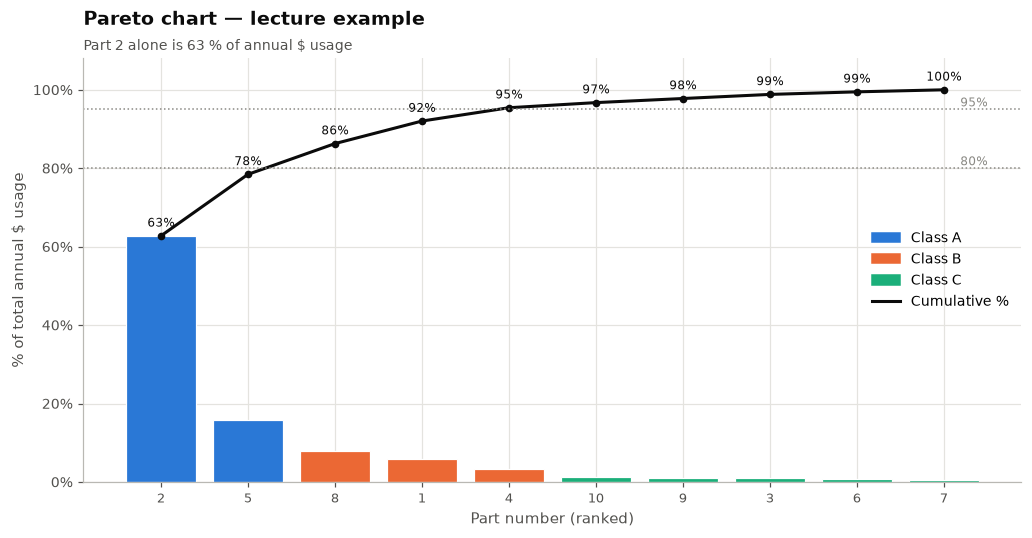

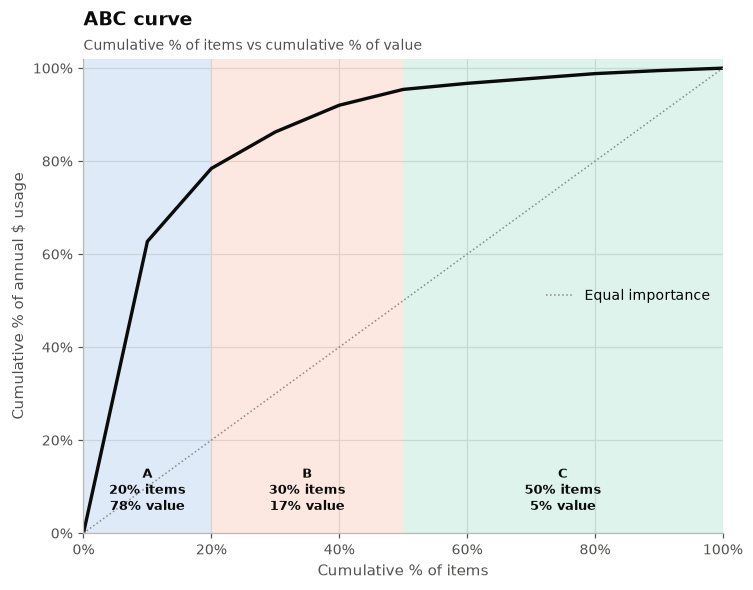

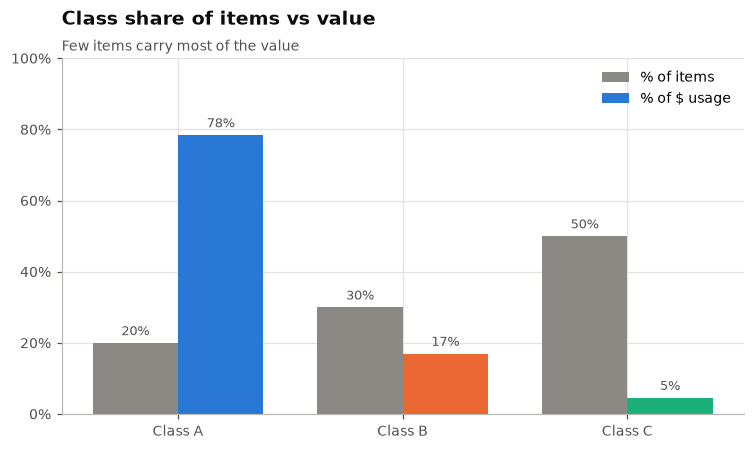

*Class summary (items rule).*

,class,items,value,pct_items,pct_value
0,A,2,"$30,000",20%,78.4%
1,B,3,"$6,500",30%,17.0%
2,C,5,"$1,750",50%,4.6%


📄 **PDF report exported:** `reports\P4_1_abc_lecture_example.pdf`

In [22]:
def run_abc_lecture(df=None):
    df = pd.read_csv(DATA / "abc_lecture_example.csv") if df is None else df.copy()
    sec = Section("P4_1_abc_lecture_example", "ABC analysis — lecture example (10 part numbers)",
                  part="Part 4 · How do we begin?")
    df["annual_dollar_usage"] = df.annual_unit_usage * df.unit_cost
    sec.heading("Step 1 — annual dollar usage")
    sec.table(df, "Annual usage analysis (slide 32).", formats={"part_number": "d", "annual_unit_usage": ",d",
                                                                "unit_cost": "$,.0f", "annual_dollar_usage": "$,.0f"})
    sec.metrics({"Total annual $ usage": f"${df.annual_dollar_usage.sum():,.0f}", "Number of parts": f"{len(df)}"})
    d_items = abc_classify(df, method="items")
    d_value = abc_classify(df, method="value")
    sec.heading("Step 2 — rank, cumulate and classify")
    t = d_items[["part_number", "annual_dollar_usage", "cum_value", "cum_pct_value", "cum_pct_items", "class"]].copy()
    t["class_by_value_80_95"] = d_value["class"].values
    sec.table(t, "Ranking by annual $ usage (slide 34) with classes from both cut-off rules.",
              formats={"part_number": "d", "annual_dollar_usage": "$,.0f", "cum_value": "$,.0f",
                       "cum_pct_value": ".1%", "cum_pct_items": ".0%"})
    s_items = abc_summary(d_items)
    sec.text("With the **items rule (20 % / 30 % / 50 %)** parts 2 and 5 are A, parts 8, 1, 4 are B and the rest C — "
             f"A holds **{100*s_items.pct_value[0]:.0f} %** of the value with 20 % of the items, exactly the Pareto pattern "
             "on slide 30. With **strict value cut-offs (80 % / 95 %)** part 4 (cumulative 95.4 %) falls just into C: "
             "items at a boundary are a **judgement call** — managers often promote them for other reasons "
             "(criticality, scarcity).")
    fig = plot_pareto(d_items, "annual_dollar_usage", "Pareto chart — lecture example",
                      "Part 2 alone is 63 % of annual $ usage", label_col="part_number")
    ax = fig.axes[0]; ax.set_xlabel("Part number (ranked)")
    sec.figure(fig, "Bars = % of annual $ usage per part (coloured by class); line = cumulative %.")
    sec.figure(plot_abc_curve(d_items, "ABC curve", "Cumulative % of items vs cumulative % of value"),
               "ABC (Lorenz) curve with class bands.", width=0.72)
    sec.figure(plot_class_bars(s_items, "Class share of items vs value"), "Share of items and value by class.", width=0.75)
    sec.table(s_items, "Class summary (items rule).", formats={"value": "$,.0f", "pct_items": ".0%", "pct_value": ".1%"})
    return sec, d_items

sec_abc1, abc1 = run_abc_lecture()
export_section(sec_abc1);

## 4.2 A realistic case — 200 SKUs (slide 28)

**Input file:** `data/abc_200_skus.csv` — SKU, category, annual unit usage, unit cost, lead time, scarcity score (1–5), quality incidents per year, number of qualified suppliers.

Classification rule: cumulative % of value — A ≤ **80%**, B ≤ **95%**, C = rest.

,Value
Key result,
Total annual $ usage,"$1,832,644"
Class A,45 items (22%) → 79.8% of value
Class B,64 items (32%) → 15.1% of value
Class C,91 items (46%) → 5.1% of value
Top SKU,SKU-0172 = 19.4% of value
Concentration (Gini),0.75


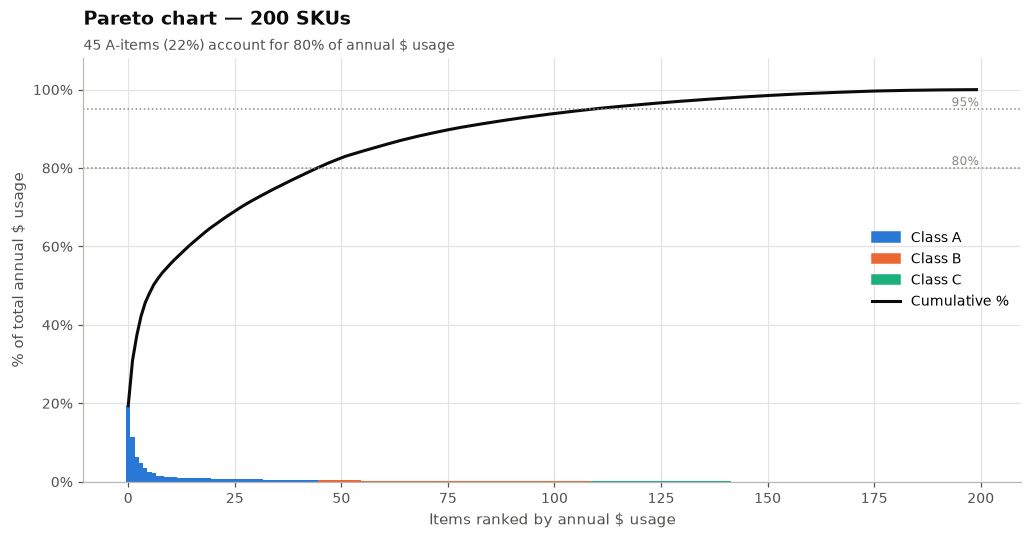

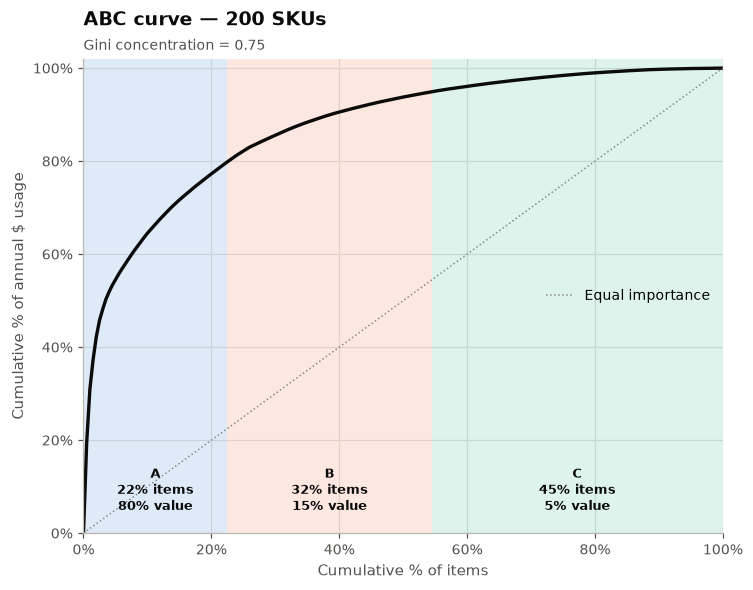

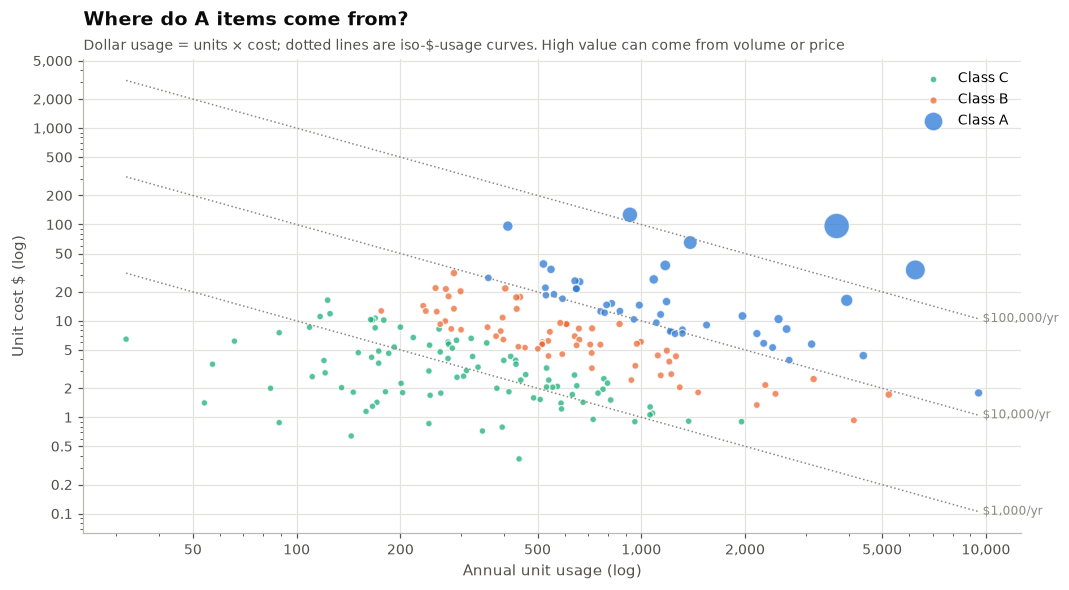

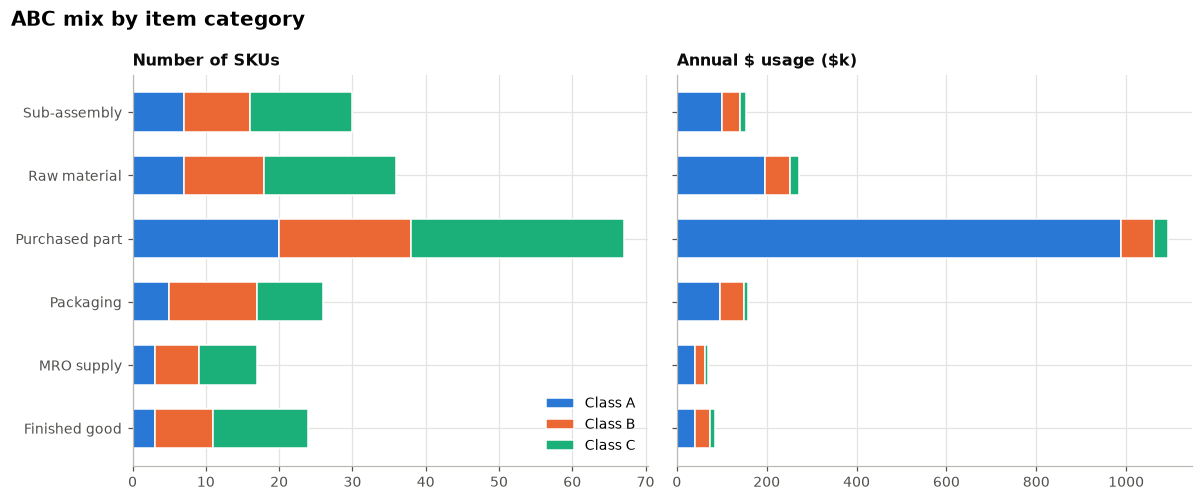

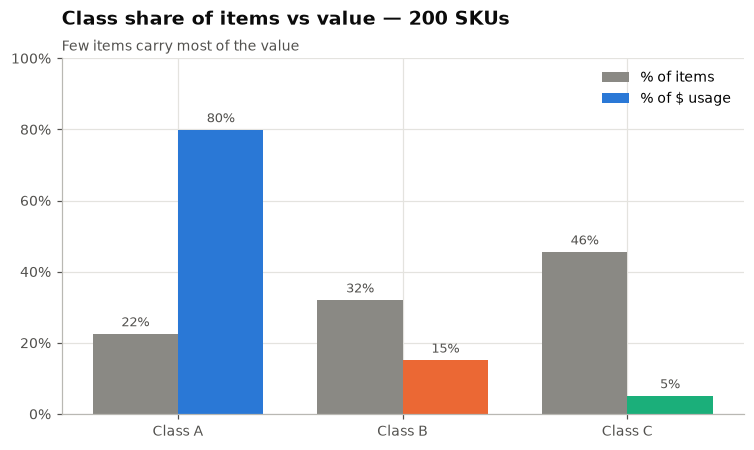

*Class summary.*

,class,items,value,pct_items,pct_value
0,A,45,"$1,463,320",22.5%,79.8%
1,B,64,"$276,463",32.0%,15.1%
2,C,91,"$92,861",45.5%,5.1%


*Ranked SKU list (first 40 rows; full list in reports/tables).*

,rank,sku,category,annual_unit_usage,unit_cost,annual_dollar_usage,pct_of_value,cum_pct_value,cum_pct_items,class
0,1,SKU-0172,Purchased part,"3,689",$96.42,"$355,693",19.41%,19.4%,0.5%,A
1,2,SKU-0052,Purchased part,"6,240",$33.75,"$210,600",11.49%,30.9%,1.0%,A
2,3,SKU-0123,Purchased part,927,$126.14,"$116,932",6.38%,37.3%,1.5%,A
3,4,SKU-0176,Raw material,"1,387",$64.94,"$90,072",4.91%,42.2%,2.0%,A
4,5,SKU-0046,Purchased part,"3,946",$16.34,"$64,478",3.52%,45.7%,2.5%,A
5,6,SKU-0024,Raw material,"1,174",$37.61,"$44,154",2.41%,48.1%,3.0%,A
6,7,SKU-0041,Packaging,410,$96.15,"$39,422",2.15%,50.3%,3.5%,A
7,8,SKU-0019,Purchased part,"1,087",$26.94,"$29,284",1.60%,51.9%,4.0%,A
8,9,SKU-0043,Purchased part,"2,502",$10.44,"$26,121",1.43%,53.3%,4.5%,A
9,10,SKU-0192,Sub-assembly,"1,966",$11.24,"$22,098",1.21%,54.5%,5.0%,A


📄 **PDF report exported:** `reports\P4_2_abc_200_skus.pdf`

In [23]:
def run_abc_200(df=None, method="value", cut_value=None):
    df = pd.read_csv(DATA / "abc_200_skus.csv") if df is None else df.copy()
    cut_value = cut_value or (PARAMS["abc_thresholds"]["A"], PARAMS["abc_thresholds"]["B"])
    sec = Section("P4_2_abc_200_skus", "ABC classification of 200 SKUs", part="Part 4 · How do we begin?")
    df["annual_dollar_usage"] = df.annual_unit_usage * df.unit_cost
    d = abc_classify(df, method=method, cut_value=cut_value)
    s = abc_summary(d)
    gini = 2 * TRAPZ(np.r_[0, d.cum_pct_value], np.r_[0, d.cum_pct_items]) - 1
    sec.text(f"Classification rule: cumulative % of value — A ≤ **{cut_value[0]:.0%}**, B ≤ **{cut_value[1]:.0%}**, C = rest.")
    sec.metrics({"Total annual $ usage": f"${d.annual_dollar_usage.sum():,.0f}",
                 **{f"Class {r['class']}": f"{r['items']} items ({r.pct_items:.0%}) → {r.pct_value:.1%} of value"
                    for _, r in s.iterrows()},
                 "Top SKU": f"{d.sku[0]} = {d.pct_of_value[0]:.1%} of value",
                 "Concentration (Gini)": f"{gini:.2f}"})
    sec.figure(plot_pareto(d, "annual_dollar_usage", "Pareto chart — 200 SKUs",
                           f"{s['items'][0]} A-items ({s.pct_items[0]:.0%}) account for {s.pct_value[0]:.0%} of annual $ usage"),
               "Pareto chart of all 200 SKUs coloured by class.")
    sec.figure(plot_abc_curve(d, "ABC curve — 200 SKUs", f"Gini concentration = {gini:.2f}"),
               "ABC (Lorenz) curve.", width=0.72)

    fig, ax = plt.subplots(figsize=(11, 5.6))
    for k in "CBA":
        m = d[d["class"] == k]
        ax.scatter(m.annual_unit_usage, m.unit_cost, s=18 + 260 * m.pct_of_value / d.pct_of_value.max(),
                   color=ABC_COLORS[k], alpha=0.75, edgecolor=SURF, linewidth=0.8, label=f"Class {k}")
    logscale(ax, "x"); logscale(ax, "y")
    xs = np.logspace(np.log10(d.annual_unit_usage.min()), np.log10(d.annual_unit_usage.max()), 50)
    for v in [1e3, 1e4, 1e5]:
        ax.plot(xs, v / xs, color=MUTED, ls=":", lw=1)
        ax.text(xs[-1], v / xs[-1], f" ${v:,.0f}/yr", fontsize=8, color=MUTED, va="center")
    ax.set_xlabel("Annual unit usage (log)"); ax.set_ylabel("Unit cost $ (log)"); ax.legend(loc="upper right")
    style_title(ax, "Where do A items come from?",
                "Dollar usage = units × cost; dotted lines are iso-$-usage curves. High value can come from volume or price")
    sec.figure(fig, "Each bubble is a SKU; bubble area ∝ annual $ usage.")

    ct = pd.crosstab(d.category, d["class"]).reindex(columns=list("ABC"), fill_value=0)
    cv = d.pivot_table(index="category", columns="class", values="annual_dollar_usage", aggfunc="sum").reindex(
        columns=list("ABC")).fillna(0)
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
    for ax, M, ttl, fmt in [(axs[0], ct, "Number of SKUs", "{:,.0f}"), (axs[1], cv / 1e3, "Annual $ usage ($k)", "{:,.0f}")]:
        left = np.zeros(len(M))
        for k in "ABC":
            ax.barh(M.index, M[k], left=left, color=ABC_COLORS[k], edgecolor=SURF, height=0.62, label=f"Class {k}")
            left += M[k].values
        ax.set_title(ttl, fontsize=10.5)
    axs[0].legend(loc="lower right")
    fig.suptitle("ABC mix by item category", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Count and value of SKUs by category and class.")
    sec.figure(plot_class_bars(s, "Class share of items vs value — 200 SKUs"), "Class summary.", width=0.75)
    sec.table(s, "Class summary.", formats={"value": "$,.0f", "pct_items": ".1%", "pct_value": ".1%"})
    sec.table(d[["rank", "sku", "category", "annual_unit_usage", "unit_cost", "annual_dollar_usage", "pct_of_value",
                 "cum_pct_value", "cum_pct_items", "class"]],
              "Ranked SKU list (first 40 rows; full list in reports/tables).", max_rows=40,
              formats={"rank": "d", "annual_unit_usage": ",d", "unit_cost": "$,.2f", "annual_dollar_usage": "$,.0f",
                       "pct_of_value": ".2%", "cum_pct_value": ".1%", "cum_pct_items": ".1%"})
    return sec, d

sec_abc2, abc2 = run_abc_200()
export_section(sec_abc2);

## 4.3 Multi-criteria ABC (slide 31)

The ABC *process* starts by establishing the item characteristics that influence results — **annual dollar usage, scarcity of material, quality problems**. A simple weighted-score approach:

$$\text{score}_i = w_1\,\text{rank\%}(\$\text{usage}_i) + w_2\,\frac{\text{scarcity}_i-1}{4} + w_3\,\text{rank\%}(\text{quality incidents}_i)$$

Items are then ranked by score and split 20 / 30 / 50 %. Weights are in `scenario_parameters.json → abc_multicriteria_weights`.

Weights: dollar usage **0.6**, scarcity **0.25**, quality **0.15**. Both classifications use the 20/30/50 % items rule so that they are comparable.

,Value
Key result,
Items keeping their class,154 (77%)
Items upgraded,23
Items downgraded,23
C → A upgrades,0


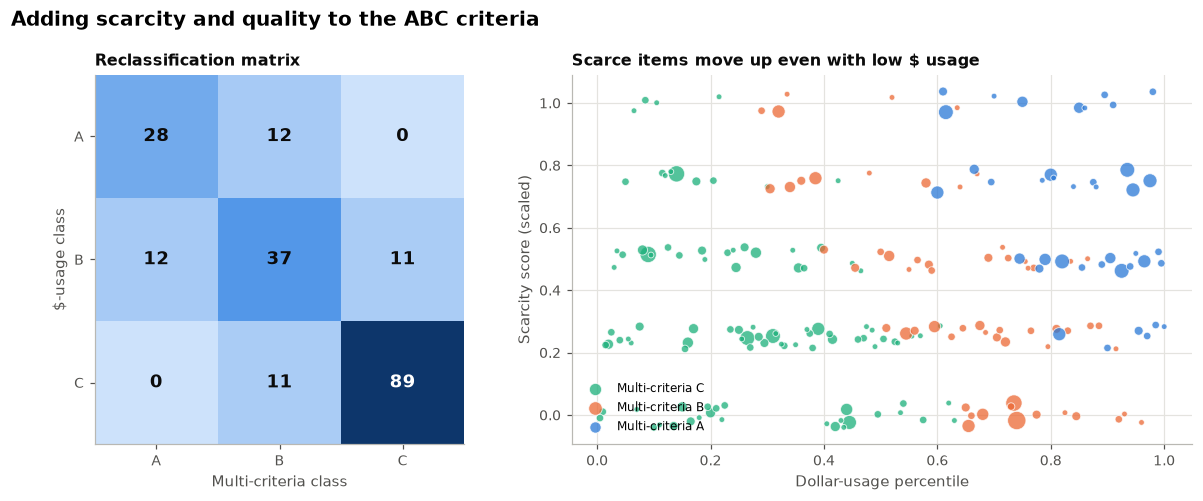

*Largest upgrades (items that deserve more control than $ usage alone suggests).*

,sku,category,annual_dollar_usage,scarcity_score_1to5,quality_incidents_per_year,score,class_dollar,class_multi
0,SKU-0167,Finished good,"$7,876",5,4,0.828,B,A
1,SKU-0155,Packaging,"$9,548",4,6,0.805,B,A
2,SKU-0034,Sub-assembly,"$3,821",5,8,0.764,B,A
3,SKU-0186,Sub-assembly,"$9,489",3,5,0.731,B,A
4,SKU-0175,Finished good,"$3,621",5,2,0.721,B,A
5,SKU-0070,Purchased part,"$4,892",4,3,0.706,B,A
6,SKU-0086,Sub-assembly,"$7,617",3,4,0.700,B,A
7,SKU-0017,Purchased part,"$9,184",3,2,0.698,B,A
8,SKU-0126,Raw material,"$5,618",5,0,0.695,B,A
9,SKU-0023,Packaging,"$3,339",4,6,0.685,B,A


*Reclassification matrix.*

class_multi,$-usage class \ multi-criteria class,A,B,C
0,A,28,12,0
1,B,12,37,11
2,C,0,11,89


📄 **PDF report exported:** `reports\P4_3_abc_multicriteria.pdf`

In [24]:
def run_abc_multicriteria(d=None, w=None):
    d = abc2.copy() if d is None else d.copy()
    w = w or PARAMS["abc_multicriteria_weights"]
    sec = Section("P4_3_abc_multicriteria", "Multi-criteria ABC: dollar usage, scarcity and quality problems",
                  part="Part 4 · How do we begin?")
    d = abc_classify(d.drop(columns=["class"]), method="items").rename(columns={"class": "class_dollar"})
    d["s_dollar"] = d.annual_dollar_usage.rank(pct=True)
    d["s_scarcity"] = (d.scarcity_score_1to5 - 1) / 4
    d["s_quality"] = d.quality_incidents_per_year.rank(pct=True, method="average")
    d["score"] = w["dollar_usage"] * d.s_dollar + w["scarcity"] * d.s_scarcity + w["quality"] * d.s_quality
    d = d.sort_values("score", ascending=False).reset_index(drop=True)
    n = len(d)
    d["class_multi"] = np.where(np.arange(1, n + 1) <= 0.2 * n, "A", np.where(np.arange(1, n + 1) <= 0.5 * n, "B", "C"))
    cm = pd.crosstab(d.class_dollar, d.class_multi).reindex(index=list("ABC"), columns=list("ABC"), fill_value=0)
    moved = d[d.class_dollar != d.class_multi]
    up = moved[moved.class_multi < moved.class_dollar]
    sec.text(f"Weights: dollar usage **{w['dollar_usage']}**, scarcity **{w['scarcity']}**, quality **{w['quality']}**. "
             "Both classifications use the 20/30/50 % items rule so that they are comparable.")
    sec.metrics({"Items keeping their class": f"{n - len(moved)} ({(n-len(moved))/n:.0%})",
                 "Items upgraded": f"{len(up)}", "Items downgraded": f"{len(moved) - len(up)}",
                 "C → A upgrades": f"{int(cm.loc['C', 'A'])}"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
    ax = axs[0]
    im = ax.imshow(cm.values, cmap=SEQ_CMAP); ax.grid(False)
    ax.set_xticks(range(3)); ax.set_xticklabels([f"{k}" for k in "ABC"]); ax.set_yticks(range(3))
    ax.set_yticklabels([f"{k}" for k in "ABC"])
    ax.set_xlabel("Multi-criteria class"); ax.set_ylabel("$-usage class")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm.values[i, j], ha="center", va="center", fontsize=12, fontweight="bold",
                    color="white" if cm.values[i, j] > cm.values.max() * 0.55 else INK)
    ax.set_title("Reclassification matrix", fontsize=10.5)
    ax = axs[1]
    for k in "CBA":
        m = d[d.class_multi == k]
        ax.scatter(m.s_dollar, m.s_scarcity + np.random.default_rng(1).uniform(-0.04, 0.04, len(m)),
                   s=14 + 10 * m.quality_incidents_per_year, color=ABC_COLORS[k], alpha=0.75, edgecolor=SURF,
                   linewidth=0.6, label=f"Multi-criteria {k}")
    ax.set_xlabel("Dollar-usage percentile"); ax.set_ylabel("Scarcity score (scaled)"); ax.legend(loc="lower left", fontsize=8)
    ax.set_title("Scarce items move up even with low $ usage", fontsize=10.5)
    fig.suptitle("Adding scarcity and quality to the ABC criteria", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Left: counts moving between classes. Right: bubble size ∝ quality incidents.")
    top_moves = up.sort_values("score", ascending=False).head(15)
    sec.table(top_moves[["sku", "category", "annual_dollar_usage", "scarcity_score_1to5", "quality_incidents_per_year",
                         "score", "class_dollar", "class_multi"]],
              "Largest upgrades (items that deserve more control than $ usage alone suggests).",
              formats={"annual_dollar_usage": "$,.0f", "scarcity_score_1to5": "d", "quality_incidents_per_year": "d",
                       "score": ".3f"})
    sec.table(cm.reset_index().rename(columns={"class_dollar": "$-usage class \\ multi-criteria class"}),
              "Reclassification matrix.")
    return sec, d

sec_abc3, abc3 = run_abc_multicriteria()
export_section(sec_abc3);

## 4.4 Control based on ABC classification (slide 35)

Two general rules: **have plenty of low-value items** and **focus control effort on A items**. The table and chart translate the classes of the 200-SKU case into a control policy.

*Recommended control policy by class.*

,class,level_of_control,review,records,safety_stock_and_lot_size,who_manages
0,A,Tight,Continuous / weekly,"Perpetual, audited, cycle-counted monthly","Low SS, small frequent lots, close follow-up",Senior planner
1,B,Normal,Bi-weekly to monthly,"Perpetual, counted quarterly",Moderate,Planner
2,C,Least possible,Quarterly or two-bin,"Simple, counted yearly","Generous SS, large infrequent lots",Clerk / automatic


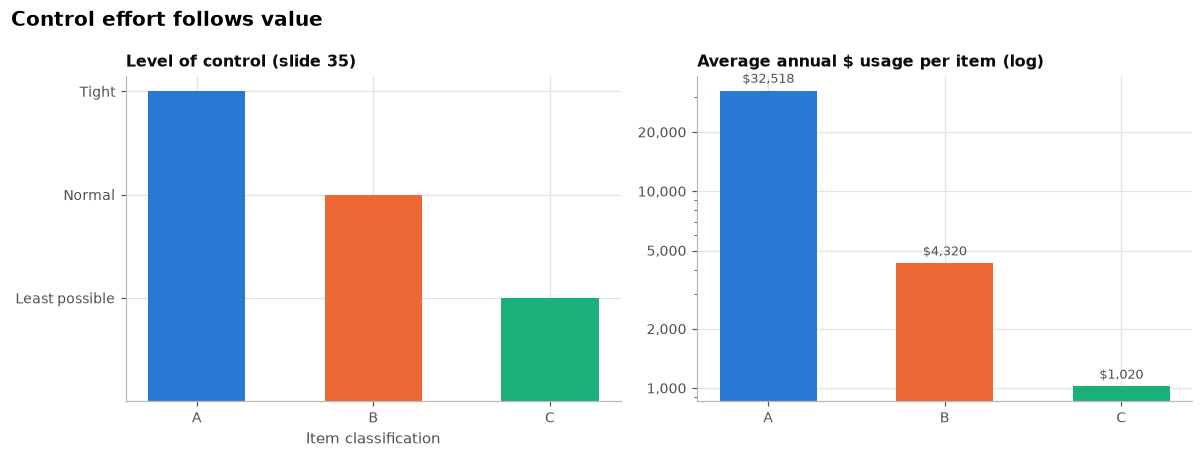

An A item is on average **32×** more valuable per year than a C item — a stock-out of a C item is an inconvenience that is cheaply prevented by holding more of it.

📄 **PDF report exported:** `reports\P4_4_abc_control_policy.pdf`

In [25]:
def run_abc_control(d=None):
    d = abc2 if d is None else d
    sec = Section("P4_4_abc_control_policy", "Control policies by ABC class", part="Part 4 · How do we begin?")
    policy = pd.DataFrame({
        "class": ["A", "B", "C"],
        "level_of_control": ["Tight", "Normal", "Least possible"],
        "review": ["Continuous / weekly", "Bi-weekly to monthly", "Quarterly or two-bin"],
        "records": ["Perpetual, audited, cycle-counted monthly", "Perpetual, counted quarterly", "Simple, counted yearly"],
        "safety_stock_and_lot_size": ["Low SS, small frequent lots, close follow-up", "Moderate",
                                       "Generous SS, large infrequent lots"],
        "who_manages": ["Senior planner", "Planner", "Clerk / automatic"]})
    s = abc_summary(d)
    s["avg_value_per_item"] = s.value / s["items"]
    sec.table(policy, "Recommended control policy by class.")
    control = {"A": 3, "B": 2, "C": 1}
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
    b = axs[0].bar(list("ABC"), [control[k] for k in "ABC"], color=[ABC_COLORS[k] for k in "ABC"], width=0.55)
    axs[0].set_yticks([1, 2, 3]); axs[0].set_yticklabels(["Least possible", "Normal", "Tight"])
    axs[0].set_xlabel("Item classification"); axs[0].set_title("Level of control (slide 35)", fontsize=10.5)
    b = axs[1].bar(list("ABC"), s.avg_value_per_item, color=[ABC_COLORS[k] for k in "ABC"], width=0.55)
    label_bars(axs[1], b, "${:,.0f}"); logscale(axs[1], "y")
    axs[1].set_title("Average annual $ usage per item (log)", fontsize=10.5)
    fig.suptitle("Control effort follows value", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Control level and value per item by class.")
    sec.text(f"An A item is on average **{s.avg_value_per_item[0]/s.avg_value_per_item[2]:,.0f}×** more valuable per year than "
             "a C item — a stock-out of a C item is an inconvenience that is cheaply prevented by holding more of it.")
    return sec, policy

sec_abc4, abc_policy = run_abc_control()
export_section(sec_abc4);

---
# Part 5 — How do we evaluate inventory performance? (slides 36–40)

| Measure | Definition | Notes |
|---|---|---|
| **\$ value of inventory** | Σ raw materials + work in process + finished goods | Balance-sheet *snapshot* at period end |
| **Inventory turnover (turns)** | $\dfrac{\text{Annual sales or usage (at cost) = COGS}}{\text{Average inventory (\$)}}$ | 6–7 typical; high-tech ≈ 3; automotive up to 40 for selected products |
| **Days of supply** | $\dfrac{\text{Inventory on hand}}{\text{Average daily usage}}$ | Turns ≈ working days per year ÷ days of supply |

Lecture examples: COGS \$1,000,000 and average inventory \$500,000 → **2 turns**; 6,000 units on hand at 200 units/day → **30 days of supply** → inventory turns every 30 days, **12 times a year**.

#### Lecture worked examples

$$\text{Turns}=\frac{1{,}000{,}000}{500{,}000}=2,\qquad \text{DoS}=\frac{6000}{200}=30\text{ days}\Rightarrow\frac{360}{30}=12\text{ turns}$$

,Value
Key result,
Turns (COGS example),2
Days of supply (unit example),30 days
Equivalent turns,12 per year


#### Division benchmark

Average inventory is the mean of the opening and four quarter-end balances (a better estimate than a single year-end snapshot, which can be window-dressed).

,Value
Key result,
Company-wide turns,6.05
Company-wide days of supply,60 days
Best division,Automotive Components (36.0 turns)
Worst vs benchmark,Automotive Components (-4.0)
Total $ inventory (Q4),$42.4 M
Carrying-cost gap vs benchmarks,$0.93 M/yr


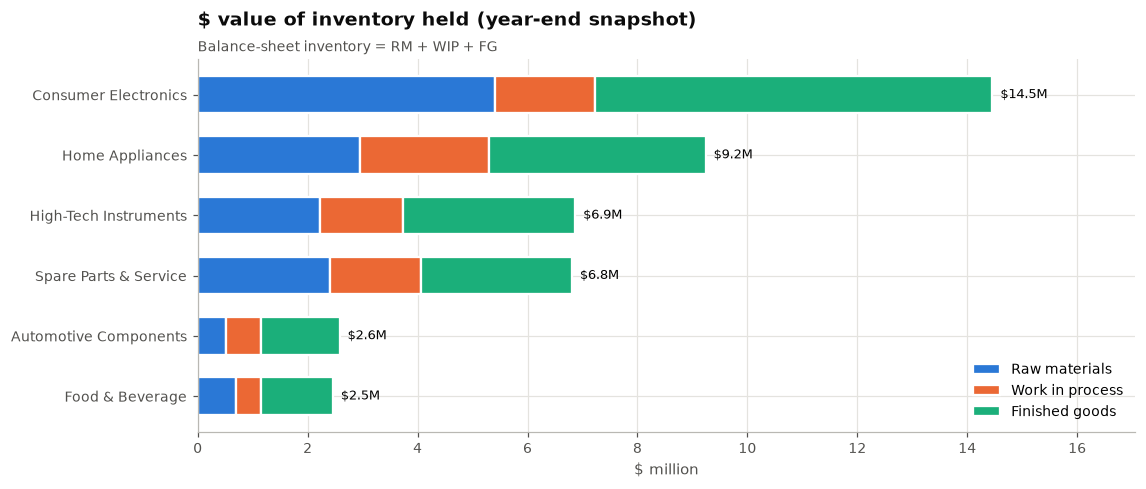

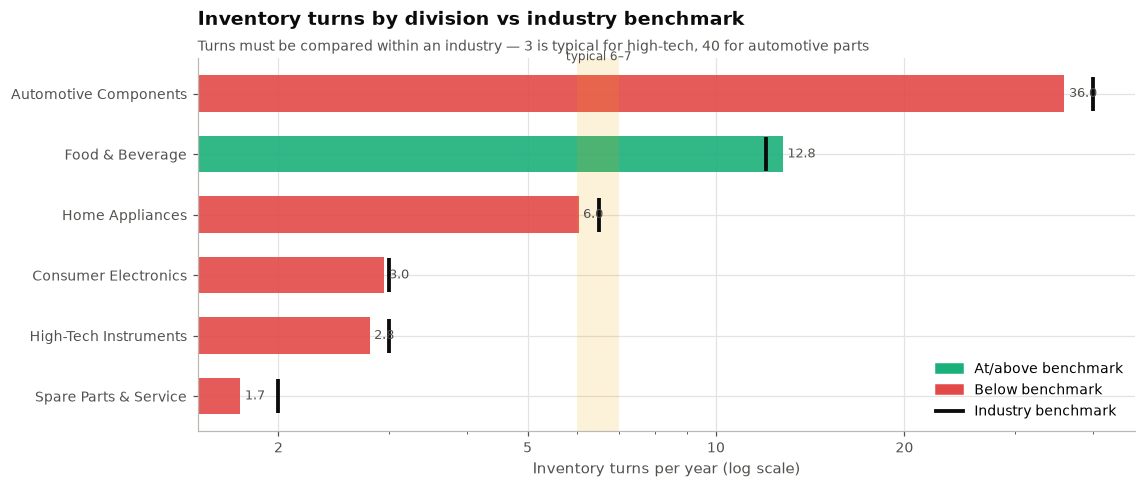

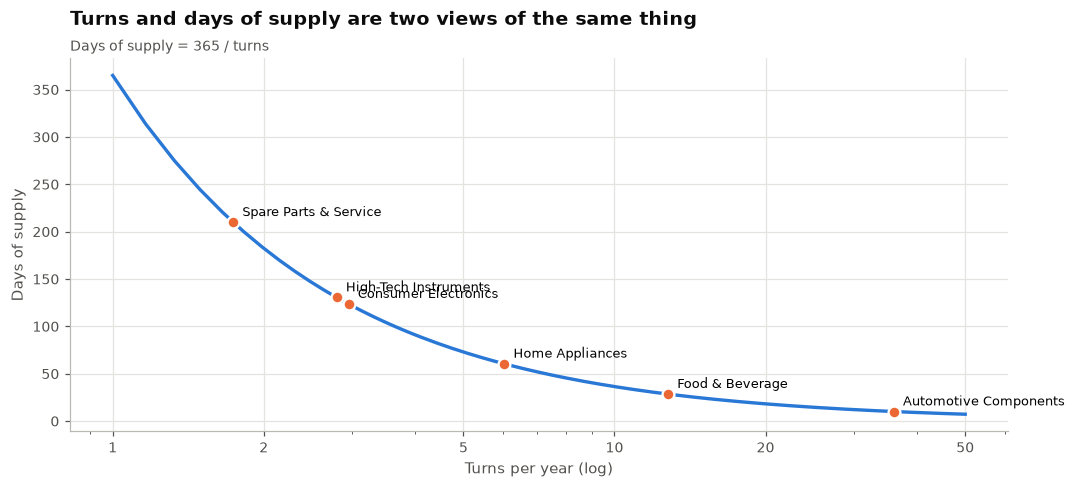

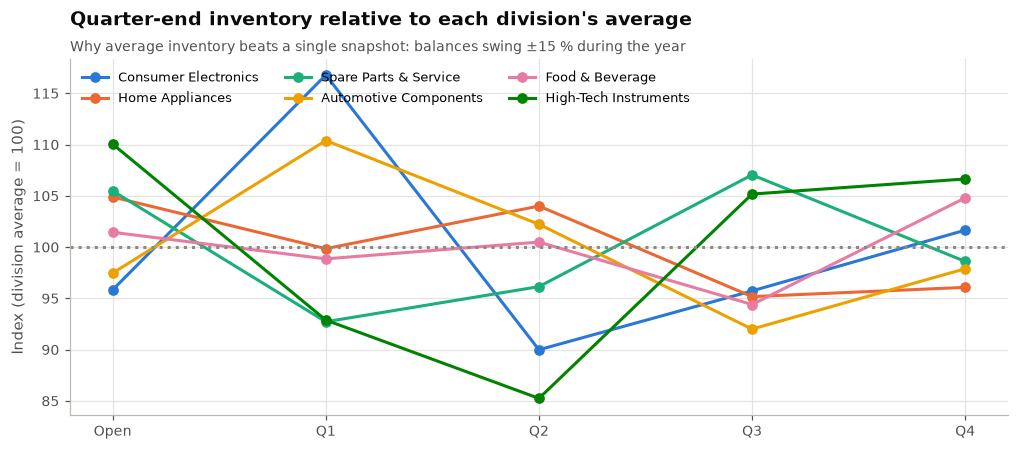

*Division turnover analysis.*

,division,annual_cogs,avg_inventory,year_end_inventory,turns,turns_on_year_end,days_of_supply,industry_benchmark_turns,turns_gap_vs_benchmark,excess_carrying_cost
0,Consumer Electronics,"$42,000,000","$14,222,563","$14,457,599",2.95,2.91,124,3.0,-0.05,"$82,348"
1,Home Appliances,"$58,000,000","$9,617,652","$9,240,231",6.03,6.28,61,6.5,-0.47,"$256,993"
2,Spare Parts & Service,"$12,000,000","$6,904,519","$6,808,137",1.74,1.76,210,2.0,-0.26,"$334,672"
3,Automotive Components,"$95,000,000","$2,636,740","$2,581,215",36.03,36.80,10,40.0,-3.97,"$96,844"
4,Food & Beverage,"$30,000,000","$2,346,218","$2,458,859",12.79,12.20,29,12.0,+0.79,"-$56,899"
5,High-Tech Instruments,"$18,000,000","$6,439,082","$6,867,108",2.80,2.62,131,3.0,-0.20,"$162,460"


#### Item-level days of supply

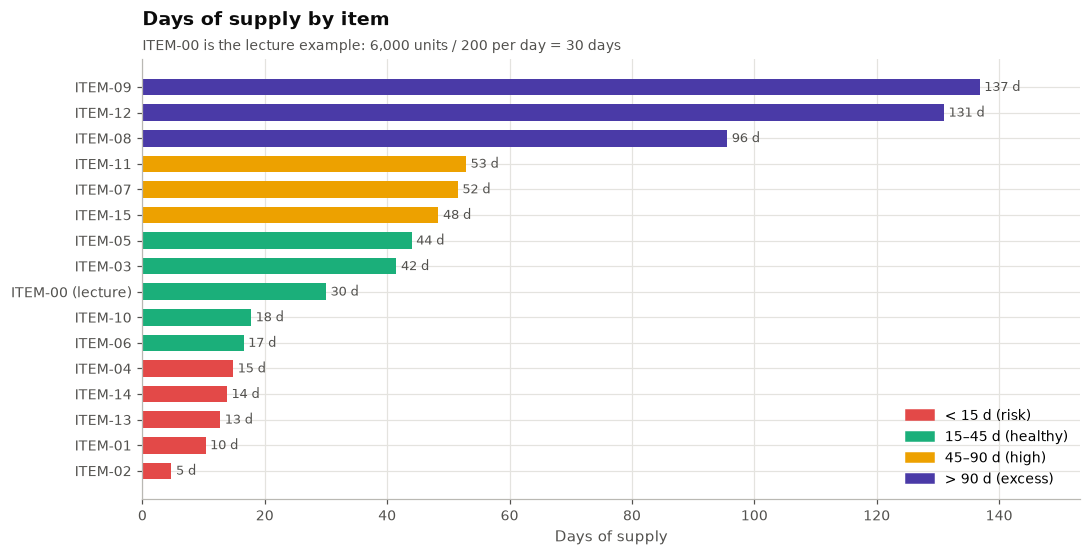

*Item days of supply and equivalent turns.*

,item,inventory_on_hand_units,avg_daily_usage_units,unit_cost,days_of_supply,turns_equiv,inventory_value,band
0,ITEM-00 (lecture),"6,000",200,$12.00,30.0,12.0,"$72,000",15–45 d (healthy)
1,ITEM-01,"3,735",362,$2.31,10.3,34.9,"$8,628",< 15 d (risk)
2,ITEM-02,"1,343",283,$4.28,4.7,75.9,"$5,748",< 15 d (risk)
3,ITEM-03,"15,651",377,$4.74,41.5,8.7,"$74,186",15–45 d (healthy)
4,ITEM-04,593,40,$10.63,14.8,24.3,"$6,304",< 15 d (risk)
5,ITEM-05,"11,396",259,$4.93,44.0,8.2,"$56,182",15–45 d (healthy)
6,ITEM-06,"2,662",161,$4.54,16.5,21.8,"$12,085",15–45 d (healthy)
7,ITEM-07,"7,834",152,$8.66,51.5,7.0,"$67,842",45–90 d (high)
8,ITEM-08,"13,666",143,$5.94,95.6,3.8,"$81,176",> 90 d (excess)
9,ITEM-09,"30,101",220,$13.52,136.8,2.6,"$406,966",> 90 d (excess)


📄 **PDF report exported:** `reports\P5_performance_measures.pdf`

In [26]:
def turns(cogs, avg_inv):
    return cogs / avg_inv

def days_of_supply(on_hand, daily_usage):
    return on_hand / daily_usage

def run_performance(div=None, items=None, days_per_year=360):
    div = pd.read_csv(DATA / "inventory_turns_divisions.csv") if div is None else div.copy()
    items = pd.read_csv(DATA / "days_of_supply_items.csv") if items is None else items.copy()
    sec = Section("P5_performance_measures", "Inventory performance: $ value, turns and days of supply",
                  part="Part 5 · Evaluating performance")
    sec.heading("Lecture worked examples")
    t_ex = turns(1_000_000, 500_000); dos_ex = days_of_supply(6000, 200)
    sec.equation("Turns = 1,000,000 / 500,000 = 2        Days of supply = 6,000 / 200 = 30 days → 360/30 = 12 turns",
                 r"\text{Turns}=\frac{1{,}000{,}000}{500{,}000}=2,\qquad \text{DoS}=\frac{6000}{200}=30\text{ days}\Rightarrow\frac{360}{30}=12\text{ turns}")
    sec.metrics({"Turns (COGS example)": f"{t_ex:.0f}", "Days of supply (unit example)": f"{dos_ex:.0f} days",
                 "Equivalent turns": f"{days_per_year/dos_ex:.0f} per year"})

    sec.heading("Division benchmark")
    qcols = ["inv_open", "inv_q1", "inv_q2", "inv_q3", "inv_q4"]
    div["avg_inventory"] = div[qcols].mean(axis=1)
    div["year_end_inventory"] = div.inv_q4
    div["turns"] = turns(div.annual_cogs, div.avg_inventory)
    div["turns_on_year_end"] = turns(div.annual_cogs, div.year_end_inventory)
    div["days_of_supply"] = 365 / div.turns
    div["turns_gap_vs_benchmark"] = div.turns - div.industry_benchmark_turns
    div["excess_inventory_vs_benchmark"] = div.avg_inventory - div.annual_cogs / div.industry_benchmark_turns
    div["excess_carrying_cost"] = div.excess_inventory_vs_benchmark * PARAMS["holding_cost_rate"]
    tot_turns = div.annual_cogs.sum() / div.avg_inventory.sum()
    sec.text("Average inventory is the mean of the opening and four quarter-end balances (a better estimate than a "
             "single year-end snapshot, which can be window-dressed).")
    sec.metrics({"Company-wide turns": f"{tot_turns:.2f}", "Company-wide days of supply": f"{365/tot_turns:.0f} days",
                 "Best division": f"{div.loc[div.turns.idxmax(), 'division']} ({div.turns.max():.1f} turns)",
                 "Worst vs benchmark": f"{div.loc[div.turns_gap_vs_benchmark.idxmin(), 'division']} "
                                       f"({div.turns_gap_vs_benchmark.min():+.1f})",
                 "Total $ inventory (Q4)": f"${div.inv_q4.sum()/1e6:,.1f} M",
                 "Carrying-cost gap vs benchmarks": f"${div.excess_carrying_cost.clip(lower=0).sum()/1e6:,.2f} M/yr"})

    # balance-sheet snapshot
    snap = div[["division"]].copy()
    for k in ["raw_material_pct", "wip_pct", "finished_goods_pct"]:
        snap[k.replace("_pct", "")] = div.inv_q4 * div[k] / 100
    fig, ax = plt.subplots(figsize=(11, 4.4))
    left = np.zeros(len(snap)); order = snap.set_index("division").sum(1).sort_values().index
    sn = snap.set_index("division").loc[order]
    for k, colr, lab in [("raw_material", C["blue"], "Raw materials"), ("wip", C["orange"], "Work in process"),
                         ("finished_goods", C["aqua"], "Finished goods")]:
        ax.barh(sn.index, sn[k] / 1e6, left=left, color=colr, edgecolor=SURF, linewidth=1.5, height=0.62, label=lab)
        left += sn[k].values / 1e6
    for yi, v in enumerate(left):
        ax.text(v, yi, f"  ${v:,.1f}M", va="center", fontsize=8.5)
    ax.set_xlabel("$ million"); ax.legend(loc="lower right"); ax.set_xlim(0, left.max() * 1.18)
    style_title(ax, "$ value of inventory held (year-end snapshot)", "Balance-sheet inventory = RM + WIP + FG")
    sec.figure(fig, "Year-end inventory by division and stage.")

    fig, ax = plt.subplots(figsize=(11, 4.4))
    dd = div.sort_values("turns")
    b = ax.barh(dd.division, dd.turns, color=np.where(dd.turns >= dd.industry_benchmark_turns, C["aqua"], C["red"]),
                height=0.6, alpha=0.9)
    ax.scatter(dd.industry_benchmark_turns, dd.division, marker="|", s=500, color=INK, linewidths=2.5,
               label="Industry benchmark", zorder=3)
    label_bars(ax, b, "{:.1f}", horizontal=True)
    ax.axvspan(6, 7, color=C["yellow"], alpha=0.15, lw=0); ax.text(6.5, len(dd) - 0.45, "typical 6–7", ha="center",
                                                                   fontsize=8, color=INK2)
    logscale(ax, "x"); ax.set_xlabel("Inventory turns per year (log scale)"); ax.legend(loc="lower right")
    handles = [Patch(color=C["aqua"], label="At/above benchmark"), Patch(color=C["red"], label="Below benchmark"),
               Line2D([0], [0], color=INK, lw=2.5, label="Industry benchmark")]
    ax.legend(handles=handles, loc="lower right")
    style_title(ax, "Inventory turns by division vs industry benchmark",
                "Turns must be compared within an industry — 3 is typical for high-tech, 40 for automotive parts")
    sec.figure(fig, "Turns = annual COGS / average inventory.")

    fig, ax = plt.subplots(figsize=(11, 4.4))
    tt = np.linspace(1, 50, 300)
    ax.plot(tt, 365 / tt, color=C["blue"], lw=2.2)
    for _, r in div.iterrows():
        ax.scatter(r.turns, r.days_of_supply, s=60, color=C["orange"], edgecolor=SURF, linewidth=1.5, zorder=3)
        ax.annotate(r.division, (r.turns, r.days_of_supply), xytext=(6, 4), textcoords="offset points", fontsize=8.3)
    logscale(ax, "x"); ax.set_xlabel("Turns per year (log)"); ax.set_ylabel("Days of supply")
    style_title(ax, "Turns and days of supply are two views of the same thing", "Days of supply = 365 / turns")
    sec.figure(fig, "The hyperbola links turns and days of supply.")

    fig, ax = plt.subplots(figsize=(11, 4.2))
    q = div.set_index("division")[qcols]
    qi = q.div(q.mean(axis=1), axis=0) * 100
    for (name, row), colr in zip(qi.iterrows(), SERIES):
        ax.plot(["Open", "Q1", "Q2", "Q3", "Q4"], row.values, marker="o", color=colr, label=name)
    ax.axhline(100, color=MUTED, ls=":"); ax.set_ylabel("Index (division average = 100)")
    ax.legend(ncol=3, fontsize=8.5, loc="upper left")
    style_title(ax, "Quarter-end inventory relative to each division's average",
                "Why average inventory beats a single snapshot: balances swing ±15 % during the year")
    sec.figure(fig, "Quarter-end balances indexed to the division's average.")

    sec.table(div[["division", "annual_cogs", "avg_inventory", "year_end_inventory", "turns", "turns_on_year_end",
                   "days_of_supply", "industry_benchmark_turns", "turns_gap_vs_benchmark", "excess_carrying_cost"]],
              "Division turnover analysis.",
              formats={"annual_cogs": "$,.0f", "avg_inventory": "$,.0f", "year_end_inventory": "$,.0f", "turns": ".2f",
                       "turns_on_year_end": ".2f", "days_of_supply": ".0f", "industry_benchmark_turns": ".1f",
                       "turns_gap_vs_benchmark": "+.2f", "excess_carrying_cost": "$,.0f"})

    sec.heading("Item-level days of supply")
    items["days_of_supply"] = days_of_supply(items.inventory_on_hand_units, items.avg_daily_usage_units)
    items["turns_equiv"] = days_per_year / items.days_of_supply
    items["inventory_value"] = items.inventory_on_hand_units * items.unit_cost
    items["band"] = pd.cut(items.days_of_supply, [0, 15, 45, 90, 1e9], labels=["< 15 d (risk)", "15–45 d (healthy)",
                                                                              "45–90 d (high)", "> 90 d (excess)"])
    band_col = {"< 15 d (risk)": C["red"], "15–45 d (healthy)": C["aqua"], "45–90 d (high)": C["yellow"],
                "> 90 d (excess)": C["violet"]}
    fig, ax = plt.subplots(figsize=(11, 5.2))
    ii = items.sort_values("days_of_supply")
    b = ax.barh(ii["item"], ii.days_of_supply, color=[band_col[x] for x in ii.band], height=0.65)
    label_bars(ax, b, "{:.0f} d", horizontal=True)
    ax.set_xlabel("Days of supply"); ax.set_xlim(0, ii.days_of_supply.max() * 1.12)
    ax.legend(handles=[Patch(color=v, label=k) for k, v in band_col.items()], loc="lower right")
    style_title(ax, "Days of supply by item", "ITEM-00 is the lecture example: 6,000 units / 200 per day = 30 days")
    sec.figure(fig, "Days of supply = inventory on hand / average daily usage.")
    sec.table(items, "Item days of supply and equivalent turns.",
              formats={"inventory_on_hand_units": ",d", "avg_daily_usage_units": ",d", "unit_cost": "$,.2f",
                       "days_of_supply": ".1f", "turns_equiv": ".1f", "inventory_value": "$,.0f"})
    return sec, div, items

sec_perf, perf_div, perf_items = run_performance()
export_section(sec_perf);

---
# Part 6 — Show me the money! Inventory costs (slides 41–54)

Five cost families drive every inventory decision: **item**, **carrying (holding)**, **ordering / set-up**, **stock-out (shortage)** and **capacity-related** costs.

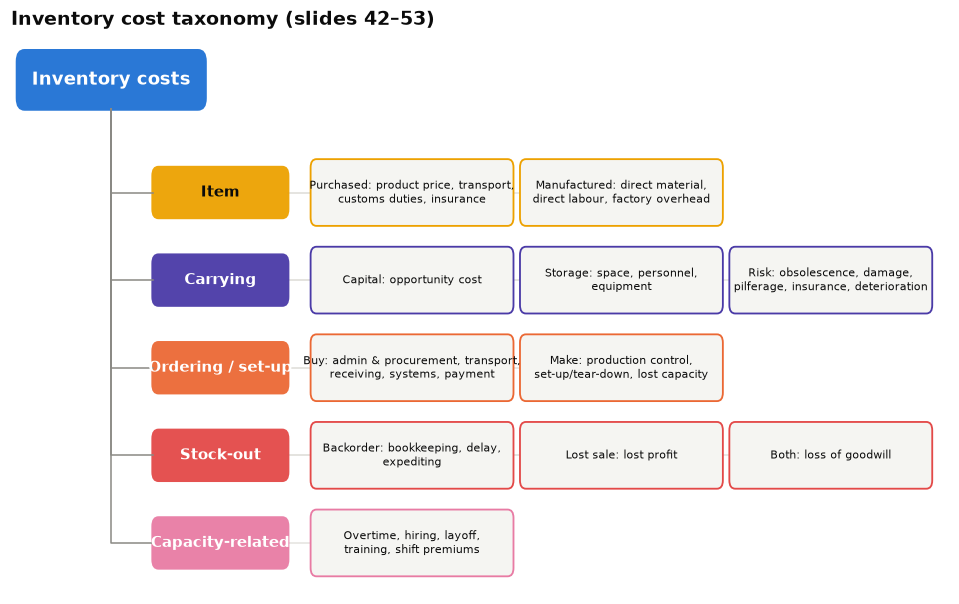

📄 **PDF report exported:** `reports\P6_0_cost_taxonomy.pdf`

In [27]:
def run_cost_taxonomy():
    sec = Section("P6_0_cost_taxonomy", "The inventory cost structure", part="Part 6 · Show me the money")
    tree = {
        "Item": ["Purchased: product price, transport,\ncustoms duties, insurance",
                 "Manufactured: direct material,\ndirect labour, factory overhead"],
        "Carrying": ["Capital: opportunity cost", "Storage: space, personnel,\nequipment",
                     "Risk: obsolescence, damage,\npilferage, insurance, deterioration"],
        "Ordering / set-up": ["Buy: admin & procurement, transport,\nreceiving, systems, payment",
                              "Make: production control,\nset-up/tear-down, lost capacity"],
        "Stock-out": ["Backorder: bookkeeping, delay,\nexpediting", "Lost sale: lost profit",
                      "Both: loss of goodwill"],
        "Capacity-related": ["Overtime, hiring, layoff,\ntraining, shift premiums"],
    }
    cols = [C["yellow"], C["violet"], C["orange"], C["red"], C["magenta"]]
    fig, ax = plt.subplots(figsize=(11, 6.6)); ax.axis("off")
    ax.add_patch(FancyBboxPatch((-0.9, 5.6), 3.2, 0.7, boxstyle="round,pad=0.02,rounding_size=0.15", fc=C["blue"], ec="none"))
    ax.text(0.7, 5.95, "Inventory costs", ha="center", va="center", color="white", fontsize=12, fontweight="bold")
    y = 4.6
    for (k, leaves), colr in zip(tree.items(), cols):
        ax.plot([0.7, 0.7, 1.4], [5.6, y, y], color=MUTED, lw=1)
        ax.add_patch(FancyBboxPatch((1.4, y - 0.3), 2.3, 0.6, boxstyle="round,pad=0.02,rounding_size=0.12", fc=colr,
                                    ec="none", alpha=0.95))
        ax.text(2.55, y, k, ha="center", va="center", color="white" if k != "Item" else INK, fontsize=10,
                fontweight="bold")
        for j, lf in enumerate(leaves):
            xx = 4.1 + j * 3.55
            ax.plot([3.7, xx], [y, y], color=GRID, lw=1, zorder=0)
            ax.add_patch(FancyBboxPatch((xx, y - 0.38), 3.4, 0.76, boxstyle="round,pad=0.02,rounding_size=0.1",
                                        fc="#f5f5f2", ec=colr, lw=1.2))
            ax.text(xx + 1.7, y, lf, ha="center", va="center", fontsize=7.3, color=INK)
        y -= 1.05
    ax.set_xlim(-1, 14.9); ax.set_ylim(-0.2, 6.5)
    ax.set_title("Inventory cost taxonomy (slides 42–53)", loc="left", fontsize=12.5, fontweight="bold")
    sec.figure(fig, "The five cost families and their components.")
    return sec

sec_costs0 = run_cost_taxonomy()
export_section(sec_costs0);

## 6.1 Item costs (slide 43)

- **Purchased items** — landed cost = product price + transportation + customs duties + insurance.
- **Manufactured items** — direct material + direct labour + factory overhead.

**Input file:** `data/item_unit_costs.csv`

`Purchased: v = price + transport + duties + insurance     Manufactured: v = DM + DL + OH`

,Value
Key result,
Compressor (purchased),$735.00
Drum bearing (purchased),$46.30
Inverter PCB (purchased),$483.00
Washer housing (made),$370.00
Door assembly (made),$258.00
Wire harness (made),$107.00
Avg landed-cost uplift over price,19.4 %


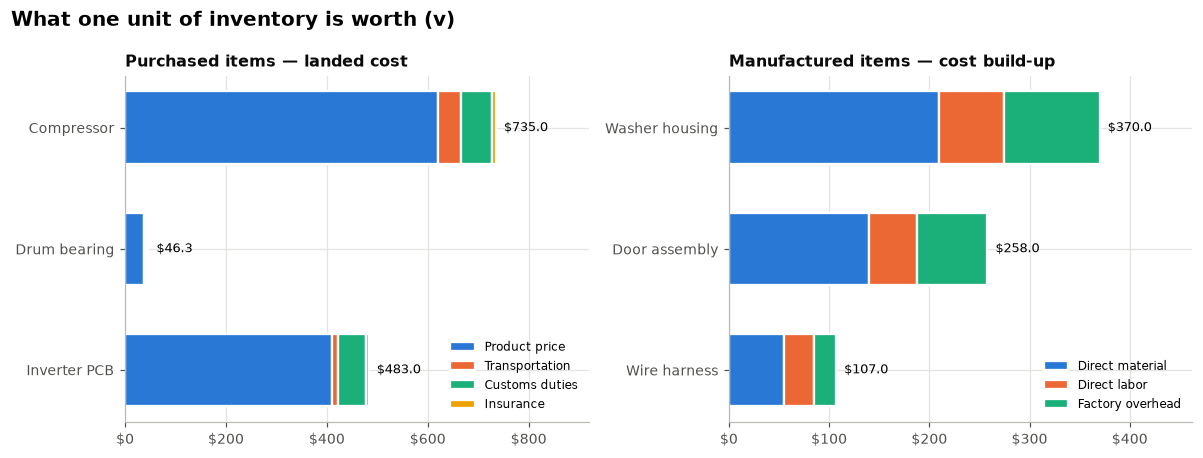

*Item cost build-up ($ per unit).*

,item,type,product_price,transportation,customs_duties,insurance,direct_material,direct_labor,factory_overhead,unit_item_cost
0,Compressor,Purchased,620.00,45.00,62.00,8.00,0.00,0.00,0.00,735.00
1,Drum bearing,Purchased,38.00,3.50,4.20,0.60,0.00,0.00,0.00,46.30
2,Inverter PCB,Purchased,410.00,12.00,55.00,6.00,0.00,0.00,0.00,483.00
3,Washer housing,Manufactured,0.00,0.00,0.00,0.00,210.00,65.00,95.00,370.00
4,Door assembly,Manufactured,0.00,0.00,0.00,0.00,140.00,48.00,70.00,258.00
5,Wire harness,Manufactured,0.00,0.00,0.00,0.00,55.00,30.00,22.00,107.00


📄 **PDF report exported:** `reports\P6_1_item_costs.pdf`

In [28]:
def run_item_costs(df=None):
    df = pd.read_csv(DATA / "item_unit_costs.csv") if df is None else df.copy()
    sec = Section("P6_1_item_costs", "Item (unit) costs of purchased and manufactured items",
                  part="Part 6 · Show me the money")
    pc = ["product_price", "transportation", "customs_duties", "insurance"]
    mc = ["direct_material", "direct_labor", "factory_overhead"]
    df["unit_item_cost"] = df[pc + mc].sum(axis=1)
    P = df[df.type == "Purchased"].set_index("item"); M = df[df.type == "Manufactured"].set_index("item")
    sec.equation("Purchased: v = price + transport + duties + insurance     Manufactured: v = DM + DL + OH")
    sec.metrics({**{f"{i} (purchased)": f"${v:,.2f}" for i, v in P.unit_item_cost.items()},
                 **{f"{i} (made)": f"${v:,.2f}" for i, v in M.unit_item_cost.items()},
                 "Avg landed-cost uplift over price": f"{100*(P[pc[1:]].sum(1)/P.product_price).mean():.1f} %"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, Tb, cc, ttl in [(axs[0], P, pc, "Purchased items — landed cost"), (axs[1], M, mc, "Manufactured items — cost build-up")]:
        left = np.zeros(len(Tb))
        for c, colr in zip(cc, SERIES):
            ax.barh(Tb.index, Tb[c], left=left, color=colr, edgecolor=SURF, linewidth=1.5, height=0.6,
                    label=c.replace("_", " ").capitalize())
            left += Tb[c].values
        for yi, v in enumerate(left):
            ax.text(v, yi, f"  ${v:,.1f}", va="center", fontsize=8.5)
        ax.set_xlim(0, left.max() * 1.25); ax.invert_yaxis(); ax.legend(loc="lower right", fontsize=8)
        ax.set_title(ttl, fontsize=10.5); axis_fmt(ax, "x", pre="$")
    fig.suptitle("What one unit of inventory is worth (v)", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Unit cost components. The unit value v is the basis of the holding cost h = r·v.")
    sec.table(df, "Item cost build-up ($ per unit).", formats={c: ",.2f" for c in pc + mc + ["unit_item_cost"]})
    return sec, df

sec_item, item_df = run_item_costs()
export_section(sec_item);

## 6.2 Carrying (holding) costs and the opportunity cost of capital (slides 44–46)

Carrying cost combines **capital cost** (opportunity cost of money tied up), **storage cost** (space, personnel, equipment) and **risk cost** (obsolescence, damage, pilferage, insurance, deterioration). The accounting department expresses it as an annual rate $r$ per \$ invested — lecture: 28 % + 2 % + 6 % + 1 % = **37 %**, i.e. *37 piasters per Egyptian pound per year*. Per unit:

$$h = r\times v \qquad\qquad \text{Total holding cost} = h \times \bar I \times \text{years}$$

Lecture example: $v = \$180$, $h = 0.37 \times 180 = \$66.60$ per unit-year; 300 units held for 5 years cost $5\times300\times66.60 = \$99{,}900$. *(The slide prints \$99,990 — a typo; the product is \$99,900.)*

**Input files:** `data/holding_cost_rate_components.csv`, `data/holding_cost_items.csv`.

`r = 28% + 2% + 6% + 1% = 37%     h = 0.37 × 180 = 66.60     Total = 5 × 300 × 66.60 = 99,900.00`

,Value
Key result,
Annual carrying rate r,37 %
Piasters per EGP per year,37
h for the $180 item,$66.60 /unit/yr
300 units × 5 years,"$99,900"
Capital cost share of r,76%


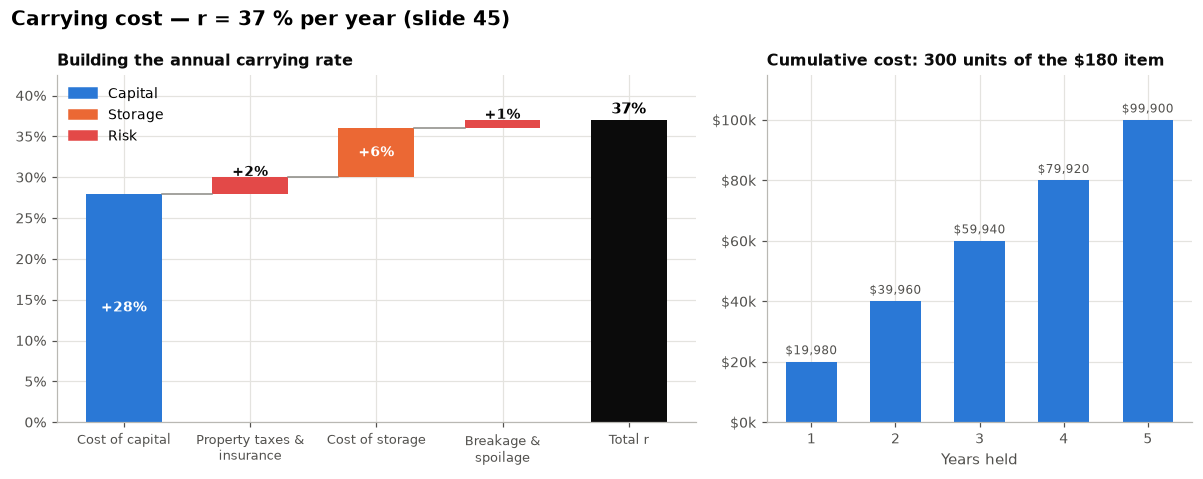

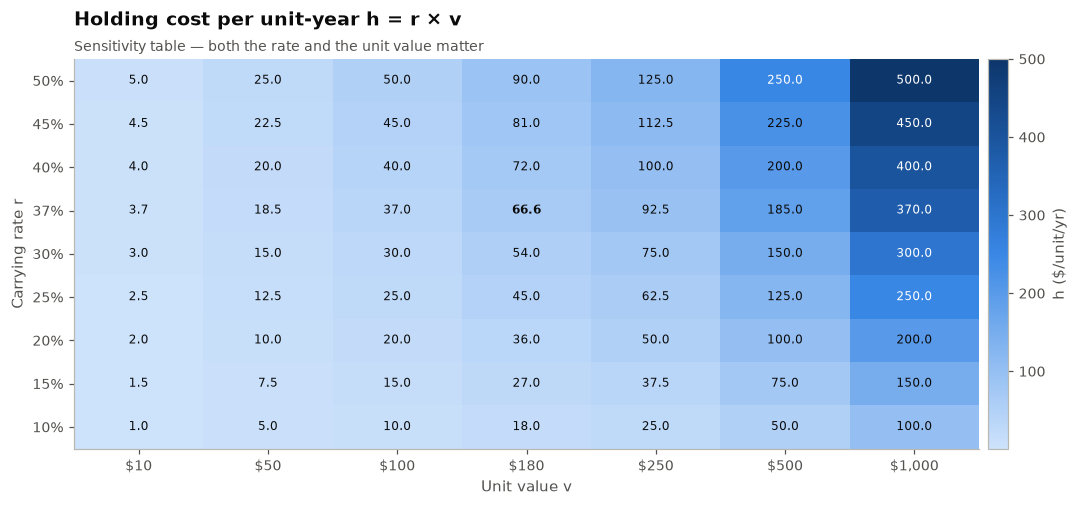

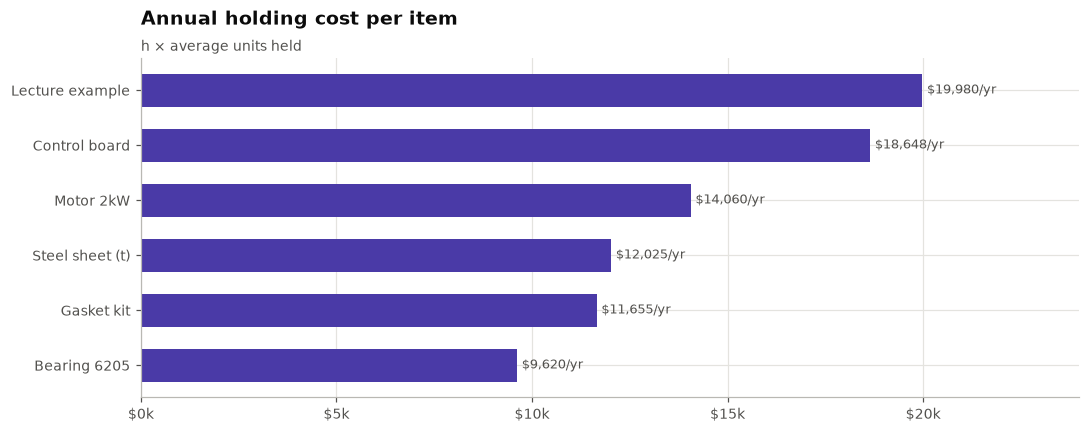

*Carrying-rate components.*

,component,group,annual_rate_pct
0,Cost of capital,Capital cost,28
1,Property taxes & insurance,Risk cost,2
2,Cost of storage,Storage cost,6
3,Breakage & spoilage,Risk cost,1


*Holding cost by item.*

,item,unit_value,avg_units_held,years_held,h_per_unit_year,holding_cost_per_year,total_holding_cost
0,Lecture example,$180.00,300,5,$66.60,"$19,980","$99,900"
1,Motor 2kW,$950.00,40,1,$351.50,"$14,060","$14,060"
2,Control board,$420.00,120,1,$155.40,"$18,648","$18,648"
3,Steel sheet (t),"$1,300.00",25,1,$481.00,"$12,025","$12,025"
4,Gasket kit,$35.00,900,1,$12.95,"$11,655","$11,655"
5,Bearing 6205,$6.50,"4,000",1,$2.40,"$9,620","$9,620"


📄 **PDF report exported:** `reports\P6_2_carrying_cost.pdf`

In [29]:
def run_holding(comp=None, items=None):
    comp = pd.read_csv(DATA / "holding_cost_rate_components.csv") if comp is None else comp.copy()
    items = pd.read_csv(DATA / "holding_cost_items.csv") if items is None else items.copy()
    sec = Section("P6_2_carrying_cost", "Carrying cost: from the annual rate r to the unit holding cost h = r·v",
                  part="Part 6 · Show me the money")
    r = comp.annual_rate_pct.sum() / 100
    items["h_per_unit_year"] = r * items.unit_value
    items["holding_cost_per_year"] = items.h_per_unit_year * items.avg_units_held
    items["total_holding_cost"] = items.holding_cost_per_year * items.years_held
    ex = items.iloc[0]
    sec.equation(f"r = {' + '.join(f'{x:g}%' for x in comp.annual_rate_pct)} = {100*r:g}%     "
                 f"h = {r:.2f} × {ex.unit_value:,.0f} = {ex.h_per_unit_year:,.2f}     "
                 f"Total = {ex.years_held:g} × {ex.avg_units_held:,.0f} × {ex.h_per_unit_year:,.2f} = {ex.total_holding_cost:,.2f}")
    sec.metrics({"Annual carrying rate r": f"{100*r:.0f} %", "Piasters per EGP per year": f"{100*r:.0f}",
                 "h for the $180 item": f"${ex.h_per_unit_year:,.2f} /unit/yr",
                 "300 units × 5 years": f"${ex.total_holding_cost:,.0f}",
                 "Capital cost share of r": f"{comp.loc[comp.group=='Capital cost','annual_rate_pct'].sum()/comp.annual_rate_pct.sum():.0%}"})

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
    ax = axs[0]; cum = 0
    for i, row in comp.iterrows():
        colr = {"Capital cost": C["blue"], "Storage cost": C["orange"], "Risk cost": C["red"]}[row.group]
        ax.bar(i, row.annual_rate_pct, bottom=cum, color=colr, width=0.6)
        ax.text(i, cum + row.annual_rate_pct / 2 if row.annual_rate_pct > 4 else cum + row.annual_rate_pct + 0.6,
                f"+{row.annual_rate_pct:g}%", ha="center", va="center", fontsize=9,
                color="white" if row.annual_rate_pct > 4 else INK, fontweight="bold")
        if i < len(comp) - 1:
            ax.plot([i + 0.3, i + 0.7], [cum + row.annual_rate_pct] * 2, color=MUTED, lw=1)
        cum += row.annual_rate_pct
    ax.bar(len(comp), cum, color=INK, width=0.6); ax.text(len(comp), cum + 0.8, f"{cum:g}%", ha="center", fontweight="bold")
    ax.set_xticks(range(len(comp) + 1)); ax.set_xticklabels(list(comp.component.str.replace(" & ", " &\n")) + ["Total r"],
                                                            fontsize=8.5)
    axis_fmt(ax, suf="%"); ax.set_ylim(0, cum * 1.15); ax.set_title("Building the annual carrying rate", fontsize=10.5)
    ax.legend(handles=[Patch(color=C["blue"], label="Capital"), Patch(color=C["orange"], label="Storage"),
                       Patch(color=C["red"], label="Risk")], loc="upper left")
    ax = axs[1]
    yrs = np.arange(0, ex.years_held + 1)
    cumc = yrs * ex.holding_cost_per_year
    ax.bar(yrs[1:], cumc[1:], color=C["blue"], width=0.6)
    label_bars(ax, ax.patches, "${:,.0f}", fontsize=7.8)
    ax.set_xlabel("Years held"); axis_fmt(ax, pre="$", scale=1e3, suf="k")
    ax.set_ylim(0, cumc.max() * 1.15)
    ax.set_title(f"Cumulative cost: 300 units of the $180 item", fontsize=10.5)
    fig.suptitle("Carrying cost — r = 37 % per year (slide 45)", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Left: components of r (waterfall). Right: cumulative holding cost of the lecture example.")

    fig, ax = plt.subplots(figsize=(11, 4.6))
    rr = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.37, 0.40, 0.45, 0.50]); vv = np.array([10, 50, 100, 180, 250, 500, 1000])
    Hm = np.outer(rr, vv)
    im = ax.imshow(Hm, cmap=SEQ_CMAP, aspect="auto", origin="lower"); ax.grid(False)
    ax.set_xticks(range(len(vv))); ax.set_xticklabels([f"${v:,}" for v in vv])
    ax.set_yticks(range(len(rr))); ax.set_yticklabels([f"{x:.0%}" for x in rr])
    for i in range(len(rr)):
        for j in range(len(vv)):
            ax.text(j, i, f"{Hm[i, j]:,.1f}", ha="center", va="center", fontsize=7.8,
                    color="white" if Hm[i, j] > Hm.max() * 0.45 else INK,
                    fontweight="bold" if abs(rr[i] - 0.37) < 1e-9 and vv[j] == 180 else None)
    ax.set_xlabel("Unit value v"); ax.set_ylabel("Carrying rate r")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="h ($/unit/yr)")
    style_title(ax, "Holding cost per unit-year h = r × v", "Sensitivity table — both the rate and the unit value matter")
    sec.figure(fig, "h for combinations of r and v.")

    fig, ax = plt.subplots(figsize=(11, 4))
    ii = items.sort_values("holding_cost_per_year")
    b = ax.barh(ii["item"], ii.holding_cost_per_year, color=C["violet"], height=0.6)
    label_bars(ax, b, "${:,.0f}/yr", horizontal=True); axis_fmt(ax, "x", pre="$", scale=1e3, suf="k")
    ax.set_xlim(0, ii.holding_cost_per_year.max() * 1.2)
    style_title(ax, "Annual holding cost per item", "h × average units held")
    sec.figure(fig, "Annual holding cost by item at r = 37 %.")
    sec.table(comp, "Carrying-rate components.", formats={"annual_rate_pct": ".0f"})
    sec.table(items, "Holding cost by item.", formats={"unit_value": "$,.2f", "avg_units_held": ",.0f", "years_held": "g",
                                                       "h_per_unit_year": "$,.2f", "holding_cost_per_year": "$,.0f",
                                                       "total_holding_cost": "$,.0f"})
    return sec, items

sec_hold, hold_items = run_holding()
export_section(sec_hold);

## 6.3 Ordering and set-up costs (slides 47–49)

The ordering cost $A$ is the *fixed* cost incurred each time an order is placed (buy) or a production run is set up (make) — independent of the order size. Annual ordering cost $= A \times$ (orders per year) $= A\,D/Q$.

**Input file:** `data/ordering_cost_elements.csv` (cost per order in EGP by category).

,Value
Key result,
Ordering cost per purchase order (A_buy),"EGP 2,630"
Set-up cost per production run (A_make),"EGP 4,150"
Largest buy element,Inbound freight (fixed part)
Lost-capacity share of set-up,46%


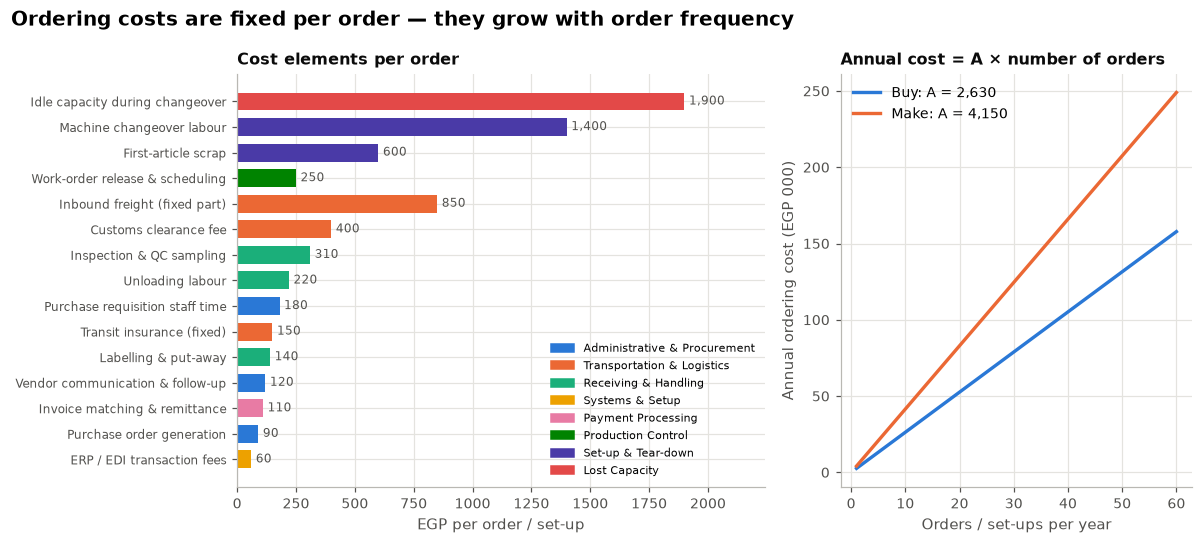

*Ordering / set-up cost elements.*

,mode,category,element,cost_per_order_egp
0,Buy,Administrative & Procurement,Purchase requisition staff time,180
1,Buy,Administrative & Procurement,Purchase order generation,90
2,Buy,Administrative & Procurement,Vendor communication & follow-up,120
3,Buy,Transportation & Logistics,Inbound freight (fixed part),850
4,Buy,Transportation & Logistics,Customs clearance fee,400
5,Buy,Transportation & Logistics,Transit insurance (fixed),150
6,Buy,Receiving & Handling,Unloading labour,220
7,Buy,Receiving & Handling,Inspection & QC sampling,310
8,Buy,Receiving & Handling,Labelling & put-away,140
9,Buy,Systems & Setup,ERP / EDI transaction fees,60


*Annual ordering cost for selected frequencies.*

,orders_per_year,annual_cost_buy_EGP,annual_cost_make_EGP
0,4,"10,520","16,600"
1,12,"31,560","49,800"
2,26,"68,380","107,900"
3,52,"136,760","215,800"


📄 **PDF report exported:** `reports\P6_3_ordering_cost.pdf`

In [30]:
def run_ordering(df=None, annual_orders=(4, 12, 26, 52)):
    df = pd.read_csv(DATA / "ordering_cost_elements.csv") if df is None else df.copy()
    sec = Section("P6_3_ordering_cost", "Ordering (buy) and set-up (make) costs", part="Part 6 · Show me the money")
    A = df.groupby("mode").cost_per_order_egp.sum()
    cat = df.groupby(["mode", "category"]).cost_per_order_egp.sum().reset_index()
    sec.metrics({"Ordering cost per purchase order (A_buy)": f"EGP {A['Buy']:,.0f}",
                 "Set-up cost per production run (A_make)": f"EGP {A['Make']:,.0f}",
                 "Largest buy element": df[df["mode"] == "Buy"].sort_values("cost_per_order_egp").iloc[-1].element,
                 "Lost-capacity share of set-up": f"{df[(df['mode']=='Make')&(df.category=='Lost Capacity')].cost_per_order_egp.sum()/A['Make']:.0%}"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.5, 1]})
    dd = df.sort_values(["mode", "cost_per_order_egp"])
    cats = list(dict.fromkeys(df.category))
    cc = {k: SERIES[i % len(SERIES)] for i, k in enumerate(cats)}
    b = axs[0].barh(dd.element, dd.cost_per_order_egp, color=[cc[c] for c in dd.category], height=0.7)
    label_bars(axs[0], b, "{:,.0f}", horizontal=True, fontsize=7.8)
    axs[0].set_xlabel("EGP per order / set-up"); axs[0].tick_params(axis="y", labelsize=8)
    axs[0].set_xlim(0, dd.cost_per_order_egp.max() * 1.18)
    axs[0].legend(handles=[Patch(color=cc[k], label=k) for k in cats], fontsize=7.5, loc="lower right")
    axs[0].set_title("Cost elements per order", fontsize=10.5)
    orders = np.arange(1, 61)
    for m, colr in [("Buy", C["blue"]), ("Make", C["orange"])]:
        axs[1].plot(orders, A[m] * orders / 1e3, color=colr, lw=2.2, label=f"{m}: A = {A[m]:,.0f}")
    axs[1].set_xlabel("Orders / set-ups per year"); axs[1].set_ylabel("Annual ordering cost (EGP 000)")
    axs[1].legend(loc="upper left"); axs[1].set_title("Annual cost = A × number of orders", fontsize=10.5)
    fig.suptitle("Ordering costs are fixed per order — they grow with order frequency", x=0.01, ha="left", fontsize=13,
                 fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Ordering / set-up cost elements and annual ordering cost vs frequency.")
    tab = pd.DataFrame({"orders_per_year": annual_orders,
                        "annual_cost_buy_EGP": [A["Buy"] * n for n in annual_orders],
                        "annual_cost_make_EGP": [A["Make"] * n for n in annual_orders]})
    sec.table(df, "Ordering / set-up cost elements.", formats={"cost_per_order_egp": ",.0f"})
    sec.table(tab, "Annual ordering cost for selected frequencies.",
              formats={"orders_per_year": "d", "annual_cost_buy_EGP": ",.0f", "annual_cost_make_EGP": ",.0f"})
    return sec, A

sec_order, A_cost = run_ordering()
export_section(sec_order);

## 6.4 Putting holding and ordering together — "how large should the order be?" (preview)

Ordering in larger lots reduces the number of orders (ordering cost $A D/Q$ falls) but raises the average cycle stock $Q/2$ (holding cost $h Q/2$ rises). The total relevant cost

$$TRC(Q)=\frac{A\,D}{Q}+\frac{h\,Q}{2},\qquad h=r\,v$$

has a minimum where the two are balanced. The optimal-lot formula (EOQ) is derived in the next lecture; here the minimum is found numerically.

**Input:** `scenario_parameters.json → order_tradeoff_item` (the ordering cost is the Buy total from 6.3).

Item **Inverter PCB** — D = **4,800**/yr, v = **410**, A = **2,630** per order, r = **37%** → h = **151.70** per unit-year.

$$TRC(Q)=\frac{AD}{Q}+\frac{hQ}{2}$$

,Value
Key result,
Cost-minimising Q (numerical),408 units
Orders per year,11.8
Minimum total relevant cost,"61,888/yr"
Ordering = holding at optimum?,"30,941 vs 30,947"
Cost within +10 % for Q in,262–635


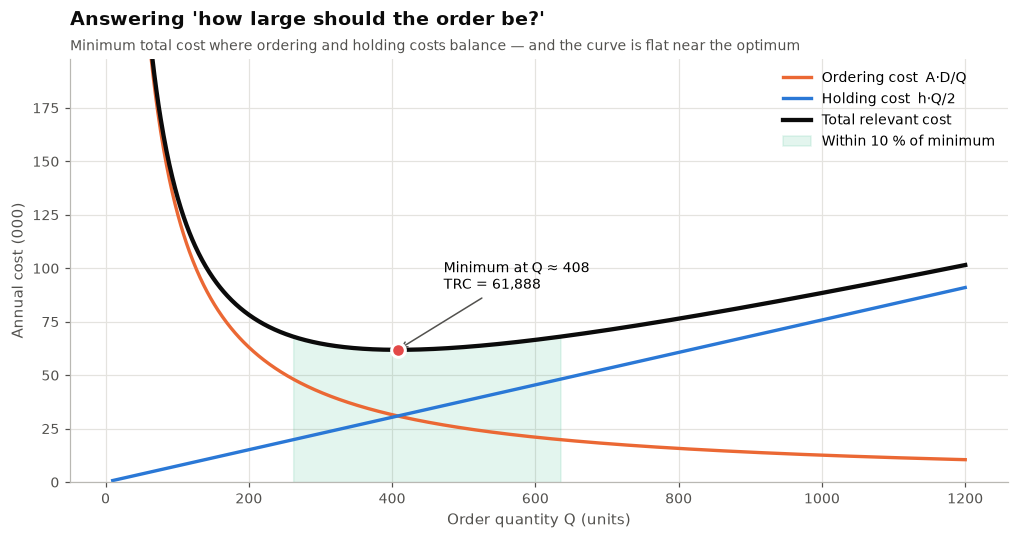

*Cost of alternative order quantities.*

,Q,orders_per_year,avg_cycle_stock,ordering_cost,holding_cost,total_cost,pct_above_min
0,50,96.0,25,"252,480","3,792","256,272",+314.1%
1,100,48.0,50,"126,240","7,585","133,825",+116.2%
2,200,24.0,100,"63,120","15,170","78,290",+26.5%
3,408,11.8,204,"30,941","30,947","61,888",+0.0%
4,400,12.0,200,"31,560","30,340","61,900",+0.0%
5,800,6.0,400,"15,780","60,680","76,460",+23.5%


📄 **PDF report exported:** `reports\P6_4_cost_tradeoff.pdf`

In [31]:
def run_tradeoff(p=None):
    p = p or PARAMS["order_tradeoff_item"]
    sec = Section("P6_4_cost_tradeoff", "The holding vs ordering cost trade-off (preview of lot sizing)",
                  part="Part 6 · Show me the money")
    D, v, A, r = p["annual_demand"], p["unit_value"], p["ordering_cost"], p["holding_rate"]
    h = r * v
    Q = np.arange(10, 1201, 1.0)
    order_c, hold_c = A * D / Q, h * Q / 2
    tot = order_c + hold_c
    i = int(np.argmin(tot)); Qs = Q[i]
    alt = pd.DataFrame({"Q": [50, 100, 200, Qs, 400, 800]})
    alt["orders_per_year"] = D / alt.Q; alt["avg_cycle_stock"] = alt.Q / 2
    alt["ordering_cost"] = A * D / alt.Q; alt["holding_cost"] = h * alt.Q / 2
    alt["total_cost"] = alt.ordering_cost + alt.holding_cost
    alt["pct_above_min"] = alt.total_cost / tot[i] - 1
    sec.text(f"Item **{p['name']}** — D = **{D:,}**/yr, v = **{v:,}**, A = **{A:,}** per order, r = **{r:.0%}** "
             f"→ h = **{h:,.2f}** per unit-year.")
    sec.equation("TRC(Q) = A·D/Q + h·Q/2", r"TRC(Q)=\frac{AD}{Q}+\frac{hQ}{2}")
    sec.metrics({"Cost-minimising Q (numerical)": f"{Qs:,.0f} units", "Orders per year": f"{D/Qs:.1f}",
                 "Minimum total relevant cost": f"{tot[i]:,.0f}/yr",
                 "Ordering = holding at optimum?": f"{order_c[i]:,.0f} vs {hold_c[i]:,.0f}",
                 "Cost within +10 % for Q in": f"{Q[tot <= 1.1*tot[i]].min():,.0f}–{Q[tot <= 1.1*tot[i]].max():,.0f}"})
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(Q, order_c / 1e3, color=C["orange"], lw=2.2, label="Ordering cost  A·D/Q")
    ax.plot(Q, hold_c / 1e3, color=C["blue"], lw=2.2, label="Holding cost  h·Q/2")
    ax.plot(Q, tot / 1e3, color=INK, lw=2.8, label="Total relevant cost")
    band = tot <= 1.1 * tot[i]
    ax.fill_between(Q, 0, tot / 1e3, where=band, color=C["aqua"], alpha=0.12, label="Within 10 % of minimum")
    ax.scatter([Qs], [tot[i] / 1e3], s=80, color=C["red"], zorder=4, edgecolor=SURF, linewidth=2)
    ax.annotate(f"Minimum at Q ≈ {Qs:,.0f}\nTRC = {tot[i]:,.0f}", (Qs, tot[i] / 1e3), xytext=(30, 40),
                textcoords="offset points", fontsize=9, arrowprops=dict(arrowstyle="->", color=INK2))
    ax.set_ylim(0, tot[i] / 1e3 * 3.2); ax.set_xlabel("Order quantity Q (units)"); ax.set_ylabel("Annual cost (000)")
    ax.legend(loc="upper right")
    style_title(ax, "Answering 'how large should the order be?'",
                "Minimum total cost where ordering and holding costs balance — and the curve is flat near the optimum")
    sec.figure(fig, "Annual ordering, holding and total relevant cost vs order quantity.")
    sec.table(alt, "Cost of alternative order quantities.",
              formats={"Q": ",.0f", "orders_per_year": ".1f", "avg_cycle_stock": ",.0f", "ordering_cost": ",.0f",
                       "holding_cost": ",.0f", "total_cost": ",.0f", "pct_above_min": "+.1%"})
    return sec, alt

sec_trade, trade_tab = run_tradeoff()
export_section(sec_trade);

## 6.5 Stock-out (shortage) costs (slides 50–52)

Causes: demand during the lead time exceeds forecast and available inventory; production and supplier problems.
The cost depends on how excess demand is treated:

$$\text{Backorder: } c_{BO} = n\,(c_{admin} + c_{delay}\,\text{days} + g_{BO}) \qquad\text{Lost sale: } c_{LS} = n\,(p\,m + g_{LS})$$

plus a fixed **expediting** cost when an emergency shipment is used. $g$ = loss-of-goodwill per unit (hard to estimate in practice).

**Input files:** `data/stockout_events.csv` (40 events in a year) and `scenario_parameters.json → stockout_costs`.

,Value
Key result,
Stock-out events,"40 (25 backorders, 15 lost sales)"
Total annual stock-out cost,"$341,604"
Avg cost per short unit — backorder,$60.35
Avg cost per short unit — lost sale,$263.70
Goodwill share of total,26%
Expedited events,15


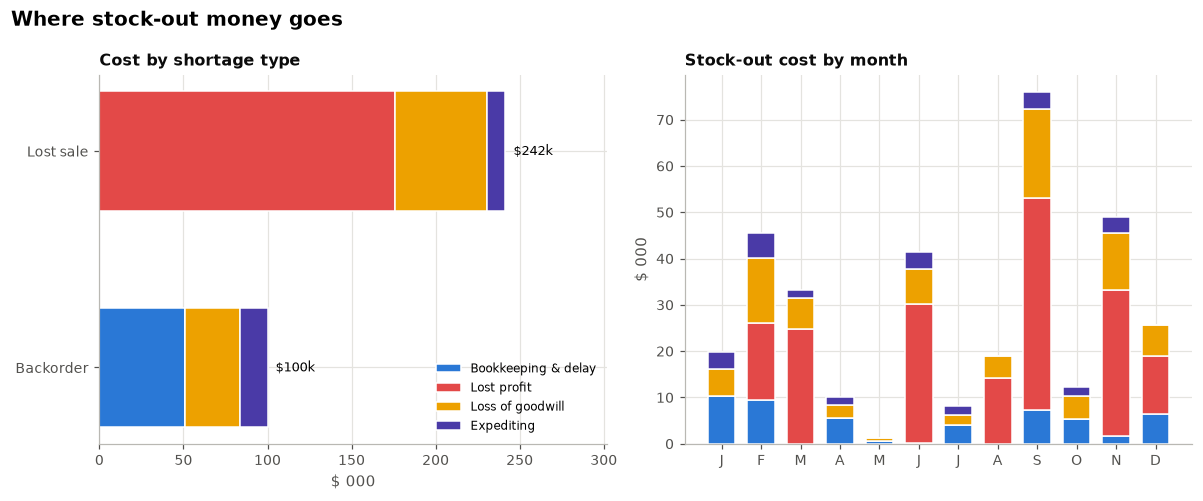

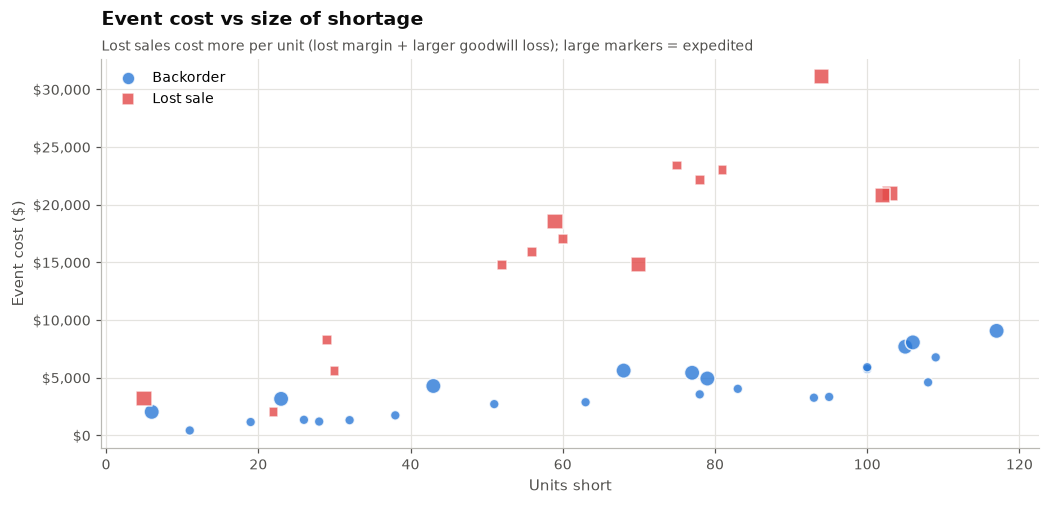

*Stock-out cost by item.*

,item,events,short_units,total_cost,cost_per_unit_short
0,Inverter PCB,16,860,"$152,413",$177.22
1,Compressor,9,629,"$83,926",$133.43
2,Door assembly,9,693,"$82,204",$118.62
3,Drum bearing,6,392,"$23,062",$58.83


*Fifteen most expensive stock-out events.*

,event_id,month,item,type,short_units,delay_days,expedited,bookkeeping_delay_cost,lost_profit,goodwill_loss,expediting_cost,total_cost
0,25,6,Compressor,lost_sale,94,0,Yes,$0,"$23,688","$5,640","$1,800","$31,128"
1,28,9,Compressor,lost_sale,75,0,No,$0,"$18,900","$4,500",$0,"$23,400"
2,24,9,Inverter PCB,lost_sale,81,0,No,$0,"$18,144","$4,860",$0,"$23,004"
3,7,11,Inverter PCB,lost_sale,78,0,No,$0,"$17,472","$4,680",$0,"$22,152"
4,2,11,Door assembly,lost_sale,103,0,Yes,$0,"$12,978","$6,180","$1,800","$20,958"
5,21,2,Door assembly,lost_sale,102,0,Yes,$0,"$12,852","$6,120","$1,800","$20,772"
6,19,3,Inverter PCB,lost_sale,59,0,Yes,$0,"$13,216","$3,540","$1,800","$18,556"
7,37,8,Inverter PCB,lost_sale,60,0,No,$0,"$13,440","$3,600",$0,"$17,040"
8,4,12,Inverter PCB,lost_sale,56,0,No,$0,"$12,544","$3,360",$0,"$15,904"
9,26,9,Door assembly,lost_sale,70,0,Yes,$0,"$8,820","$4,200","$1,800","$14,820"


📄 **PDF report exported:** `reports\P6_5_stockout_cost.pdf`

In [32]:
def run_stockout(ev=None, p=None):
    ev = pd.read_csv(DATA / "stockout_events.csv") if ev is None else ev.copy()
    p = p or PARAMS["stockout_costs"]
    sec = Section("P6_5_stockout_cost", "Stock-out costs: backorders vs lost sales", part="Part 6 · Show me the money")
    bo = ev.type == "backorder"
    ev["bookkeeping_delay_cost"] = np.where(bo, ev.short_units * (p["backorder_admin_per_unit"] +
                                                                  p["backorder_delay_cost_per_unit_day"] * ev.delay_days), 0)
    ev["lost_profit"] = np.where(~bo, ev.short_units * ev.unit_price * ev.profit_margin, 0)
    ev["goodwill_loss"] = ev.short_units * np.where(bo, p["goodwill_per_unit_backorder"], p["goodwill_per_unit_lost"])
    ev["expediting_cost"] = np.where(ev.expedited, p["expediting_fixed"], 0)
    comps = ["bookkeeping_delay_cost", "lost_profit", "goodwill_loss", "expediting_cost"]
    ev["total_cost"] = ev[comps].sum(axis=1)
    ev["cost_per_short_unit"] = ev.total_cost / ev.short_units
    tot = ev.total_cost.sum()
    sec.metrics({"Stock-out events": f"{len(ev)} ({bo.sum()} backorders, {(~bo).sum()} lost sales)",
                 "Total annual stock-out cost": f"${tot:,.0f}",
                 "Avg cost per short unit — backorder": f"${ev[bo].total_cost.sum()/ev[bo].short_units.sum():,.2f}",
                 "Avg cost per short unit — lost sale": f"${ev[~bo].total_cost.sum()/ev[~bo].short_units.sum():,.2f}",
                 "Goodwill share of total": f"{ev.goodwill_loss.sum()/tot:.0%}",
                 "Expedited events": f"{int(ev.expedited.sum())}"})
    names = {"bookkeeping_delay_cost": "Bookkeeping & delay", "lost_profit": "Lost profit",
             "goodwill_loss": "Loss of goodwill", "expediting_cost": "Expediting"}
    cc = dict(zip(comps, [C["blue"], C["red"], C["yellow"], C["violet"]]))
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
    by_type = ev.groupby("type")[comps].sum().rename(index={"backorder": "Backorder", "lost_sale": "Lost sale"})
    left = np.zeros(len(by_type))
    for c in comps:
        axs[0].barh(by_type.index, by_type[c] / 1e3, left=left, color=cc[c], edgecolor=SURF, height=0.55, label=names[c])
        left += by_type[c].values / 1e3
    for yi, v in enumerate(left): axs[0].text(v, yi, f"  ${v:,.0f}k", va="center", fontsize=8.5)
    axs[0].set_xlim(0, left.max() * 1.25); axs[0].set_xlabel("$ 000"); axs[0].legend(fontsize=8, loc="lower right")
    axs[0].set_title("Cost by shortage type", fontsize=10.5)
    by_m = ev.groupby("month")[comps].sum().reindex(range(1, 13), fill_value=0)
    bottom = np.zeros(12)
    for c in comps:
        axs[1].bar(by_m.index, by_m[c] / 1e3, bottom=bottom, color=cc[c], edgecolor=SURF, width=0.7)
        bottom += by_m[c].values / 1e3
    axs[1].set_xticks(range(1, 13)); axs[1].set_xticklabels(list("JFMAMJJASOND")); axs[1].set_ylabel("$ 000")
    axs[1].set_title("Stock-out cost by month", fontsize=10.5)
    fig.suptitle("Where stock-out money goes", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Stock-out cost components by type and by month.")
    fig, ax = plt.subplots(figsize=(11, 4.6))
    for t, colr, mk in [("backorder", C["blue"], "o"), ("lost_sale", C["red"], "s")]:
        m = ev[ev.type == t]
        ax.scatter(m.short_units, m.total_cost, s=40 + 60 * m.expedited, color=colr, marker=mk, alpha=0.8,
                   edgecolor=SURF, linewidth=1, label=t.replace("_", " ").capitalize())
    ax.set_xlabel("Units short"); ax.set_ylabel("Event cost ($)"); axis_fmt(ax, pre="$")
    ax.legend(loc="upper left")
    style_title(ax, "Event cost vs size of shortage", "Lost sales cost more per unit (lost margin + larger goodwill loss); "
                "large markers = expedited")
    sec.figure(fig, "Each point is a stock-out event.")
    item_t = ev.groupby("item").agg(events=("event_id", "size"), short_units=("short_units", "sum"),
                                    total_cost=("total_cost", "sum")).sort_values("total_cost", ascending=False).reset_index()
    item_t["cost_per_unit_short"] = item_t.total_cost / item_t.short_units
    sec.table(item_t, "Stock-out cost by item.", formats={"total_cost": "$,.0f", "cost_per_unit_short": "$,.2f"})
    sec.table(ev.sort_values("total_cost", ascending=False).head(15)[["event_id", "month", "item", "type", "short_units",
                                                                      "delay_days", "expedited"] + comps + ["total_cost"]],
              "Fifteen most expensive stock-out events.",
              formats={**{c: "$,.0f" for c in comps}, "total_cost": "$,.0f"})
    return sec, ev

sec_so, so_ev = run_stockout()
export_section(sec_so);

## 6.6 Capacity-related costs (slide 53)

Meeting a seasonal demand pattern requires a choice between **carrying anticipation stock** and **changing capacity** — overtime, hiring, layoff, training and shift premiums. Three strategies are costed on the seasonal plan from Part 2.4:

| Strategy | Idea | Costs incurred |
|---|---|---|
| **S1 Level + anticipation stock** | Keep the workforce; pre-build with regular time and overtime | Regular, overtime premium, holding |
| **S2 Chase demand** | Hire/lay off so capacity follows demand; extra workers on a 2nd shift | Regular, hiring, training, layoff, shift premium, subcontract during shutdown |
| **S3 Fixed workforce, no stock** | Regular capacity, then overtime, then subcontracting each month | Regular, overtime premium, subcontracting |

**Input:** `data/seasonal_demand_capacity.csv`, `scenario_parameters.json → capacity_costs`.

Every strategy meets all demand. Regular production cost is included for comparability; subcontracting is costed at its full unit price.

,Value
Key result,
S1 Level + anticipation,"$695,941"
S2 Chase demand,"$791,650"
S3 Fixed workforce,"$734,175"
Cheapest strategy,S1 Level + anticipation
Saving vs most expensive,"$95,709"


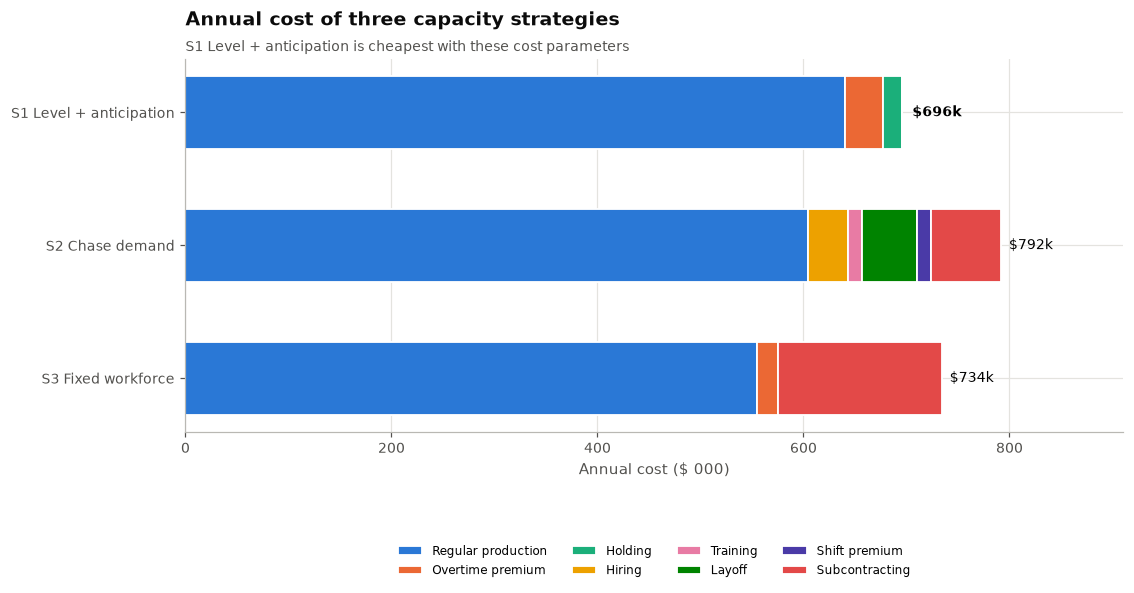

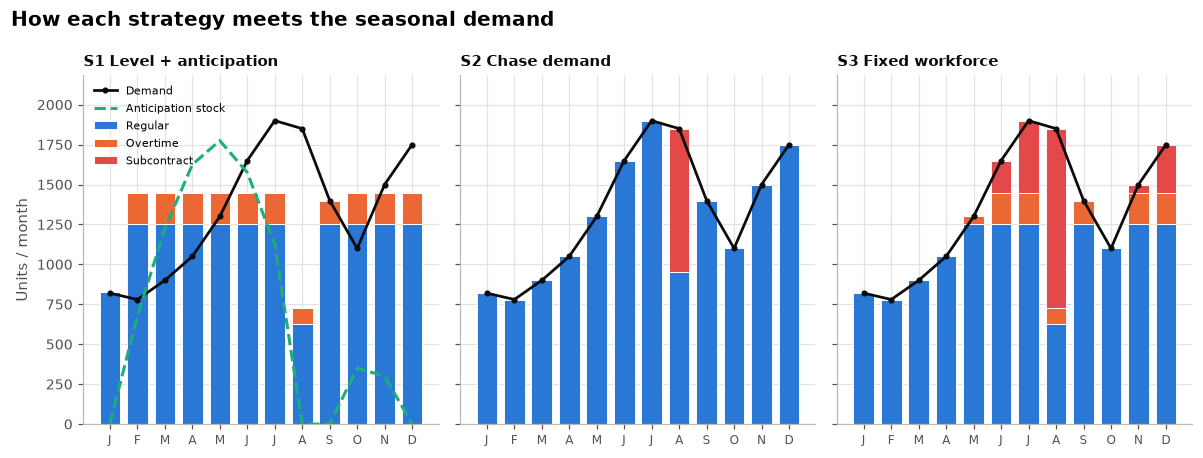

*Annual cost by strategy and component ($).*

,strategy,Regular production,Overtime premium,Holding,Hiring,Training,Layoff,Shift premium,Subcontracting,Total
0,S1 Level + anticipation,"640,000","36,900","19,041",0,0,0,0,0,"695,941"
1,S2 Chase demand,"604,000",0,0,"38,940","14,160","53,100","13,950","67,500","791,650"
2,S3 Fixed workforce,"555,000","19,800",0,0,0,0,0,"159,375","734,175"


📄 **PDF report exported:** `reports\P6_6_capacity_costs.pdf`

In [33]:
def run_capacity_costs(df=None, p=None):
    df = pd.read_csv(DATA / "seasonal_demand_capacity.csv") if df is None else df.copy()
    p = p or PARAMS["capacity_costs"]
    sec = Section("P6_6_capacity_costs", "Capacity-related costs: anticipation stock vs changing capacity",
                  part="Part 6 · Show me the money")
    D = df.demand_forecast.values.astype(float); n = len(D)
    f = np.where(df.planned_shutdown == 1, p["shutdown_capacity_fraction"], 1.0)
    base, ot_cap = df.regular_capacity.values.astype(float), df.overtime_capacity.values.astype(float)
    reg_c, ot_p, sub_c, hold = p["regular_cost_per_unit"], p["overtime_premium_per_unit"], p["subcontract_per_unit"], \
                               p["holding_cost_per_unit_month"]
    plans, costs = {}, {}
    # S1
    prod, inv, short = min_anticipation_plan(D, (base + ot_cap) * f)
    reg = np.minimum(prod, base * f); ot = prod - reg
    plans["S1 Level + anticipation"] = dict(regular=reg, overtime=ot, subcontract=np.zeros(n), inventory=inv)
    costs["S1 Level + anticipation"] = {"Regular production": reg_c * prod.sum(), "Overtime premium": ot_p * ot.sum(),
                                        "Holding": hold * inv.sum(), "Unmet (if infeasible)": sub_c * short}
    # S2 chase
    W = np.zeros(n); prev = base[0]; hire = lay = 0.0; sub = np.zeros(n); regp = np.zeros(n)
    for t in range(n):
        W[t] = prev if f[t] < 1 else D[t]
        hire += max(0, W[t] - prev); lay += max(0, prev - W[t]); prev = W[t]
        regp[t] = min(D[t], W[t] * f[t]); sub[t] = D[t] - regp[t]
    lay += max(0, prev - base[0]); hire += max(0, base[0] - prev)
    shift_units = np.maximum(0, regp - base * f).sum()
    plans["S2 Chase demand"] = dict(regular=regp, overtime=np.zeros(n), subcontract=sub, inventory=np.zeros(n))
    costs["S2 Chase demand"] = {"Regular production": reg_c * regp.sum(), "Hiring": p["hire_cost_per_unit_capacity"] * hire,
                                "Training": p["training_cost_per_unit_capacity"] * hire,
                                "Layoff": p["layoff_cost_per_unit_capacity"] * lay,
                                "Shift premium": p["shift_premium_per_unit"] * shift_units,
                                "Subcontracting": sub_c * sub.sum()}
    # S3
    r3 = np.minimum(D, base * f); o3 = np.minimum(D - r3, ot_cap * f); s3 = D - r3 - o3
    plans["S3 Fixed workforce"] = dict(regular=r3, overtime=o3, subcontract=s3, inventory=np.zeros(n))
    costs["S3 Fixed workforce"] = {"Regular production": reg_c * (r3 + o3).sum(), "Overtime premium": ot_p * o3.sum(),
                                   "Subcontracting": sub_c * s3.sum()}
    ct = pd.DataFrame(costs).fillna(0).T
    ct = ct.loc[:, (ct != 0).any()]
    ct["Total"] = ct.sum(axis=1)
    best = ct.Total.idxmin()
    sec.text("Every strategy meets all demand. Regular production cost is included for comparability; "
             "subcontracting is costed at its full unit price.")
    sec.metrics({**{k: f"${v:,.0f}" for k, v in ct.Total.items()}, "Cheapest strategy": best,
                 "Saving vs most expensive": f"${ct.Total.max()-ct.Total.min():,.0f}"})
    comp_cols = [c for c in ct.columns if c != "Total"]
    colmap = dict(zip(comp_cols, [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["green"], C["violet"],
                                  C["red"]]))
    fig, ax = plt.subplots(figsize=(11, 4.4))
    left = np.zeros(len(ct))
    for c in comp_cols:
        ax.barh(ct.index, ct[c] / 1e3, left=left, color=colmap[c], edgecolor=SURF, linewidth=1.2, height=0.55, label=c)
        left += ct[c].values / 1e3
    for yi, v in enumerate(left):
        ax.text(v, yi, f"  ${v:,.0f}k", va="center", fontsize=9, fontweight="bold" if ct.index[yi] == best else None)
    ax.set_xlim(0, left.max() * 1.15); ax.set_xlabel("Annual cost ($ 000)"); ax.invert_yaxis()
    ax.legend(ncol=4, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.42))
    style_title(ax, "Annual cost of three capacity strategies", f"{best} is cheapest with these cost parameters")
    sec.figure(fig, "Cost breakdown by strategy.")
    fig, axs = plt.subplots(1, 3, figsize=(11, 4.2), sharey=True)
    x = np.arange(n)
    for ax, (name, pl) in zip(axs, plans.items()):
        bottom = np.zeros(n)
        for k, colr in [("regular", C["blue"]), ("overtime", C["orange"]), ("subcontract", C["red"])]:
            ax.bar(x, pl[k], bottom=bottom, color=colr, width=0.75, edgecolor=SURF, linewidth=0.6,
                   label=k.capitalize())
            bottom += pl[k]
        ax.plot(x, D, color=INK, lw=1.8, marker="o", ms=3, label="Demand")
        if pl["inventory"].any():
            ax.plot(x, pl["inventory"], color=C["aqua"], lw=2, ls="--", label="Anticipation stock")
        ax.set_xticks(x); ax.set_xticklabels(list("JFMAMJJASOND"), fontsize=8); ax.set_title(name, fontsize=10)
        ax.set_ylim(0, max(D.max(), 1) * 1.15)
    axs[0].set_ylabel("Units / month"); axs[0].legend(fontsize=7.5, loc="upper left")
    fig.suptitle("How each strategy meets the seasonal demand", x=0.01, ha="left", fontsize=13, fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Monthly production by source; dashed = anticipation stock (S1).")
    sec.table(ct.reset_index().rename(columns={"index": "strategy"}), "Annual cost by strategy and component ($).",
              formats={c: ",.0f" for c in ct.columns})
    return sec, ct

sec_cap, cap_costs = run_capacity_costs()
export_section(sec_cap);

---
# Part 7 — Other factors (slide 55)

- **Replenishment lead time** — the time from placing an order until it is received. Longer and more variable lead times need more pipeline and safety stock.
- **Demand pattern** — where the product is in its **life cycle** (introduction, growth, maturity, decline) and whether demand is **independent** (forecast) or **dependent** (calculated from a BOM, Part 3.1). Different control mechanisms fit different stages.

#### Replenishment lead time

,Value
Key result,
Quoted lead time,8 days
Mean actual,7.75 days
Std. deviation,1.77 days
On-time (≤ quoted),65%
Pipeline stock at mean LT,"1,550 units (d = 200/day)"
95th-percentile lead time,10 days


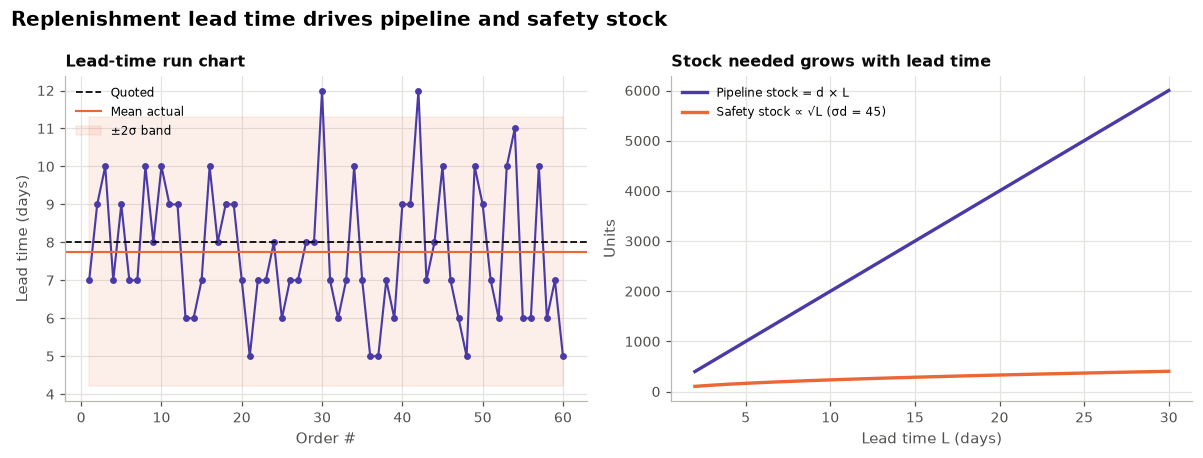

#### Demand pattern and the product life cycle

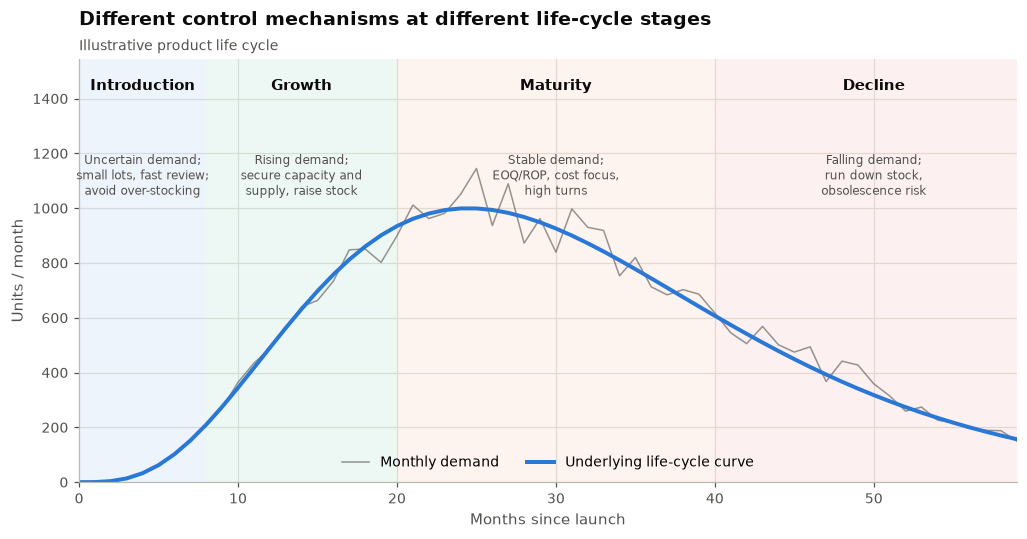

*Demand statistics by life-cycle stage.*

,stage,months,avg_demand,demand_cv,growth_per_month_pct,control_emphasis
0,Introduction,0–8,46,1.14,+45.8,"Uncertain demand; small lots, fast review; avo..."
1,Growth,8–20,572,0.37,+10.6,"Rising demand; secure capacity and supply, rai..."
2,Maturity,20–40,898,0.15,-2.0,"Stable demand; EOQ/ROP, cost focus, high turns"
3,Decline,40–60,366,0.39,-6.7,"Falling demand; run down stock, obsolescence risk"


*Independent vs dependent demand items.*

,demand_type,examples,how_determined,typical_models
0,Independent,"Finished goods, spare parts, service kits",Forecast from market,"EOQ / ROP, periodic review, newsvendor"
1,Dependent,"Components, sub-assemblies, raw materials",Calculated from end-item plan × BOM (MRP),"MRP, lot-for-lot, JIT/kanban"


📄 **PDF report exported:** `reports\P7_other_factors.pdf`

In [34]:
def run_other_factors(lt=None, d_daily=200.0, horizon_months=60, seed=RNG_SEED):
    lt = pd.read_csv(DATA / "lead_time_history.csv") if lt is None else lt.copy()
    sec = Section("P7_other_factors", "Other factors: lead time and demand pattern over the life cycle",
                  part="Part 7 · Other factors")
    L = lt.actual_lead_time_days
    on_time = (L <= lt.quoted_lead_time_days).mean()
    sec.heading("Replenishment lead time")
    sec.metrics({"Quoted lead time": f"{lt.quoted_lead_time_days.iloc[0]} days", "Mean actual": f"{L.mean():.2f} days",
                 "Std. deviation": f"{L.std():.2f} days", "On-time (≤ quoted)": f"{on_time:.0%}",
                 "Pipeline stock at mean LT": f"{d_daily*L.mean():,.0f} units (d = {d_daily:.0f}/day)",
                 "95th-percentile lead time": f"{np.percentile(L, 95):.0f} days"})
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
    axs[0].plot(lt.order_id, L, color=C["violet"], lw=1.4, marker="o", ms=3.5)
    axs[0].axhline(lt.quoted_lead_time_days.iloc[0], color=INK, ls="--", lw=1.2, label="Quoted")
    axs[0].axhline(L.mean(), color=C["orange"], lw=1.4, label="Mean actual")
    axs[0].fill_between(lt.order_id, L.mean() - 2 * L.std(), L.mean() + 2 * L.std(), color=C["orange"], alpha=0.1,
                        label="±2σ band")
    axs[0].set_xlabel("Order #"); axs[0].set_ylabel("Lead time (days)"); axs[0].legend(fontsize=8, loc="upper left")
    axs[0].set_title("Lead-time run chart", fontsize=10.5)
    Lg = np.arange(2, 31)
    axs[1].plot(Lg, d_daily * Lg, color=C["violet"], lw=2.2, label="Pipeline stock = d × L")
    axs[1].plot(Lg, 1.645 * np.sqrt(Lg) * 45, color=C["orange"], lw=2.2, label="Safety stock ∝ √L (σd = 45)")
    axs[1].set_xlabel("Lead time L (days)"); axs[1].set_ylabel("Units"); axs[1].legend(fontsize=8, loc="upper left")
    axs[1].set_title("Stock needed grows with lead time", fontsize=10.5)
    fig.suptitle("Replenishment lead time drives pipeline and safety stock", x=0.01, ha="left", fontsize=13,
                 fontweight="bold")
    fig.tight_layout()
    sec.figure(fig, "Observed lead times and how pipeline/safety stock scale with the lead time.")

    sec.heading("Demand pattern and the product life cycle")
    rng = np.random.default_rng(seed)
    t = np.arange(horizon_months)
    life = 1000 * stats.gamma.pdf(t, a=4.5, scale=7) / stats.gamma.pdf(3.5 * 7, a=4.5, scale=7)
    demand = np.maximum(0, life * (1 + rng.normal(0, 0.08, len(t))))
    stages = [(0, 8, "Introduction", C["blue"], "Uncertain demand;\nsmall lots, fast review;\navoid over-stocking"),
              (8, 20, "Growth", C["aqua"], "Rising demand;\nsecure capacity and\nsupply, raise stock"),
              (20, 40, "Maturity", C["orange"], "Stable demand;\nEOQ/ROP, cost focus,\nhigh turns"),
              (40, horizon_months, "Decline", C["red"], "Falling demand;\nrun down stock,\nobsolescence risk")]
    fig, ax = plt.subplots(figsize=(11, 5))
    for a, b, name, colr, txt in stages:
        ax.axvspan(a, b, color=colr, alpha=0.08, lw=0)
        ax.text((a + b) / 2, 1.25 * demand.max(), name, ha="center", fontsize=10, fontweight="bold", color=INK)
        ax.text((a + b) / 2, 1.05 * demand.max(), txt, ha="center", va="top", fontsize=8, color=INK2)
    ax.plot(t, demand, color=INK2, lw=1, alpha=0.6, label="Monthly demand")
    ax.plot(t, life, color=C["blue"], lw=2.6, label="Underlying life-cycle curve")
    ax.set_ylim(0, 1.35 * demand.max()); ax.set_xlim(0, horizon_months - 1)
    ax.set_xlabel("Months since launch"); ax.set_ylabel("Units / month"); ax.legend(loc="lower center", ncol=2)
    style_title(ax, "Different control mechanisms at different life-cycle stages", "Illustrative product life cycle")
    sec.figure(fig, "Product life-cycle demand with recommended inventory control emphasis per stage.")
    tab = pd.DataFrame([{"stage": s[2], "months": f"{s[0]}–{s[1]}", "avg_demand": demand[s[0]:s[1]].mean(),
                         "demand_cv": demand[s[0]:s[1]].std() / demand[s[0]:s[1]].mean(),
                         "growth_per_month_pct": 100 * np.polyfit(np.arange(s[1] - s[0]), demand[s[0]:s[1]], 1)[0]
                                                 / demand[s[0]:s[1]].mean(),
                         "control_emphasis": s[4].replace("\n", " ")} for s in stages])
    sec.table(tab, "Demand statistics by life-cycle stage.",
              formats={"avg_demand": ",.0f", "demand_cv": ".2f", "growth_per_month_pct": "+.1f"})
    sec.table(pd.DataFrame({"demand_type": ["Independent", "Dependent"],
                            "examples": ["Finished goods, spare parts, service kits",
                                         "Components, sub-assemblies, raw materials"],
                            "how_determined": ["Forecast from market", "Calculated from end-item plan × BOM (MRP)"],
                            "typical_models": ["EOQ / ROP, periodic review, newsvendor", "MRP, lot-for-lot, JIT/kanban"]}),
              "Independent vs dependent demand items.")
    return sec, tab

sec_other, other_tab = run_other_factors()
export_section(sec_other);

---
# Part 8 — Export the complete solution report

The cell below gathers **every section** solved above into one master PDF (`reports/Lecture01_Complete_Solution_Report.pdf`) with a cover page and table of contents. Individual topic reports were already exported after each section. Re-run the notebook after editing the input files to regenerate everything.

In [35]:
ORDER = ["P1_1_us_logistics_costs", "P1_2_inventory_to_sales", "P1_3_business_cycle",
         "P2_1_cycle_stock", "P2_2_safety_stock", "P2_3_total_stock", "P2_4_anticipation_stock", "P2_5_decoupling_stock",
         "P3_1_sku_diversity_bom", "P3_2_product_variety",
         "P4_1_abc_lecture_example", "P4_2_abc_200_skus", "P4_3_abc_multicriteria", "P4_4_abc_control_policy",
         "P5_performance_measures",
         "P6_0_cost_taxonomy", "P6_1_item_costs", "P6_2_carrying_cost", "P6_3_ordering_cost", "P6_4_cost_tradeoff",
         "P6_5_stockout_cost", "P6_6_capacity_costs", "P7_other_factors"]
sections = [Section.REGISTRY[k] for k in ORDER if k in Section.REGISTRY]
master = build_report(sections, "Lecture01_Complete_Solution_Report.pdf",
                      "The Importance of Inventory Management — Complete Solution Report",
                      "Lecture 01 · Concepts, input data, calculations and visual analysis for every topic of the lecture")
n_fig = sum(1 for s in sections for b in s.blocks if b[0] == "img")
n_tab = sum(1 for s in sections for b in s.blocks if b[0] == "table")
display(Markdown(f"✅ **Master report:** `{master.relative_to(BASE)}` — {len(sections)} sections, {n_fig} figures, {n_tab} tables."))
summary = pd.DataFrame({"section": [s.title for s in sections], "part": [s.part for s in sections],
                        "figures": [sum(b[0] == "img" for b in s.blocks) for s in sections],
                        "tables": [sum(b[0] == "table" for b in s.blocks) for s in sections],
                        "pdf": [f"reports/{s.key}.pdf" for s in sections]})
summary

✅ **Master report:** `reports\Lecture01_Complete_Solution_Report.pdf` — 23 sections, 55 figures, 35 tables.

,section,part,figures,tables,pdf
0,U.S. logistics costs and the weight of invento...,Part 1 · Why is it important?,3,1,reports/P1_1_us_logistics_costs.pdf
1,Inventory-to-sales ratios and the downstream s...,Part 1 · Why is it important?,3,1,reports/P1_2_inventory_to_sales.pdf
2,The business cycle and aggregate inventory inv...,Part 1 · Why is it important?,2,1,reports/P1_3_business_cycle.pdf
3,"Cycle stock: batch size, cycle frequency and a...",Part 2 · Categories of stock,3,1,reports/P2_1_cycle_stock.pdf
4,"Safety stock: forecast error, supply error and...",Part 2 · Categories of stock,5,2,reports/P2_2_safety_stock.pdf
5,"Total stock: cycle, safety, process, pipeline ...",Part 2 · Categories of stock,3,3,reports/P2_3_total_stock.pdf
6,Anticipation stock: pre-building for seasonal ...,Part 2 · Categories of stock,2,1,reports/P2_4_anticipation_stock.pdf
7,Decoupling stock between two production stages,Part 2 · Categories of stock,1,1,reports/P2_5_decoupling_stock.pdf
8,"Why it is difficult: SKU diversity, BOMs and d...",Part 3 · Why is it difficult?,4,2,reports/P3_1_sku_diversity_bom.pdf
9,Product variety multiplies the stock needed fo...,Part 3 · Why is it difficult?,1,1,reports/P3_2_product_variety.pdf


### Optional: build a custom report
Pick any subset of sections, e.g. only the ABC analysis and the cost sections, for a handout or assignment solution:

In [36]:
custom = build_report([Section.REGISTRY[k] for k in ["P4_1_abc_lecture_example", "P4_2_abc_200_skus",
                                                     "P6_2_carrying_cost", "P6_4_cost_tradeoff"]],
                      "Custom_ABC_and_Costs_Report.pdf", "ABC Classification and Inventory Costs",
                      "Selected solutions from Lecture 01")
print("Saved:", custom.relative_to(BASE))

Saved: reports\Custom_ABC_and_Costs_Report.pdf
